# 崖歩き課題を例にした強化学習のコード

In [1]:
%matplotlib inline
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import Counter
from copy import deepcopy as cp

In [2]:
state = [[0 for _ in range(12)] for _ in range(8)]

In [3]:
state

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

## 強化学習の課題に必要なもの

In [4]:
# 崖歩き課題環境を作成
class Env(object):
  """Glid World Environment class

  param
  -----
  post_coordinates(tuple(int, int)):
    Agent 初期位置
  pos_goal(tuple(int, int)):
    ゴール位置

  attr
  -----
  _size(dict):
    glid サイズ
  _state(list(list(int))):
    二次元list、状態を管理
  _coordinates(tuple(int, int)):
    Environment上のAgentの位置 （座標）
  _s(tuple(int, int)):
    現在の状態 (Agentの位置)
  _goal(tuple(int, int)):
    ゴールの位置
  """
  def __init__(self, post_coordinates=(0, 7), pos_goal=(11, 7)):
    self._size = {'width': 12, 'height': 8}
    self._state = [[0 for _ in range(self._size['height'])] for _ in range(self._size['width'])]

    self._coordinates = post_coordinates
    self._s = post_coordinates
    self._goal = pos_goal

  def init_episode(self):
    """Envの episode ごとのリセット関数"""
    coordinate_x, coordinate_y = self._s
    gl_x, gl_y = self._goal
    self._coordinates = self._s
    self._state[coordinate_x][coordinate_y] = 1
    self._state[gl_x][gl_y] = 9

    for i in range(1, 11):
      self._state[i][7] = 5

  @property
  def width(self):
    return self._size['width']

  @property
  def height(self):
    return self._size['height']

  def _limit_pos(self, pos, direct):
    """Agentの移動範囲制御"""
    if pos < 0:
        return 0
    if pos > self._size[direct] - 1:
        return self._size[direct] - 1

    return pos
  def get_state(self):
    """現在状態の取得"""
    return self._coordinates

  def update(self, action):
    """Environmentの更新
    学習Agent が選択した行動を反映し、報酬と次状態を返す
    """
    dif_x, dif_y = action
    coordinate_x, coordinate_y = self._coordinates

    r = 0
    term = False
    self._state[coordinate_x][coordinate_y] = 0

    coordinate_x = self._limit_pos(coordinate_x + dif_x, 'width')
    coordinate_y = self._limit_pos(coordinate_y + dif_y, 'height')

    s_post = (coordinate_x, coordinate_y)

    #ゴールに到達した時にの報酬
    if self._state[coordinate_x][coordinate_y] == 9:
      r = 1
      term = True
    elif self._state[coordinate_x][coordinate_y] == 5:
      r = -10000
      coordinate_x, coordinate_y = self._s
    else:
      r = -1

    self._coordinates = (coordinate_x, coordinate_y)
    self._state[coordinate_x][coordinate_y] = 1

    return r, s_post, term

  def print_anim(self):
    """画像の生成用"""
    plt.xlim(0, self.width)
    plt.ylim(self.height, 0)
    rows = np.arange(self.width+ 1)
    cols = np.arange(self.height + 1)
    X, Y = np.meshgrid(rows, cols)
    C = list(map(list, zip(*self._state)))
    im = plt.pcolor(X, Y, C, cmap=plt.cm.gray_r)
    plt.grid(True, which='both', axis='both', linestyle='-', color='k')
    plt.show()
    return im

In [5]:
# 行動方策一覧

def select_random(Q, state, actions, agent=None):
  return random.choice(actions)

def select_greedy(Q, state, actions, agent=None):
  Qvalues = np.array([Q[state, action] for action in actions])
  idx = np.where(Qvalues == Qvalues.max())
  if len(idx[0]) > 1:
    action_selected = actions[random.choice(idx[0])]
  else:
    action_selected = actions[idx[0][0]]
  return action_selected

def e_greedy(Q, state, actions, agent=None):
  # agentオブジェクトからepsを取得（なければデフォルト値）
  eps = agent._eps if agent is not None else 0.1
  if random.random() < eps:
      return select_random(Q, state, actions)
  else:
      return select_greedy(Q, state, actions)

def softmax(Q, state, actions, agent=None):
  tau = agent._tau if agent is not None else 1.0
  Qvalues = np.array([Q[state, action] for action in actions])
  p_boltzmann = dist_boltzmann(Qvalues, tau)
  return actions[np.random.choice(len(actions), p=p_boltzmann)]

def select_ucb(Q, state, actions, agent):
  """UCB (Upper Confidence Bound) 方策関数"""
  # パラメータ c はエージェントの _eps（または追加した独自の属性）から取得
  c = agent._eps
  total_counts = sum([agent._count_action[state, a] for a in actions])

  if total_counts == 0:
      return random.choice(actions)

  ucb_values = []
  for a in actions:
      count_a = agent._count_action[state, a]
      if count_a == 0:
          # 一度も選ばれていない行動は最優先
          ucb_values.append(float('inf'))
      else:
          # UCB値 = Q値 + 好奇心ボーナス
          bonus = c * math.sqrt(math.log(total_counts) / count_a)
          ucb_values.append(Q[(state, a)] + bonus)

  max_val = max(ucb_values)
  max_indices = [i for i, v in enumerate(ucb_values) if v == max_val]
  return actions[random.choice(max_indices)]

In [6]:
def dist_boltzmann(Q, tau):
  """Boltzmann 分布　= Softmax変換関数"""
  trQ = np.exp(Q - np.max(Q))/tau
  return trQ / trQ.sum(axis=0)

In [7]:
def sim(epi, env, agent):
  """シミュレーションの主要部

  param
  -----
  epi(int):
    エピソード数
  param(tuple):
    Agentの学習パラメータ
  Env(Env):
    環境
  Agent(BaseAgent):
    学習Agent

  """
  env = env
  agent = agent
  episode = epi

  count = Counter() #行動選択の偏り確認用カウンター
  steps = [] # ゴール到達までにかかったstep数保存用

  # 描画アニメ用
  fig = plt.figure()
  ims = []

  state_print = False
  for ep in range(episode):
      turn = 0
      term = False
      env.init_episode()
      agent.init_episode()
      if state_print:
          im = env.print_anim()
          ims.append([im])

      #エピソード主要部、終端状態までループ
      while(not term):
          s = env.get_state() # 環境から状態を観測
          a = agent.select_action(s) # エージェントが行動選択
          if state_print:
              print(f'agent select {a}')
          r, sd, term = env.update(a) # 環境を更新(報酬と次状態と終端か否か)
          agent.update(r, sd, term) # Q 値を更新

          count[a] += 1 # 行動選択の偏り確認用

          if state_print:
              print(f'turn:{turn}')
              im = env.print_anim()
              ims.append([im])

          turn += 1

      steps.append(turn)

      # 最後はeval 用
      if ep == episode - 2:
          state_print = True
          agent._behavior_policy = select_greedy

  agent.print_optimal()
  return steps

In [8]:
class BaseAgent(object):
  """glid world Agent class

  param
  -----
  width(int): default: 7
    glid width
  height(int): default: 7
    glid height
  param(tuple): default: (0.1, 0.9, 0)
    RL learning parameters: alpha, gammma, epsilon
  policy(string): default: Q
    RL Policy: Q epsilon greedy, Q softmax, sarsa epsilon greedy, sarsa softmax
    Q: policy off(behavior != estimation)
    sarsa: policy on(behavior == estimation)
  R(float): default: 0.99
    garbage

  attr
  -----
  _last_action(tuple(int, int)):
    最後に行った行動、学習時に用いる
  _alpha(float):
    学習率
  _gammma(float):
    減衰率
  _eps(float):
    εGreedy時のランダム行動しきい値
  _current_s(tuple(int, int)):
    現在の状態、今回の場合中身はエージェントの位置座標が保存されている(他に変化する情報がないため)
  _action(list(tuple)):
    行動リスト、エージェントの行動として、x座標とy座標に加算する値のTupleが上下左右として入っている
  _Q(dict(float):
    Q値、状態行動対の文字列をキー、それに対応する価値をvalueとし、0で初期化
  _count_action(Counter):
    各行動をどれくらい行ったかをCounterでカウント、使途はない
  _behavior_policy(function):
    挙動方策に何を用いるか、soft方策(各状態を十全に探索できる)である必要がある
  _estimation_policy(function):
    推定方策に何を用いるか
  """
  def __init__(self, width=7, height=7, param=(0.1, 0.9, 0.0), behavior_policy=select_greedy, name='Q_eg'):
    up = (0, -1) # 上に行く行動
    down = (0, 1) # 下に行く行動
    left = (-1, 0) # 左に行く行動
    right = (1, 0) # 右に行く行動

    self._height = height
    self._width = width

    self._last_action = None
    self._update_action = None
    self._alpha = param[0] #学習率
    self._gamma = param[1] #割引率
    self._eps = param[2] # epsilon (探索率初期値)
    self._tau = 1.0 # 温度パラメータ

    self._current_s = None
    self._update_s = None
    self._actions = [up, down, left, right]
    self._Q = {((i, j), action): 0 for i in range(width) for j in range(height) for action in self._actions}
    self._count_action = Counter()
    self._pre_r = None

    # 学習アルゴリズムによって方策を切り替える
    self._behavior_policy = behavior_policy # 実際に実行した行動が格納されている
    self._estimation_policy = select_greedy # 最大のQ値の行動が格納されている
    self.name = name # Add this line to store the name

  @property
  def eps(self):
    return self._eps

  @eps.setter
  def eps(self, eps):
    self._eps = eps

  @property
  def tau(self):
    return self._tau

  @tau.setter
  def tau(self, tau):
    self._tau = tau

  def init_episode(self):
      self._current_s = None
      self._update_s = None
      self._last_action = None
      self._update_action = None
      self._pre_r = None

  def select_action(self, s):
    """挙動方策によって行動を選択し選択行動を返す"""
    self._current_s = s
    a = self._behavior_policy(self._Q, self._current_s, self._actions, self)
    self._count_action[s, a] += 1
    self._last_action = a

    return a

  def _update_param(self):
    """探索パラーメタのアップデート"""
    self._eps = 1.0*self._eps
    self._tau = 1.0*self._tau

  def update(self, r, next_s, term):
    # 継承して実装
    pass


  def print_optimal(self):
    """最適方策(Greedy選択)表示用"""
    action = ['UP', 'DN', 'LT', 'RT']
    for y in range(self._height):
        print('|', end='')
        for x in range(self._width):
            print(f'{select_greedy(self._Q, (x, y), self._actions)}	', end='')
            print('|', end='')
        print()

## Q 学習エージェント + Epsilon-Greedy

In [9]:
class OffPolicyAgent(BaseAgent):
  """ Off-policy Agetn = Q-learning Agent """

  def _update_param(self):
    """探索パラーメタのアップデート"""
    self._eps = 1.0*self._eps
    self._tau = 1.0*self._tau

  def update(self, r, next_s, term):
    """Q値更新関数
    r(float):
      報酬
    sd(tuple(int, int)):
      次状態
    term(bool):
      終端状態判別フラグ

    """
    buckup_action = self._estimation_policy(self._Q, self._current_s, self._actions, self._eps)

    if self._update_s is not None:
        target = self._pre_r + self._gamma * self._Q[(self._current_s, buckup_action)] - self._Q[(self._update_s, self._update_action)]
        self._Q[(self._update_s, self._update_action)] += self._alpha * target

    if term:
        self._Q[(self._current_s, self._last_action)] += self._alpha * r
        self._update_param()
    else:
        self._update_s = cp(self._current_s)
        self._update_action = cp(self._last_action)
        self._current_s = next_s
        self._pre_r = cp(r)

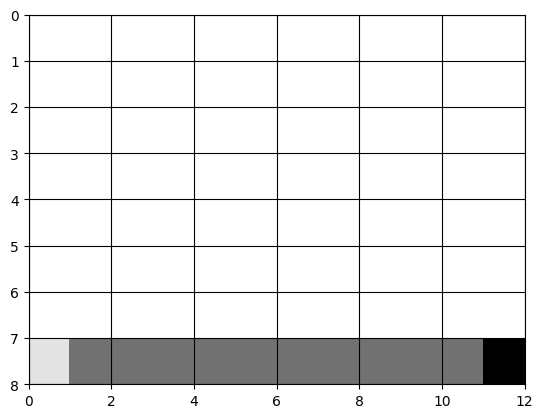

agent select (0, -1)
turn:0


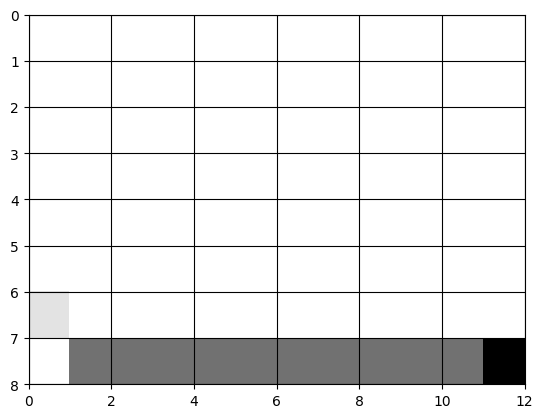

agent select (1, 0)
turn:1


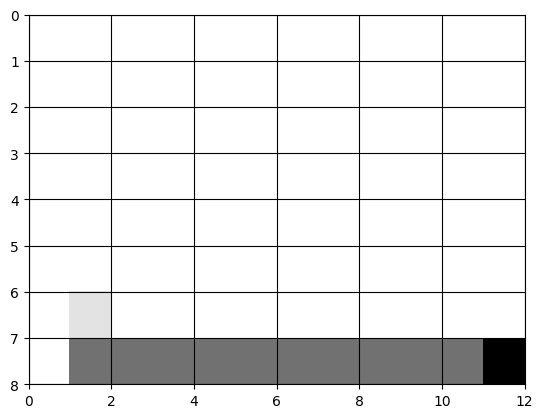

agent select (1, 0)
turn:2


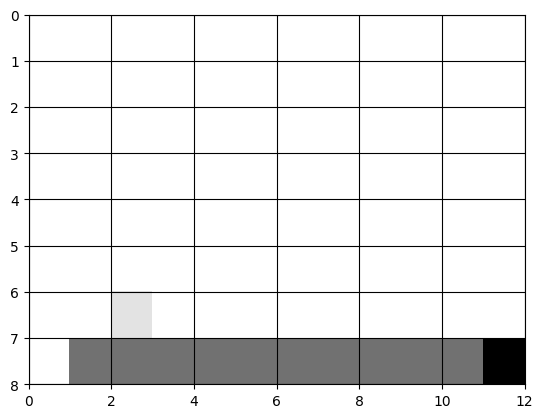

agent select (1, 0)
turn:3


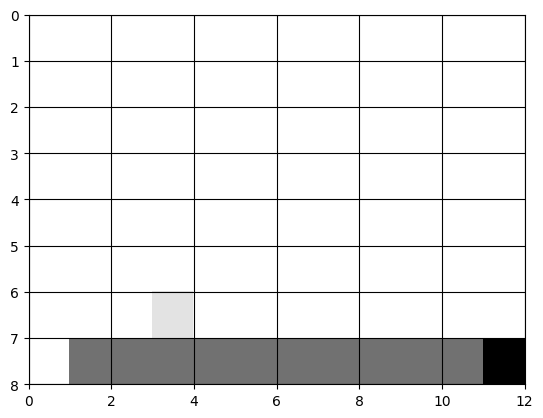

agent select (1, 0)
turn:4


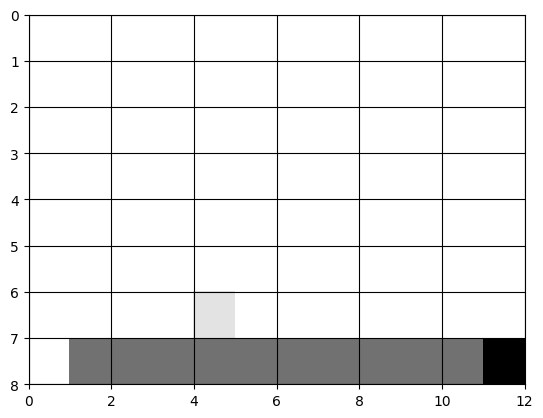

agent select (1, 0)
turn:5


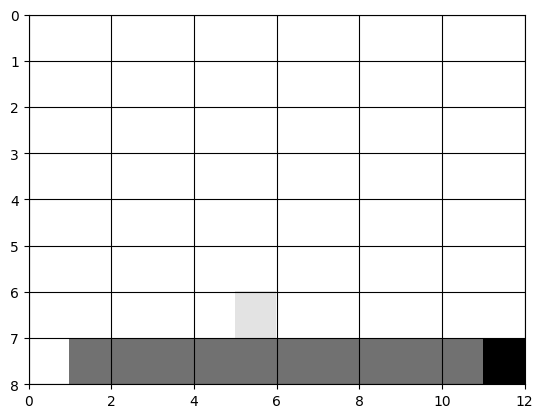

agent select (1, 0)
turn:6


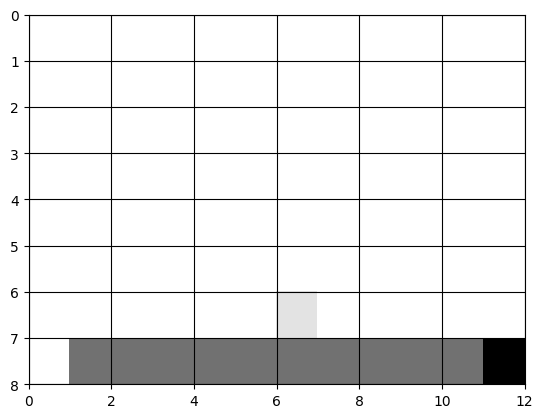

agent select (1, 0)
turn:7


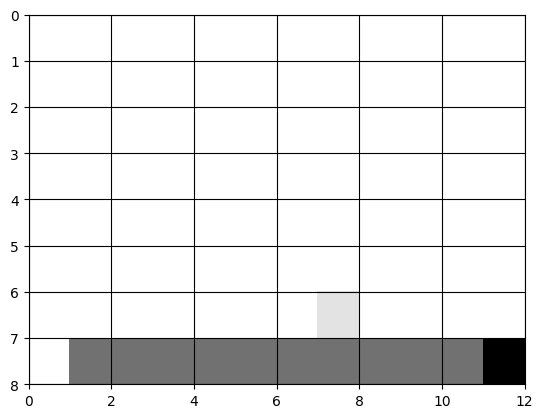

agent select (1, 0)
turn:8


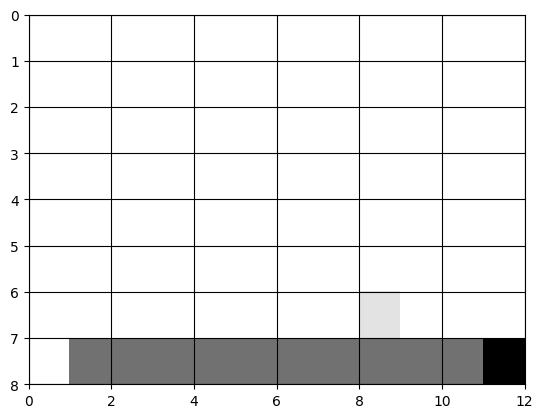

agent select (1, 0)
turn:9


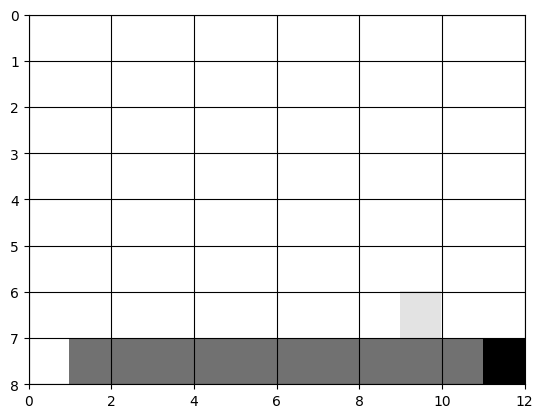

agent select (1, 0)
turn:10


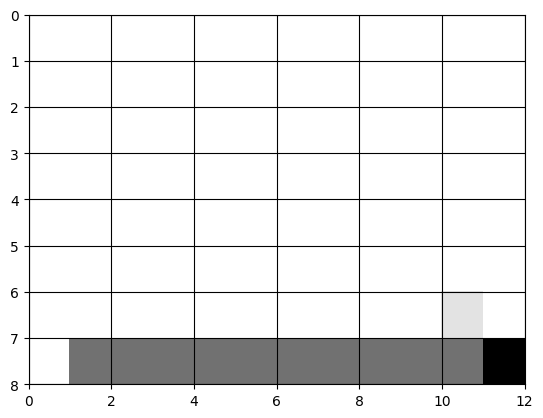

agent select (1, 0)
turn:11


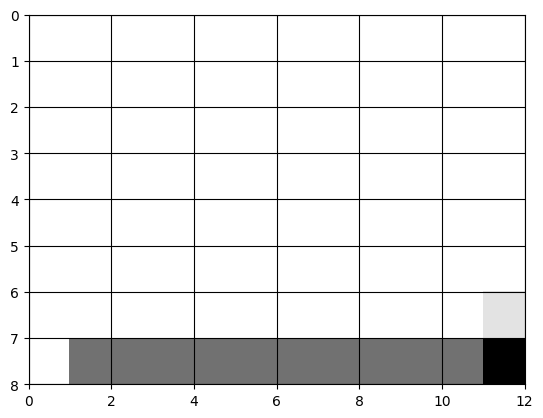

agent select (0, 1)
turn:12


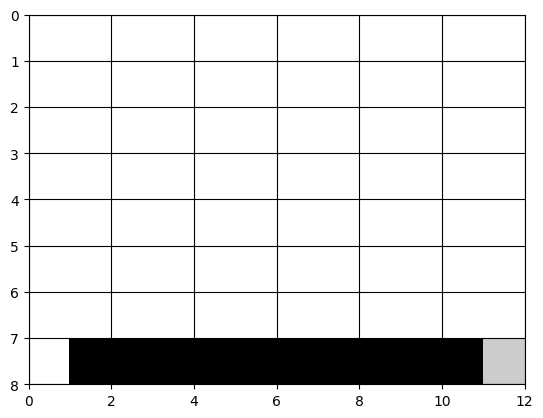

|(0, 1)	|(0, -1)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|
|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(-1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|
|(0, -1)	|(-1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(-1, 0)	|(0, -1)	|(0, 1)	|(0, -1)	|(1, 0)	|(0, -1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|
|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(-1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(-1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, 1)	|


In [10]:
# main
episode = 200
env = Env()
agent = OffPolicyAgent(env.width, env.height, param=(0.1, 0.9, 0.1), behavior_policy=e_greedy, name='Q+e-greedy')

steps_Q_e_greedy = sim(epi=episode, env=env, agent=agent)

## Q 学習エーエジェント + Softmax

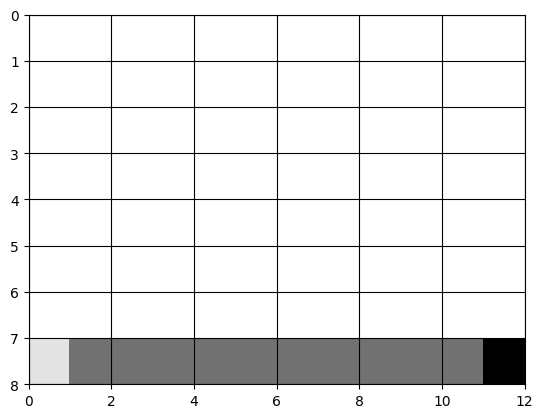

agent select (0, -1)
turn:0


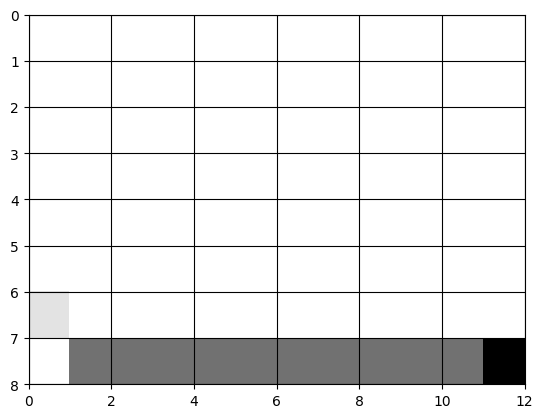

agent select (1, 0)
turn:1


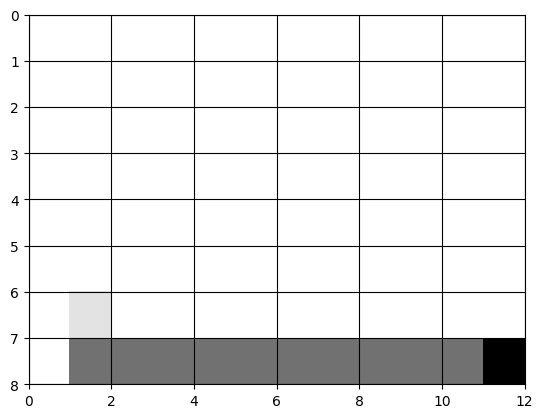

agent select (1, 0)
turn:2


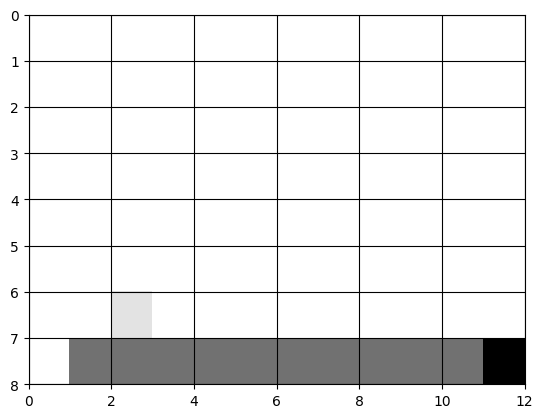

agent select (1, 0)
turn:3


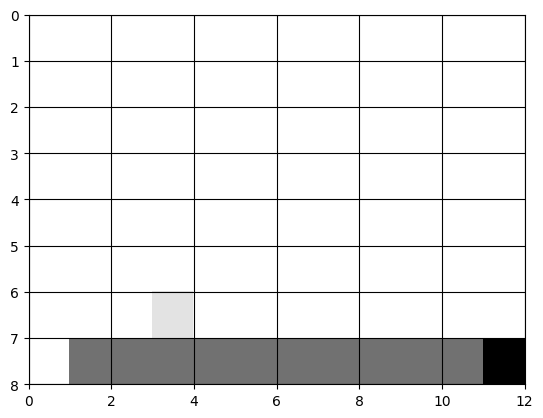

agent select (1, 0)
turn:4


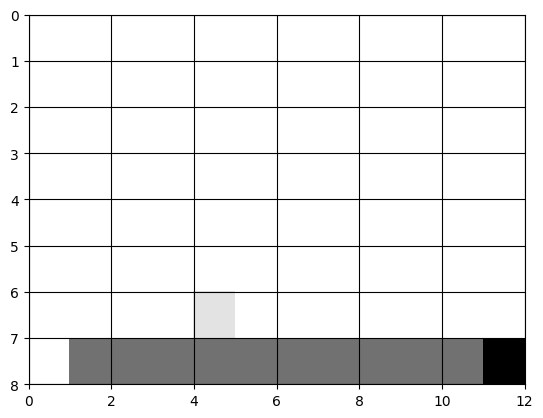

agent select (1, 0)
turn:5


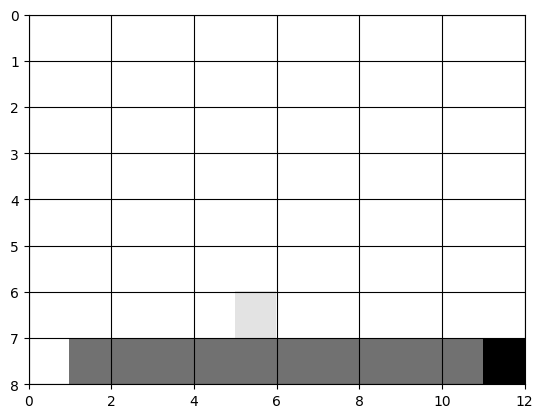

agent select (1, 0)
turn:6


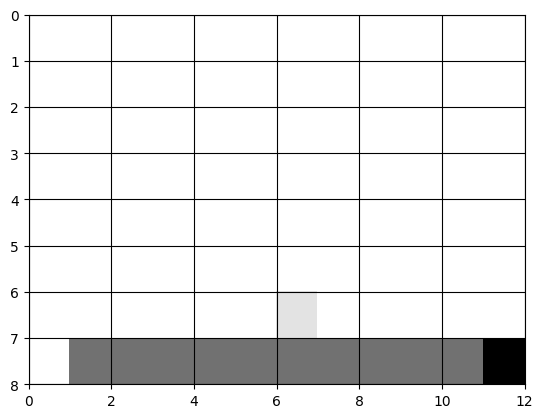

agent select (1, 0)
turn:7


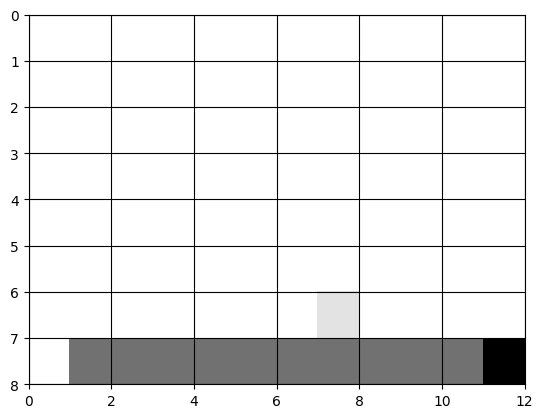

agent select (1, 0)
turn:8


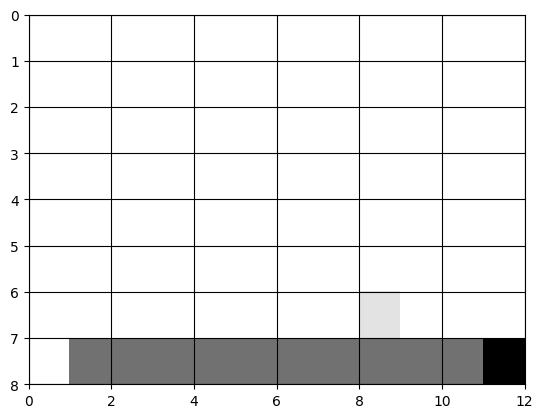

agent select (1, 0)
turn:9


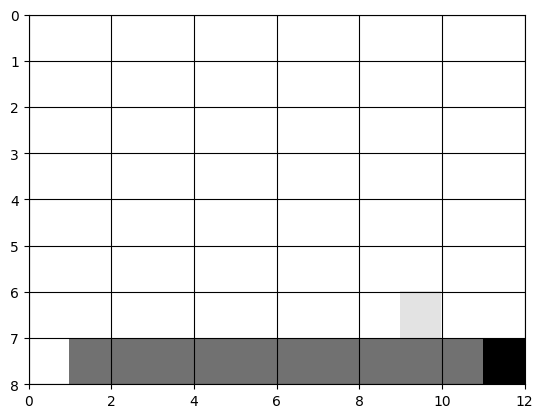

agent select (1, 0)
turn:10


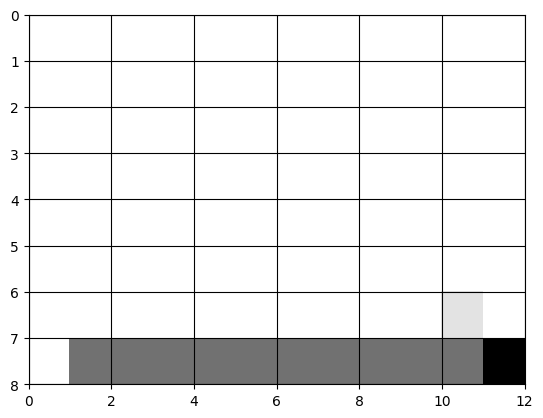

agent select (1, 0)
turn:11


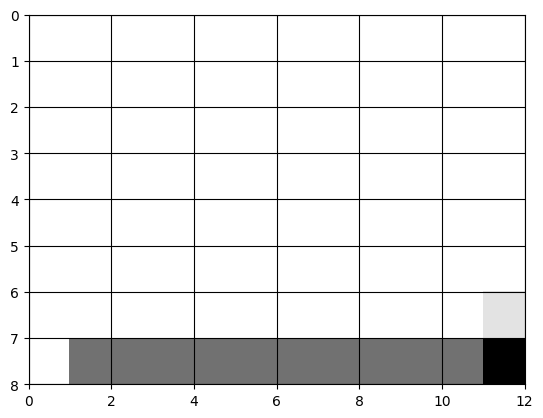

agent select (0, 1)
turn:12


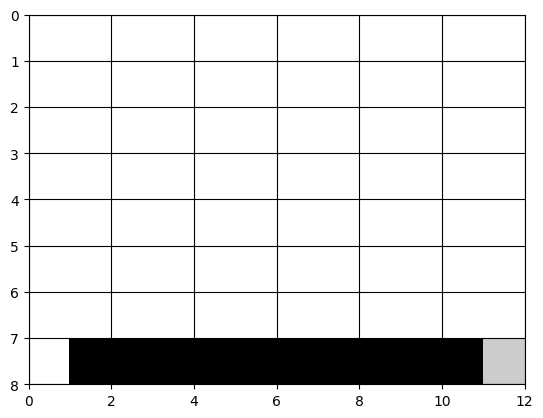

|(0, -1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(0, -1)	|(-1, 0)	|(-1, 0)	|(0, 1)	|(0, -1)	|(0, -1)	|(-1, 0)	|


In [11]:
# main
env = Env()
agent = OffPolicyAgent(env.width, env.height, param=(0.1, 0.9, 0.1), behavior_policy=softmax, name='Q+softmax')

steps_Q_softmax = sim(epi=episode, env=env, agent=agent)

## CuriosityAgent

In [12]:
class CuriosityAgent(OffPolicyAgent):
    """
    訪問回数に基づく内発的報酬（好奇心）を持つQ学習エージェント
    """
    def __init__(self, width=12, height=8, param=(0.1, 0.9, 0.1), behavior_policy=e_greedy, name='Curiosity', beta=0.5):
        super().__init__(width, height, param, behavior_policy, name)
        self._beta = beta # 好奇心の強さを決めるスケール係数

    def update(self, r, next_s, term):
        """好奇心による報酬の底上げを行った上でQ値を更新する[cite: 1]"""
        # 現在の状態・行動の訪問回数を取得[cite: 1]
        count = self._count_action[self._current_s, self._last_action]

        # 好奇心ボーナス（内発的報酬）の計算：訪問回数が少ないほど大きい
        intrinsic_reward = self._beta / math.sqrt(count)

        # 実際の報酬に好奇心ボーナスを加算
        total_r = r + intrinsic_reward

        super().update(total_r, next_s, term)

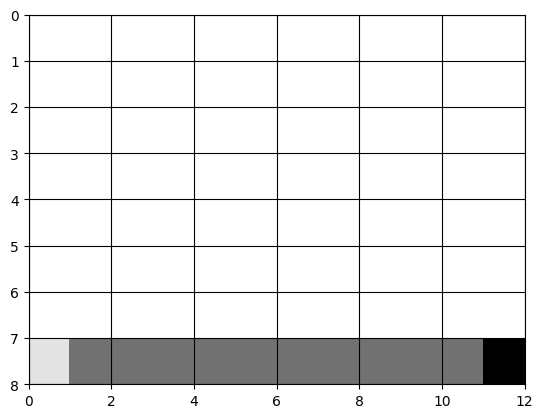

agent select (0, -1)
turn:0


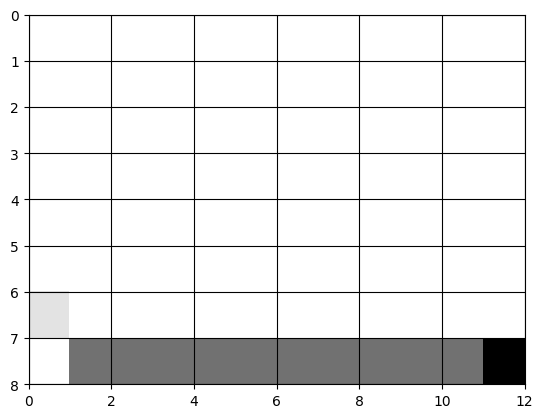

agent select (1, 0)
turn:1


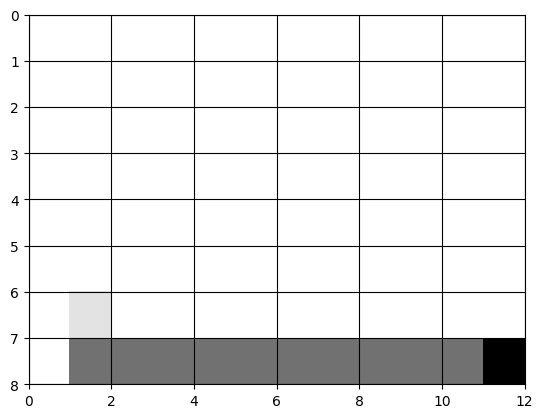

agent select (1, 0)
turn:2


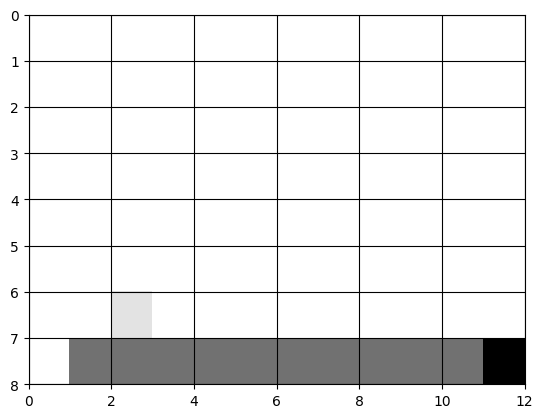

agent select (1, 0)
turn:3


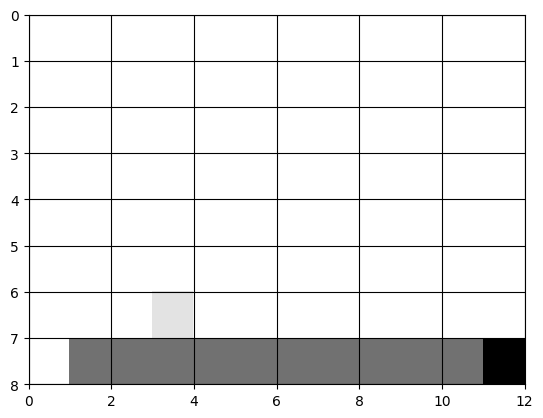

agent select (1, 0)
turn:4


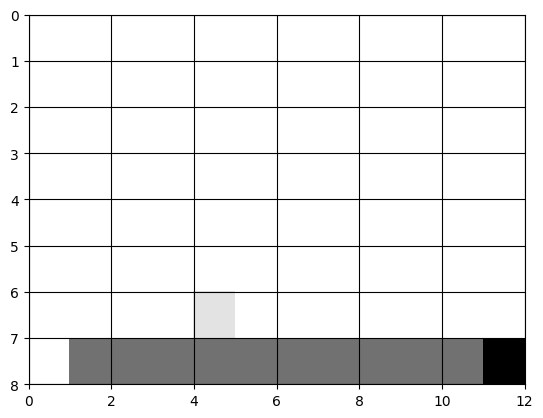

agent select (1, 0)
turn:5


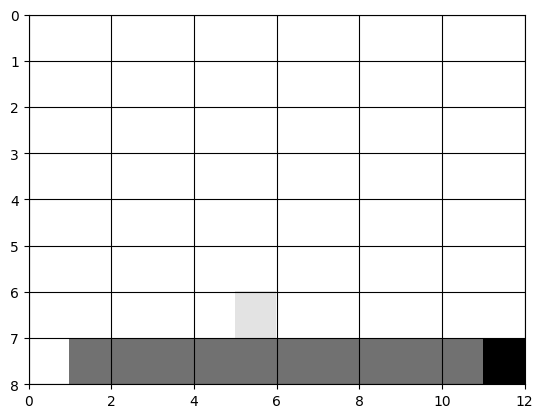

agent select (1, 0)
turn:6


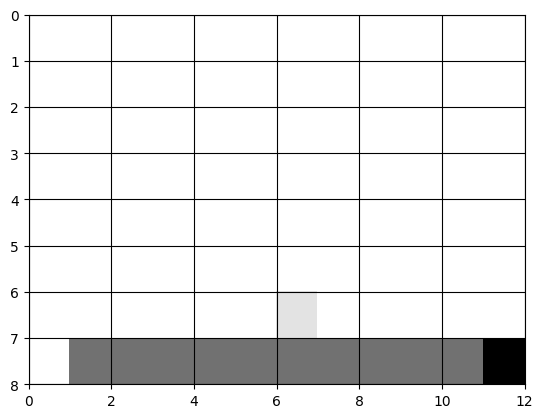

agent select (1, 0)
turn:7


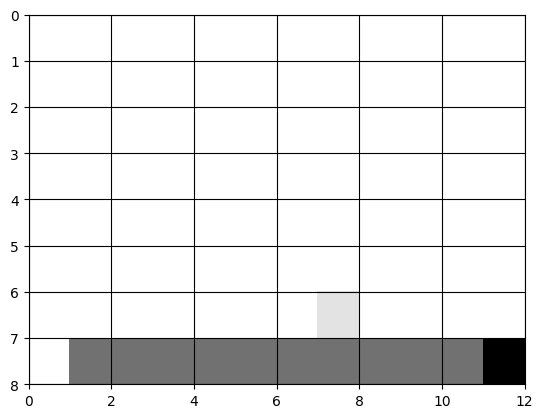

agent select (1, 0)
turn:8


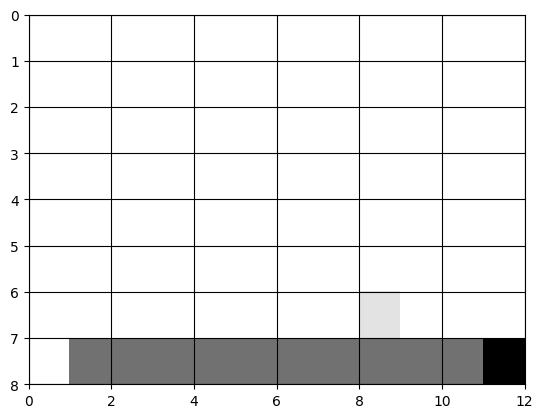

agent select (1, 0)
turn:9


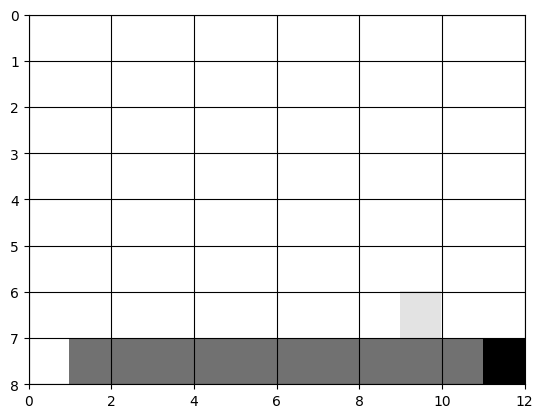

agent select (1, 0)
turn:10


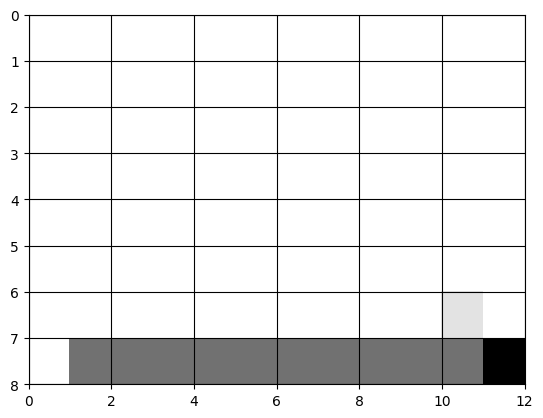

agent select (1, 0)
turn:11


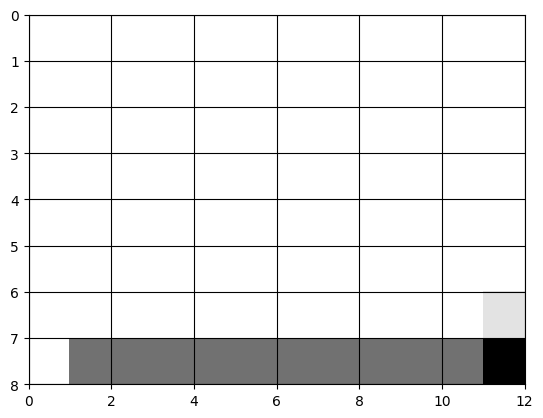

agent select (0, 1)
turn:12


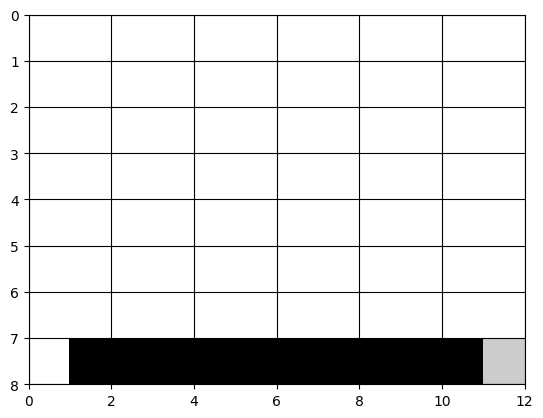

|(1, 0)	|(1, 0)	|(1, 0)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(-1, 0)	|(1, 0)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(0, 1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|(1, 0)	|
|(0, 1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, 1)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, 1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(-1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, -1)	|(-1, 0)	|(0, 1)	|(0, -1)	|(-1, 0)	|(0, -1)	|(0, 1)	|(-1, 0)	|(-1, 0)	|(-1, 0)	|


In [13]:
env_curiosity = Env()
# beta=0.5 で好奇心ボーナスを与える
agent_curiosity = CuriosityAgent(env_curiosity.width, env_curiosity.height, param=(0.1, 0.9, 0.1), behavior_policy=e_greedy, name='Q+Curiosity', beta=0.5)

steps_curiosity = sim(epi=episode, env=env_curiosity, agent=agent_curiosity)

## UCBAgent

In [14]:
# class UCBAgent(OffPolicyAgent):
#     """
#     UCB (Upper Confidence Bound) 方策を用いるエージェント
#     「行動の期待値(Q値)」と「未探索度(好奇心)」のバランスを取って行動を選択する。
#     """
#     def __init__(self, width=12, height=8, param=(0.1, 0.9, 1.0), behavior_policy=None, name='UCB'):

#         super().__init__(width, height, param, behavior_policy, name)
#         self._c = param[2]

#     def select_action(self, s):
#         """UCB方策による行動選択[cite: 1]"""
#         self._current_s = s

#         # 状態 s における全行動の訪問回数の合計 N(s) を計算[cite: 1]
#         total_counts = sum([self._count_action[s, a] for a in self._actions])

#         if total_counts == 0:
#             # まだその状態を一度も訪れていない場合はランダムに選択[cite: 1]
#             a = random.choice(self._actions)
#         else:
#             ucb_values = []
#             for a in self._actions:
#                 count_a = self._count_action[s, a]
#                 if count_a == 0:
#                     # 一度も選ばれていない行動は好奇心が最大として優先的に選ぶ
#                     ucb_values.append(float('inf'))
#                 else:
#                     # UCB値の計算: Q値 + 好奇心ボーナス[cite: 1]
#                     bonus = self._c * math.sqrt(math.log(total_counts) / count_a)
#                     ucb_values.append(self._Q[(s, a)] + bonus)

#             # UCB値が最大の行動を選択（複数ある場合はランダム）[cite: 1]
#             max_val = max(ucb_values)
#             max_indices = [i for i, v in enumerate(ucb_values) if v == max_val]
#             a = self._actions[random.choice(max_indices)]

#         # 選択した行動のカウントを増やし、記録する[cite: 1]
#         self._count_action[s, a] += 1
#         self._last_action = a
#         return a

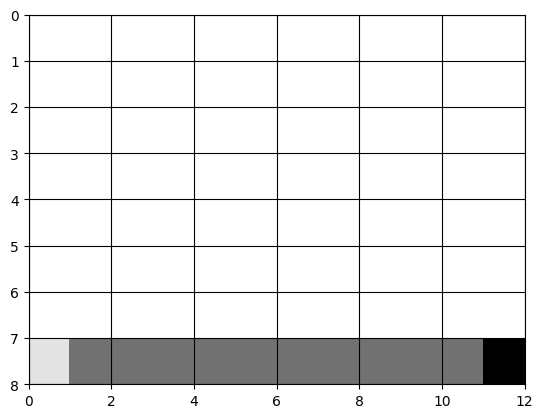

agent select (0, -1)
turn:0


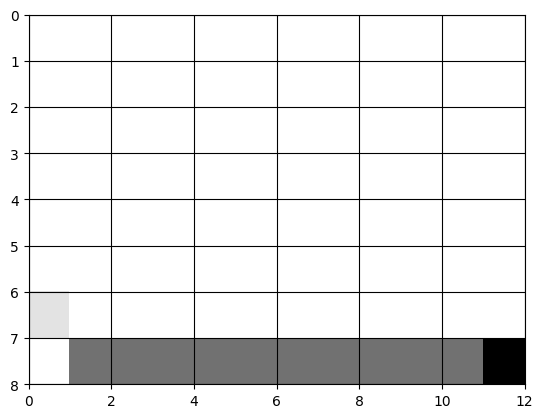

agent select (1, 0)
turn:1


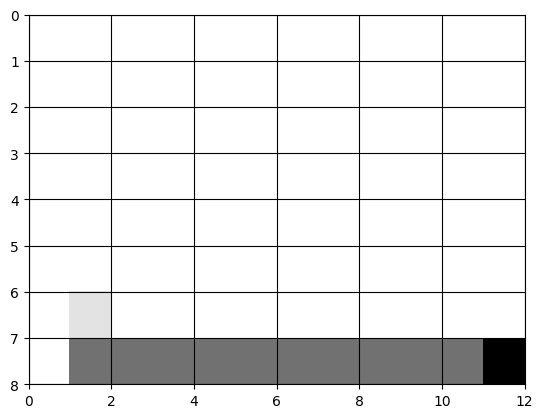

agent select (1, 0)
turn:2


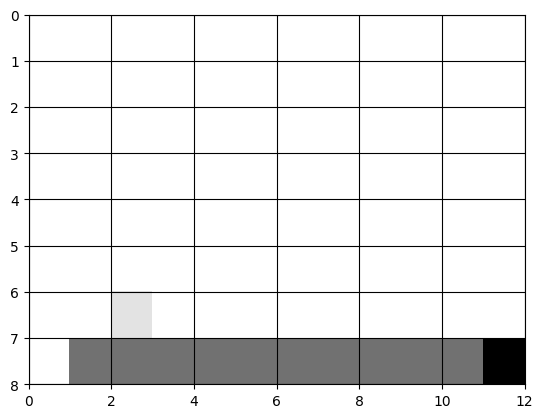

agent select (1, 0)
turn:3


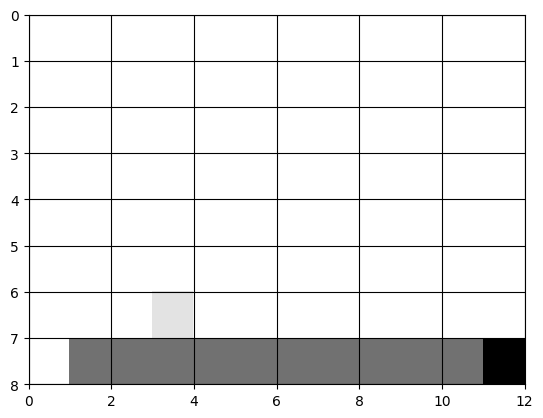

agent select (1, 0)
turn:4


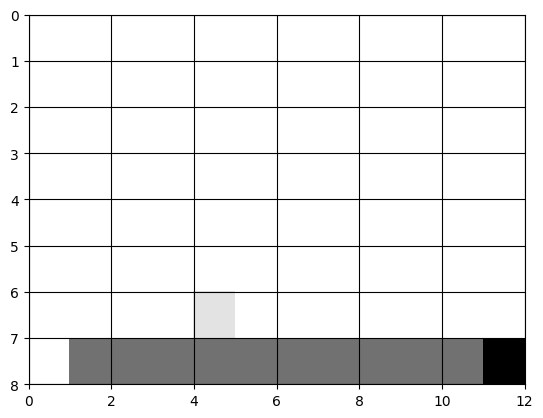

agent select (1, 0)
turn:5


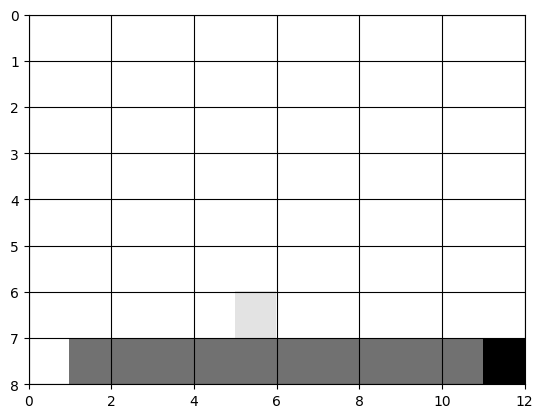

agent select (1, 0)
turn:6


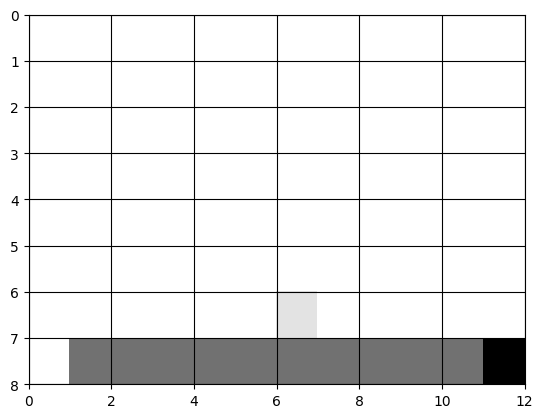

agent select (1, 0)
turn:7


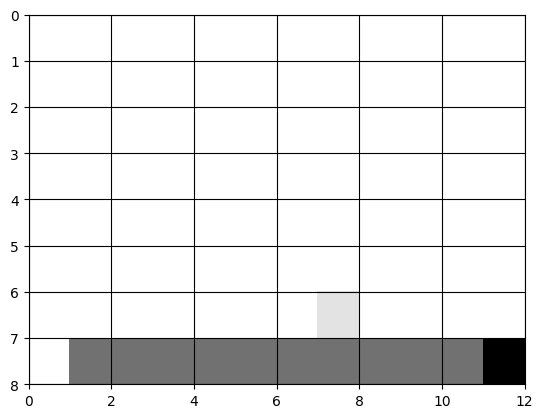

agent select (1, 0)
turn:8


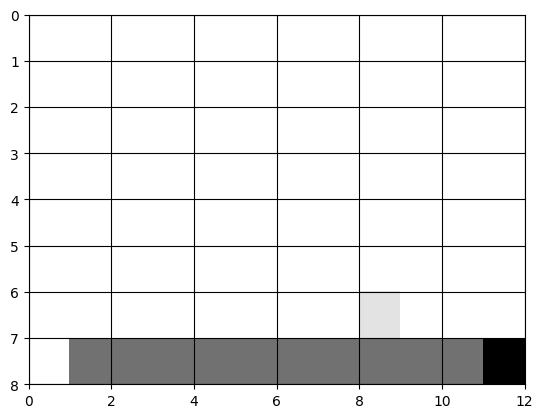

agent select (1, 0)
turn:9


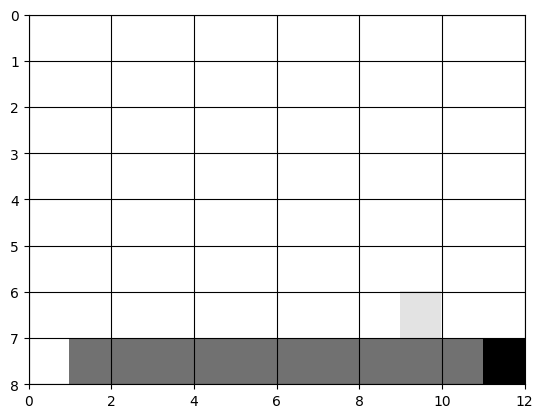

agent select (1, 0)
turn:10


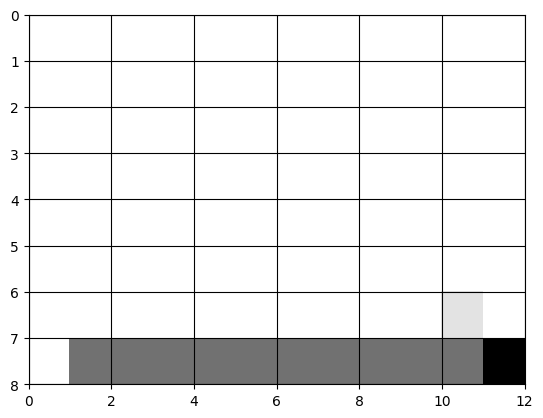

agent select (1, 0)
turn:11


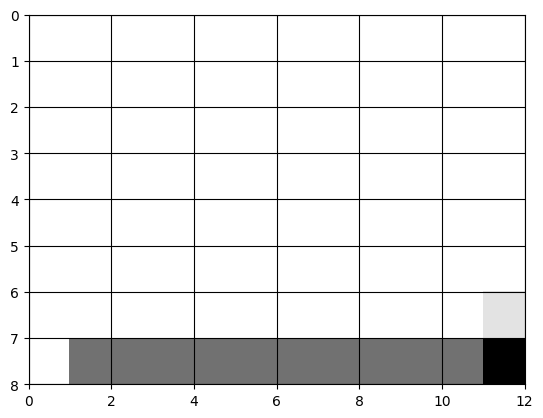

agent select (0, 1)
turn:12


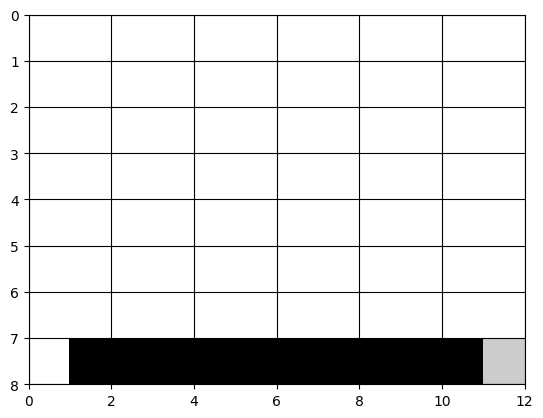

|(0, -1)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|
|(1, 0)	|(0, -1)	|(-1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|


In [15]:
env_ucb = Env()
# c=1.0 (paramの第3引数) としてUCBを計算する
agent_ucb = OffPolicyAgent(env_ucb.width, env_ucb.height, param=(0.1, 0.9, 1.0), behavior_policy=select_ucb, name='Q+UCB')

steps_ucb = sim(epi=episode, env=env_ucb, agent=agent_ucb)

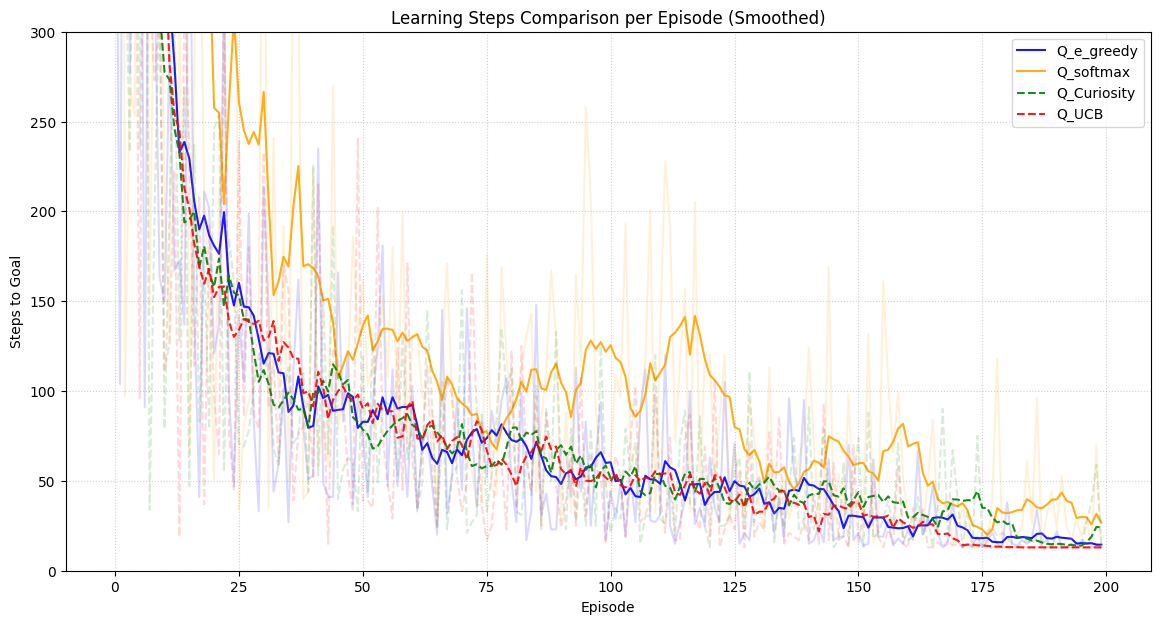

last policy steps
  Q_e_greedy: 	13 steps
  Q_softmax: 		13 steps
  Q_Curiosity: 	13 steps
  Q_UCB: 		13 steps


In [16]:
# データを滑らかにするヘルパー関数
def smooth(data, window=10):
    """
    window: 平均を取るエピソード数
    """
    return pd.Series(data).rolling(window=window, min_periods=1).mean().values

# 滑らかさの度合い
window_size = 8

plt.figure(figsize=(14.0, 7.0))

# 1. Q_e_greedy
plt.plot(np.arange(episode), steps_Q_e_greedy, color='blue', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_Q_e_greedy, window_size), color='blue', label='Q_e_greedy', alpha=0.9)

# 2. Q_softmax
plt.plot(np.arange(episode), steps_Q_softmax, color='orange', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_Q_softmax, window_size), color='orange', label='Q_softmax', alpha=0.9)

# 3. Q_Curiosity
plt.plot(np.arange(episode), steps_curiosity, color='green', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_curiosity, window_size), color='green', label='Q_Curiosity', alpha=0.9, linestyle='--')

# 4. Q_UCB
plt.plot(np.arange(episode), steps_ucb, color='red', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_ucb, window_size), color='red', label='Q_UCB', alpha=0.9, linestyle='--')

# グラフの装飾
plt.title('Learning Steps Comparison per Episode (Smoothed)')
plt.xlabel('Episode')
plt.ylabel('Steps to Goal')

plt.ylim(0, 300)

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 最終エピソードの結果出力
print('last policy steps')
print('  Q_e_greedy: \t{} steps'.format(steps_Q_e_greedy[-1]))
print('  Q_softmax: \t\t{} steps'.format(steps_Q_softmax[-1]))
print('  Q_Curiosity: \t{} steps'.format(steps_curiosity[-1]))
print('  Q_UCB: \t\t{} steps'.format(steps_ucb[-1]))

# マップ改良

In [17]:
class CuriosityEnv(Env):
    """
    好奇心を観察しやすいように、壁と「行き止まりの小部屋」を追加した環境
    """
    def __init__(self, post_coordinates=(0, 7), pos_goal=(11, 7)):
        super().__init__(post_coordinates, pos_goal)

    def init_episode(self):
        # 元の初期化（崖とスタート・ゴールの設定）を呼び出す
        super().init_episode()

        walls = [
            (3, 2), (3, 3), (3, 4), (3, 5),
            (4, 5), (5, 5), (6, 5),
            (7, 2), (7, 3), (7, 4), (7, 5),
            (5, 2)
        ]

        for wx, wy in walls:
            self._state[wx][wy] = 8 # 8を壁として定義

    def update(self, action):
        dif_x, dif_y = action
        coordinate_x, coordinate_y = self._coordinates

        r = 0
        term = False
        self._state[coordinate_x][coordinate_y] = 0

        # 次の座標を計算
        next_x = self._limit_pos(coordinate_x + dif_x, 'width')
        next_y = self._limit_pos(coordinate_y + dif_y, 'height')

        # 壁にぶつかった際の判定
        if self._state[next_x][next_y] == 8:
            # 壁にぶつかったら移動できず、元の位置に留まる
            next_x, next_y = coordinate_x, coordinate_y
            r = -1

        # ゴール判定
        elif self._state[next_x][next_y] == 9:
            r = 1
            term = True
        # 崖判定
        elif self._state[next_x][next_y] == 5:
            r = -100
            next_x, next_y = self._s
        # 通常の道
        else:
            r = -1

        self._coordinates = (next_x, next_y)
        self._state[next_x][next_y] = 1

        return r, (next_x, next_y), term

In [18]:
def plot_policy(agent, env):
    """
    エージェントの最適方策を矢印でグリッド上に描画する
    """
    # グリッドのサイズを取得
    width = env.width
    height = env.height

    # 座標データの作成
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    # 各マスの移動方向（U: 横方向, V: 縦方向）を格納する配列
    U = np.zeros((height, width))
    V = np.zeros((height, width))

    for i in range(width):
        for j in range(height):
            # その状態で最もQ値が高い行動を選択
            best_action = select_greedy(agent._Q, (i, j), agent._actions)
            U[j, i] = best_action[0] # x方向の移動量
            V[j, i] = -best_action[1] # y方向の移動量（グラフ描画上、上下を反転）[cite: 1]

    # 描画設定[cite: 1]
    plt.figure(figsize=(10, 6))

    # 背景として環境の状態を表示（崖や壁の場所を可視化）[cite: 1]
    # Cは状態の2次元リストを転置したもの
    C = list(map(list, zip(*env._state)))
    plt.pcolor(np.arange(width+1), np.arange(height+1), C, cmap=plt.cm.gray_r, alpha=0.3)

    # 矢印を描画 (quiver)[cite: 1]
    # X, Yはマスの中心に矢印が来るように調整 (+0.5)
    plt.quiver(X + 0.5, Y + 0.5, U, V, color='blue', pivot='mid', scale=20)

    plt.xticks(np.arange(width + 1))
    plt.yticks(np.arange(height + 1))
    plt.gca().invert_yaxis() # y軸を反転させて環境の座標系に合わせる[cite: 1]
    plt.grid(True, which='both', linestyle='-', color='k', alpha=0.5)
    plt.title(f"Optimal Policy Map ({agent.name})")
    plt.show()

## Epsilon-Greedy

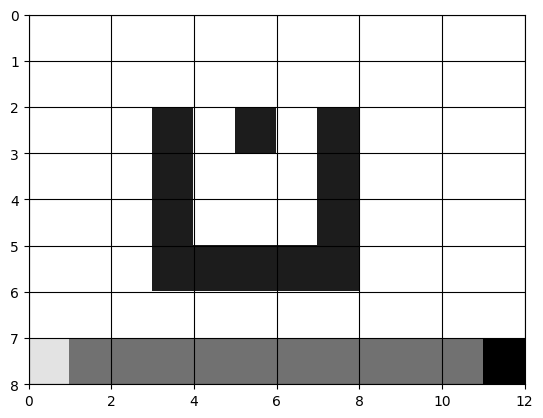

agent select (0, -1)
turn:0


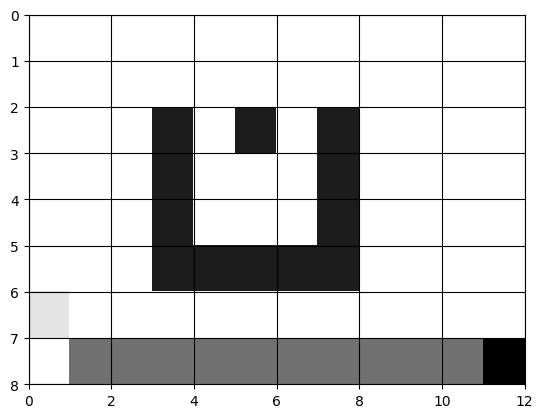

agent select (1, 0)
turn:1


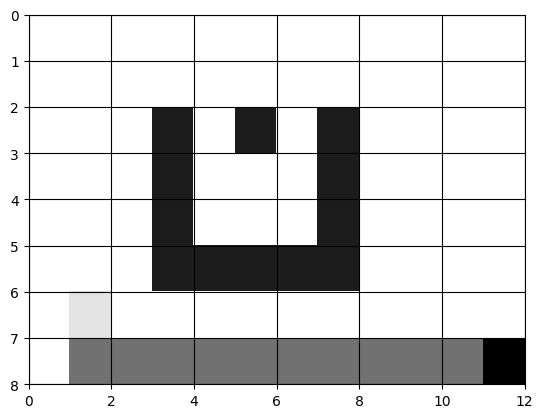

agent select (0, -1)
turn:2


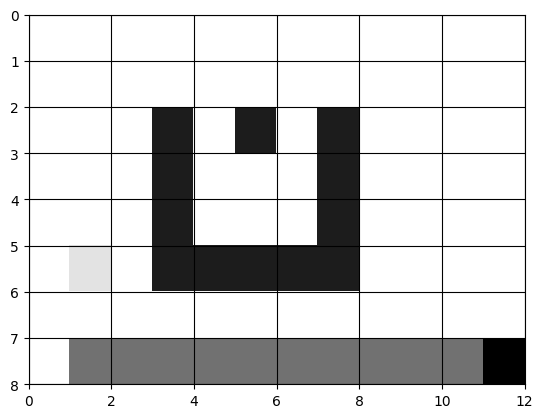

agent select (-1, 0)
turn:3


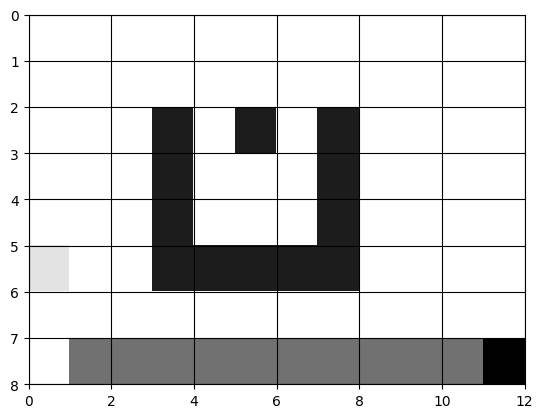

agent select (0, 1)
turn:4


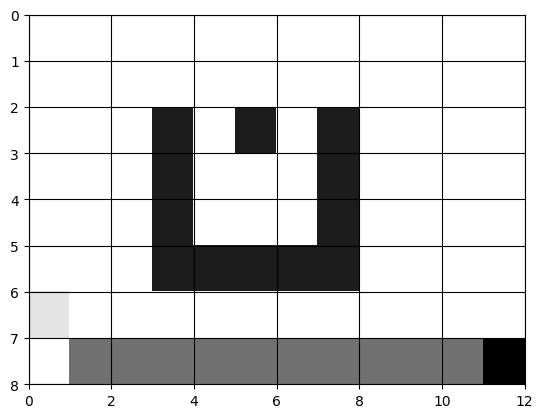

agent select (0, 1)
turn:5


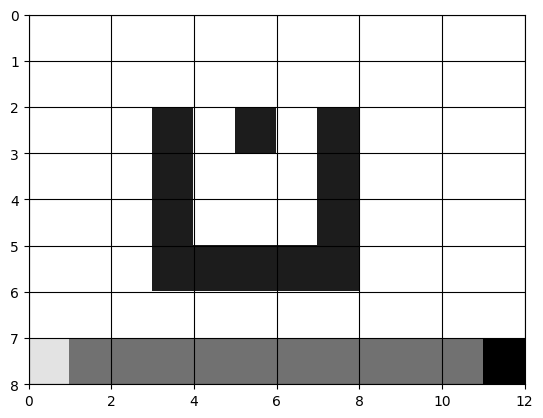

agent select (0, -1)
turn:6


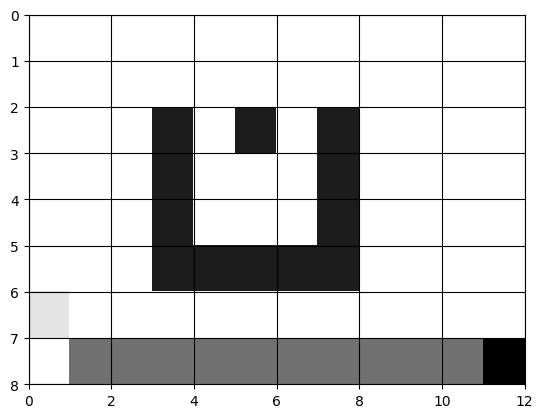

agent select (1, 0)
turn:7


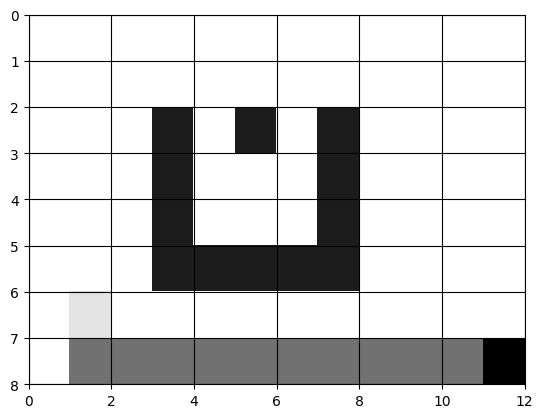

agent select (1, 0)
turn:8


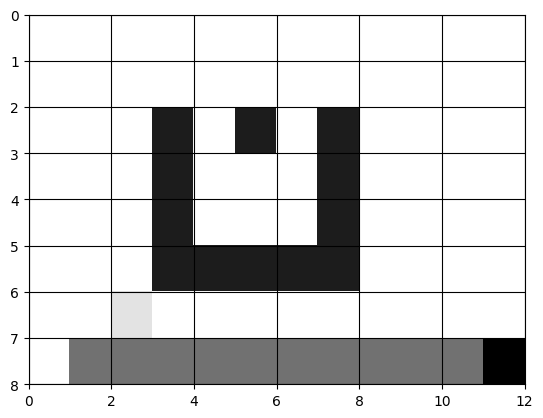

agent select (1, 0)
turn:9


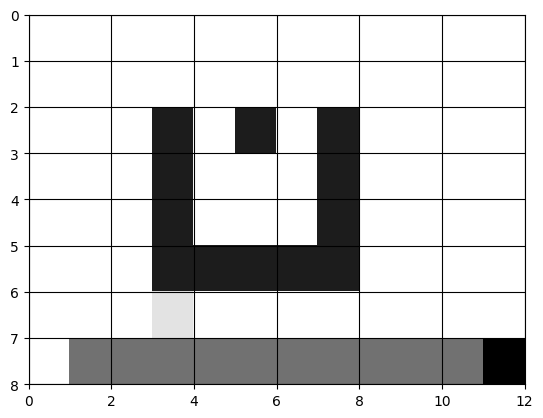

agent select (1, 0)
turn:10


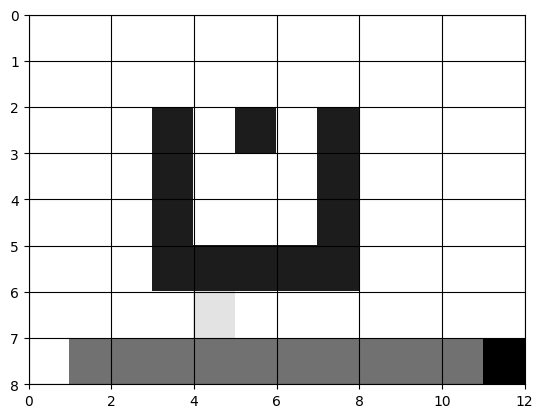

agent select (1, 0)
turn:11


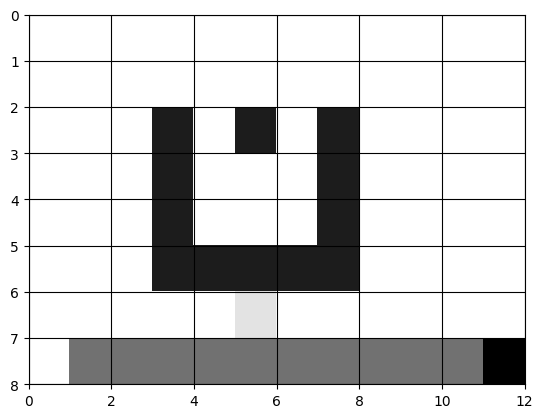

agent select (1, 0)
turn:12


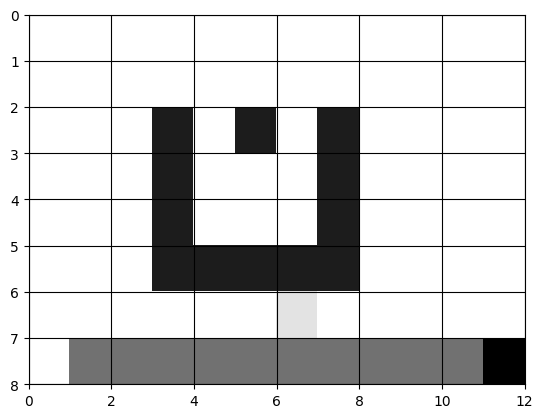

agent select (1, 0)
turn:13


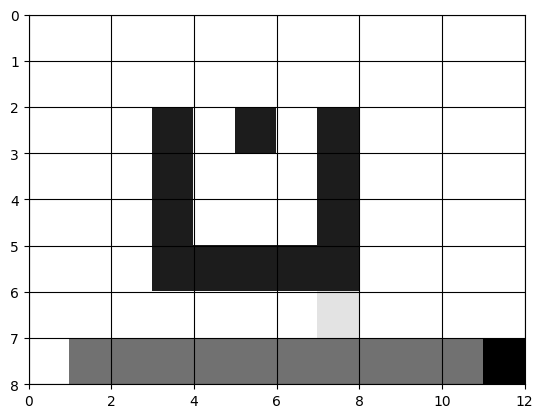

agent select (1, 0)
turn:14


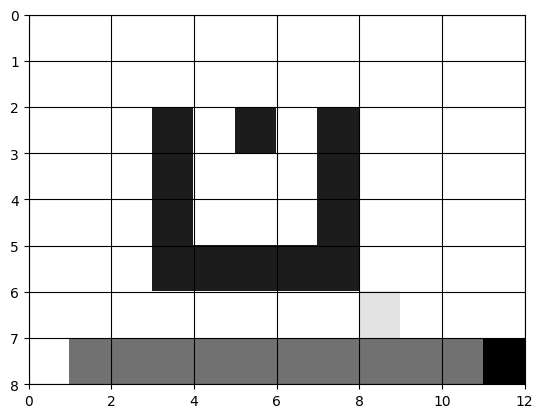

agent select (1, 0)
turn:15


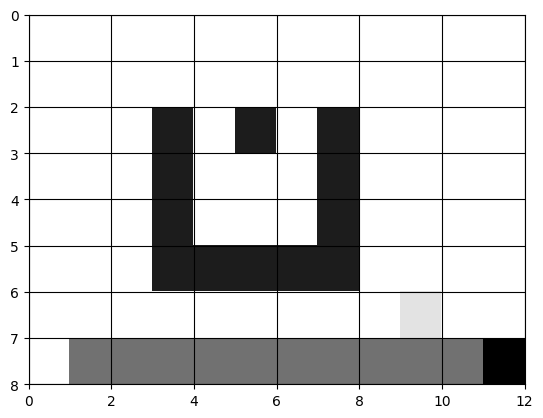

agent select (1, 0)
turn:16


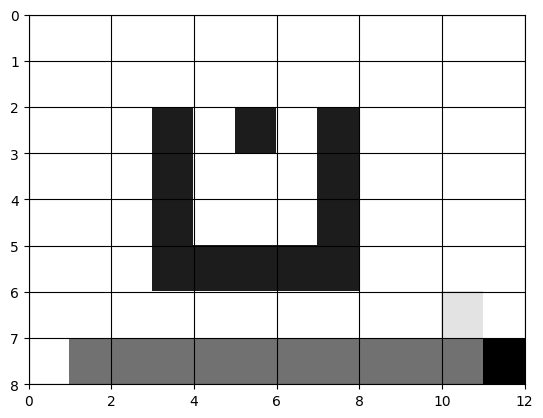

agent select (1, 0)
turn:17


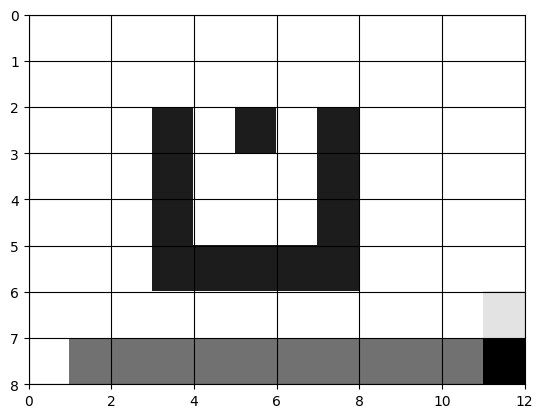

agent select (0, 1)
turn:18


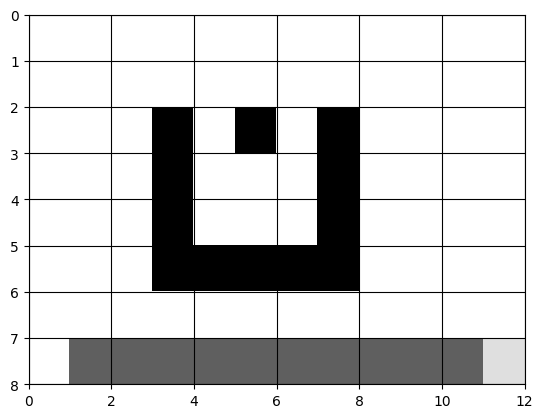

|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(-1, 0)	|(0, -1)	|(0, 1)	|(-1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(-1, 0)	|(0, -1)	|(0, -1)	|(0, 1)	|(0, -1)	|(0, 1)	|(0, 1)	|(-1, 0)	|
|(1, 0)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(0, -1)	|(0, -1)	|(-1, 0)	|


In [19]:
episode = 120

env_egreedy = CuriosityEnv()
agent_egreedy = OffPolicyAgent(env_egreedy.width, env_egreedy.height, param=(0.1, 0.9, 0.1), behavior_policy=e_greedy, name='Q+e-greedy')

steps_Q_e_greedy = sim(epi=episode, env=env_egreedy, agent=agent_egreedy)

## Softmax

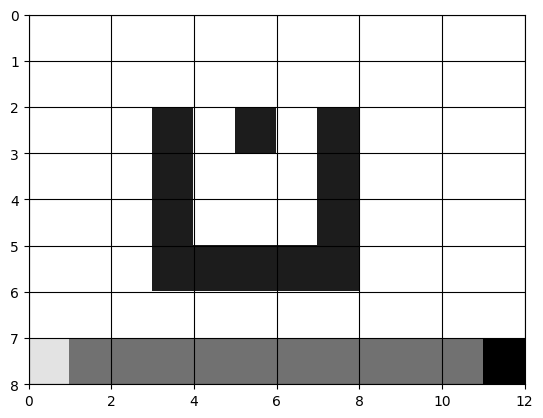

agent select (0, -1)
turn:0


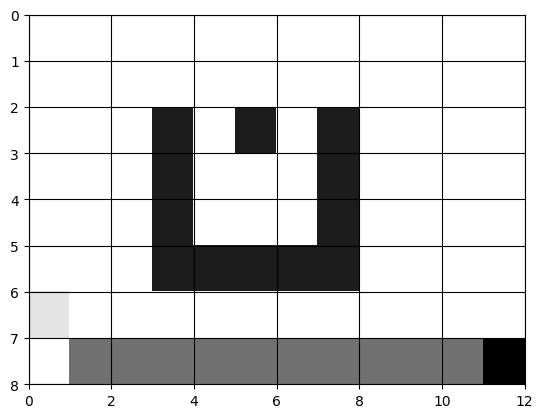

agent select (1, 0)
turn:1


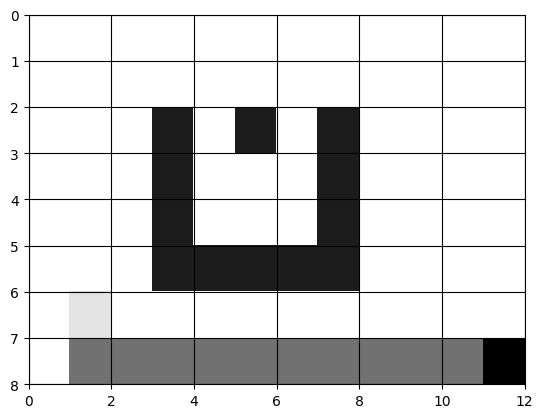

agent select (1, 0)
turn:2


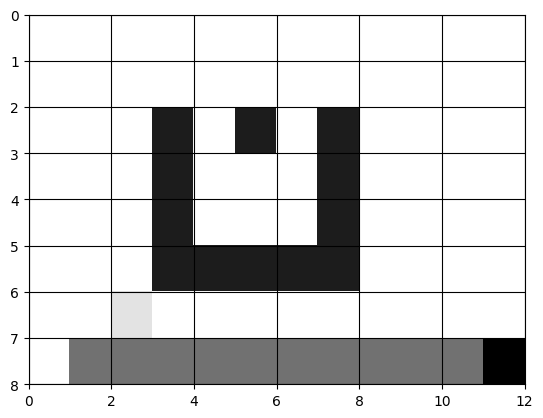

agent select (1, 0)
turn:3


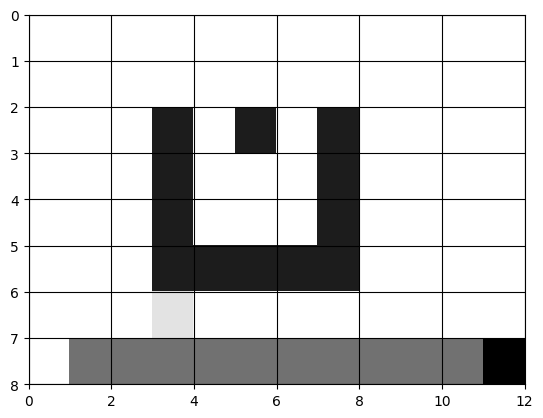

agent select (1, 0)
turn:4


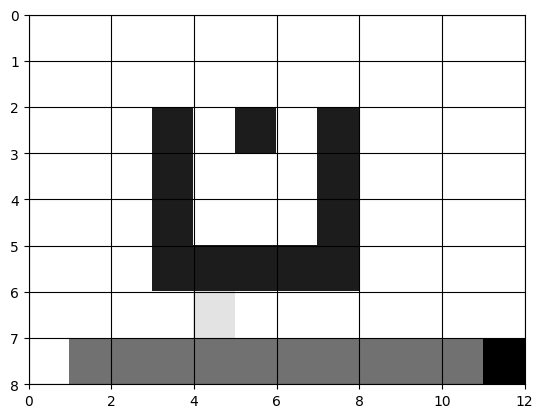

agent select (1, 0)
turn:5


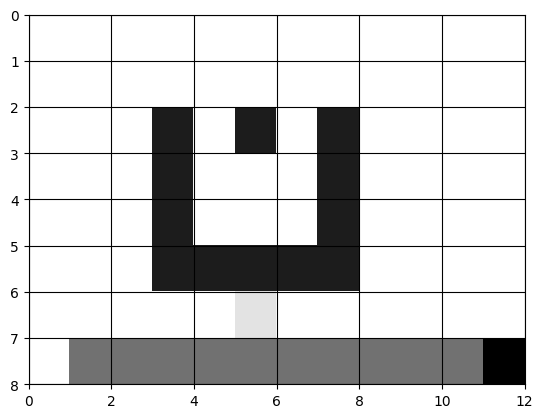

agent select (1, 0)
turn:6


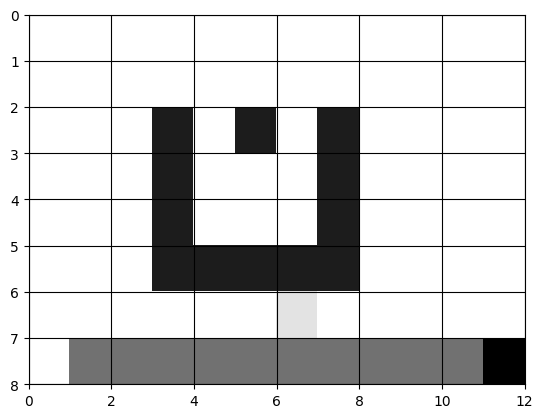

agent select (1, 0)
turn:7


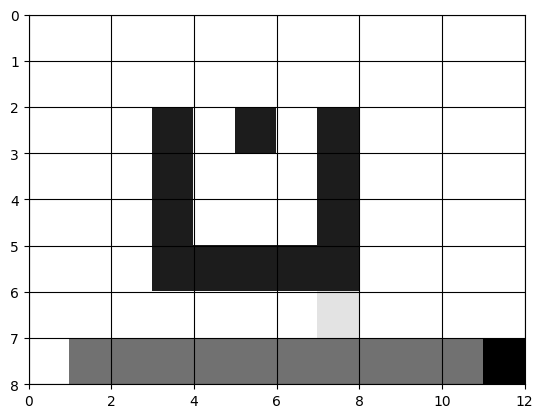

agent select (1, 0)
turn:8


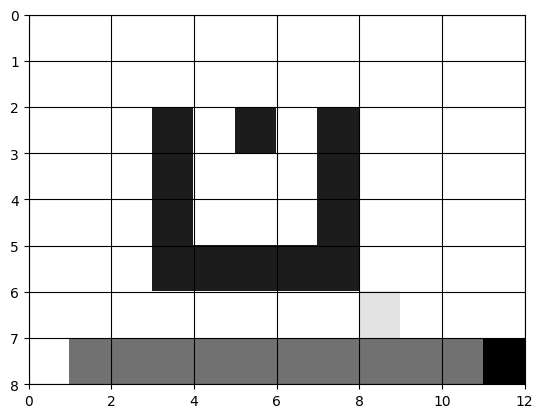

agent select (1, 0)
turn:9


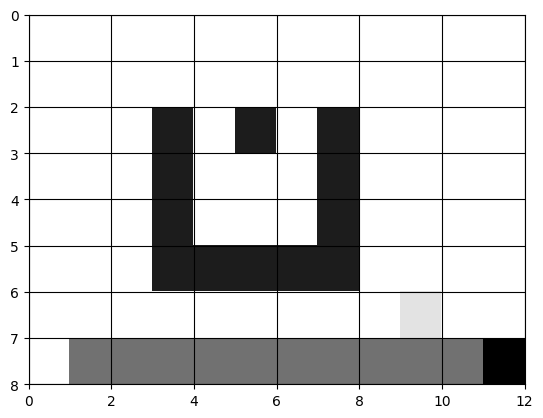

agent select (1, 0)
turn:10


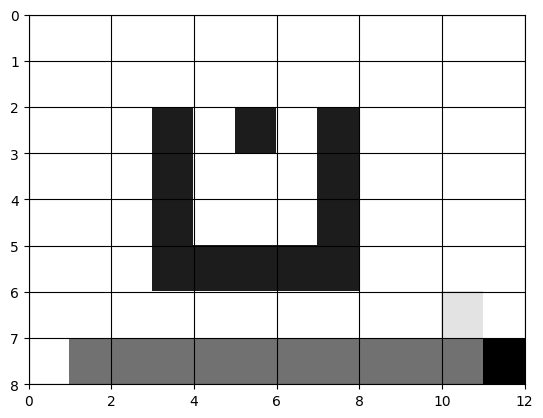

agent select (1, 0)
turn:11


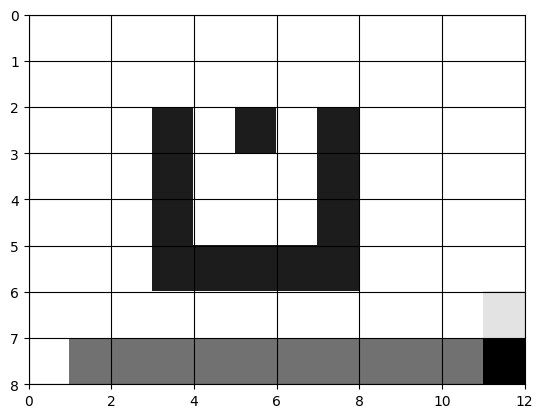

agent select (0, 1)
turn:12


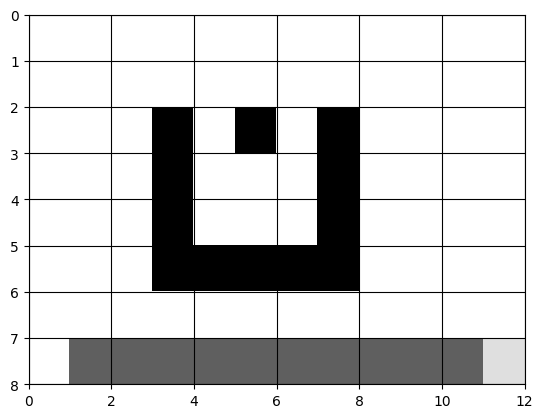

|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, -1)	|(-1, 0)	|(0, -1)	|(0, -1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, -1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, 1)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, -1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(0, -1)	|(1, 0)	|(-1, 0)	|(0, 1)	|(0, -1)	|(-1, 0)	|(-1, 0)	|(-1, 0)	|


In [20]:
env_softmax = CuriosityEnv()
agent_softmax = OffPolicyAgent(env_softmax.width, env_softmax.height, param=(0.1, 0.9, 0.1), behavior_policy=softmax, name='Q+softmax')

steps_Q_softmax = sim(epi=episode, env=env_softmax, agent=agent_softmax)

## CuriosityAgent

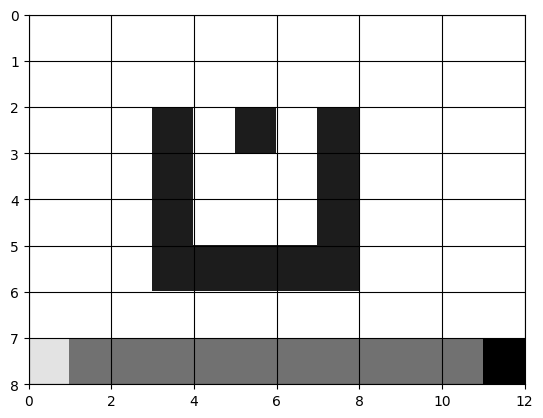

agent select (0, -1)
turn:0


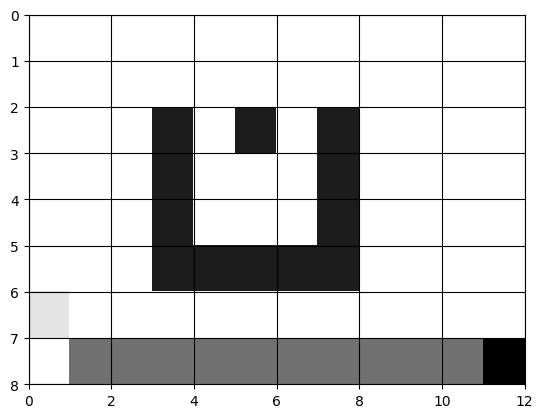

agent select (0, -1)
turn:1


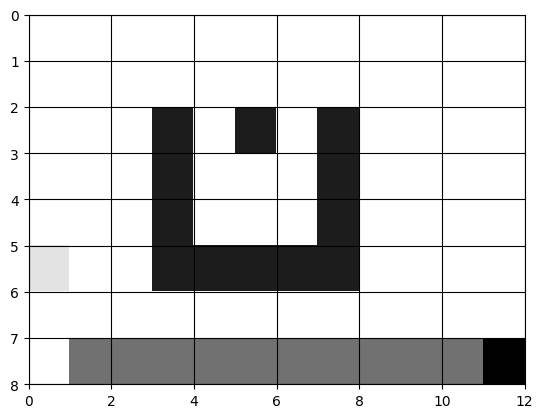

agent select (-1, 0)
turn:2


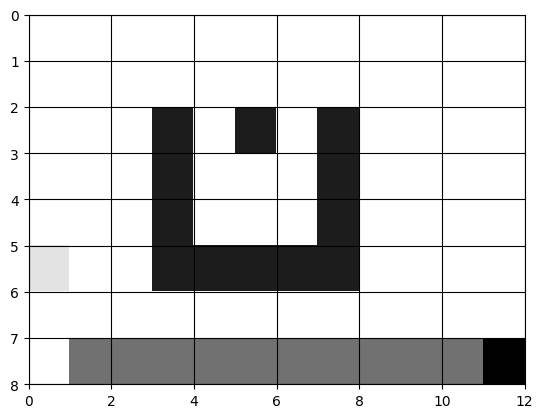

agent select (-1, 0)
turn:3


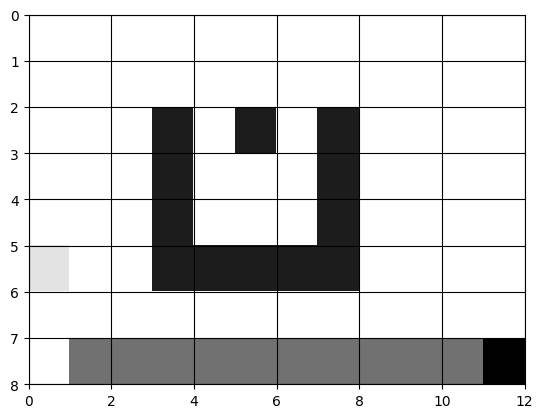

agent select (1, 0)
turn:4


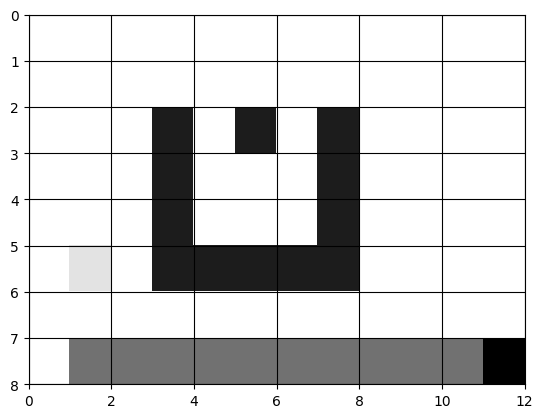

agent select (0, -1)
turn:5


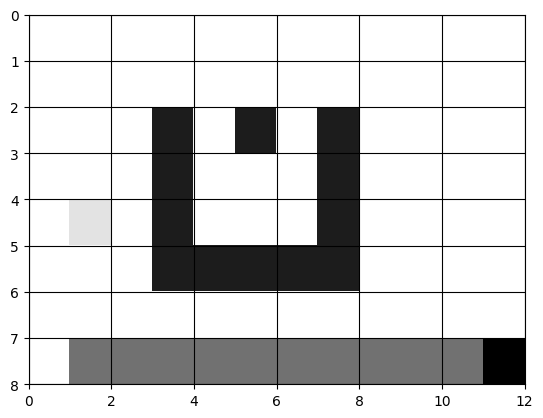

agent select (0, 1)
turn:6


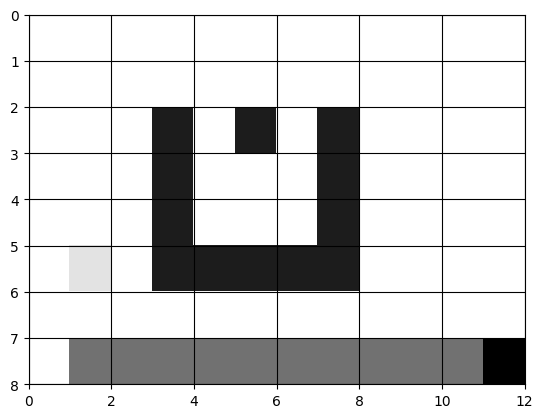

agent select (1, 0)
turn:7


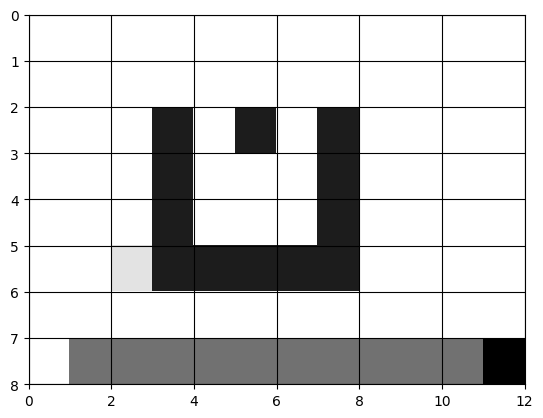

agent select (0, 1)
turn:8


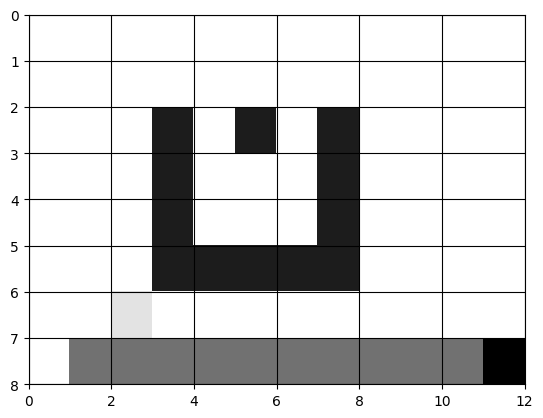

agent select (1, 0)
turn:9


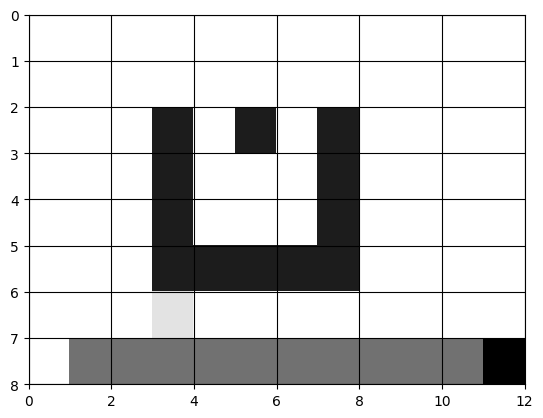

agent select (1, 0)
turn:10


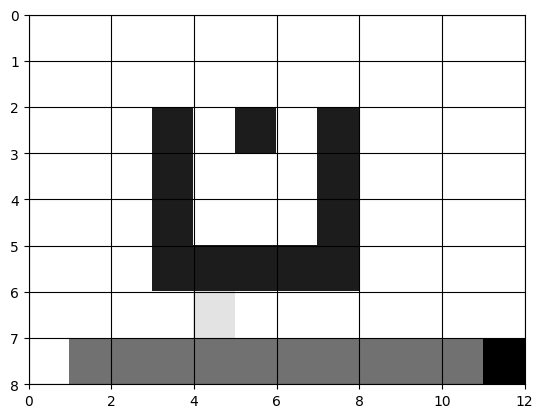

agent select (1, 0)
turn:11


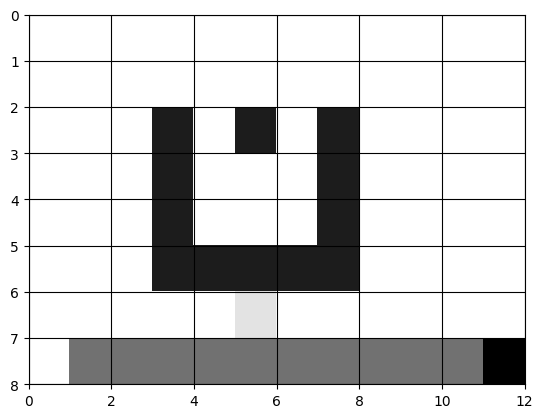

agent select (1, 0)
turn:12


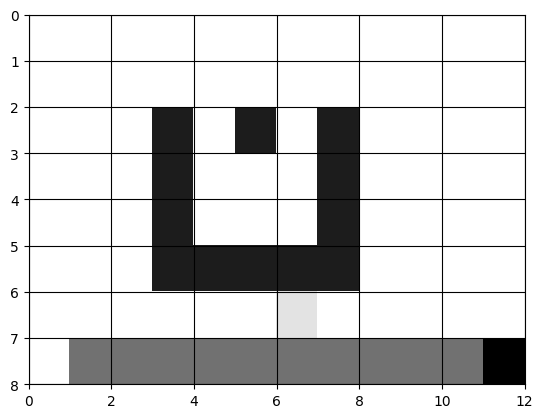

agent select (1, 0)
turn:13


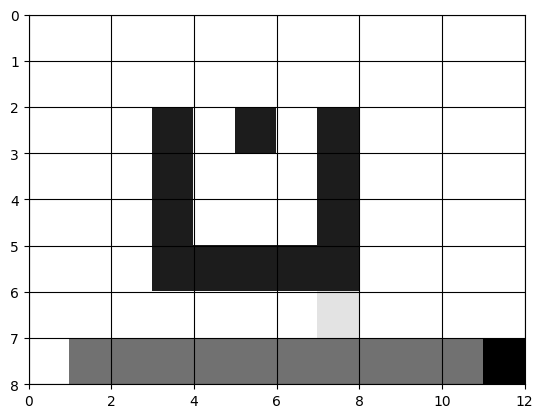

agent select (1, 0)
turn:14


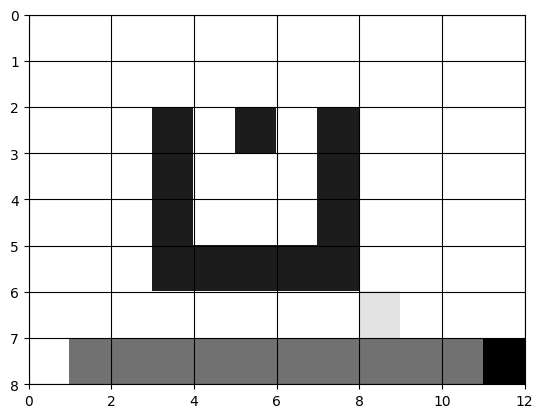

agent select (1, 0)
turn:15


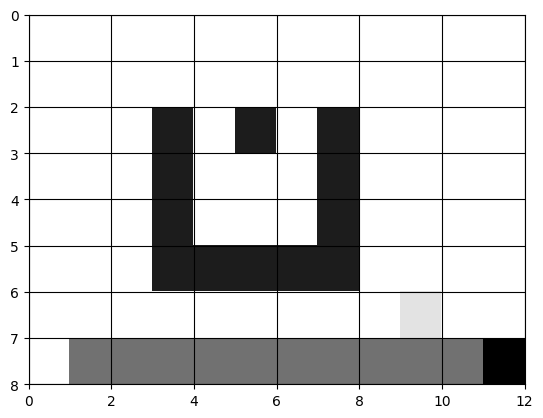

agent select (1, 0)
turn:16


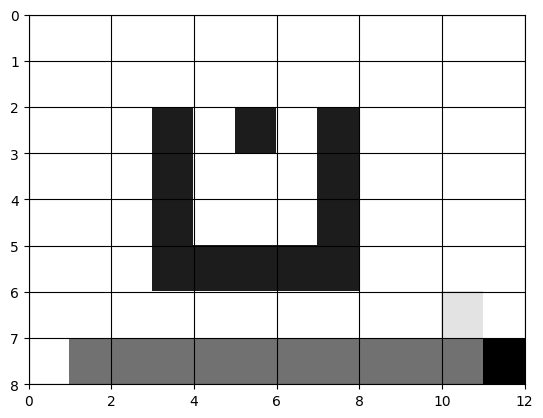

agent select (1, 0)
turn:17


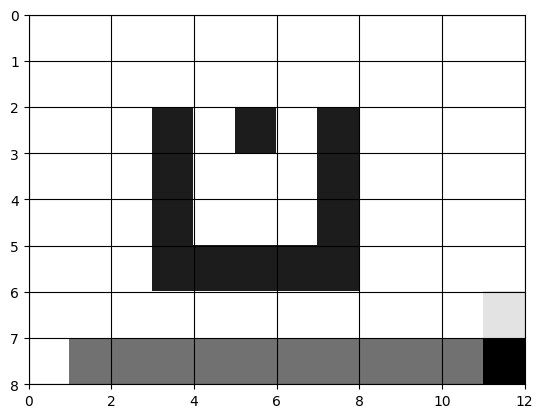

agent select (0, 1)
turn:18


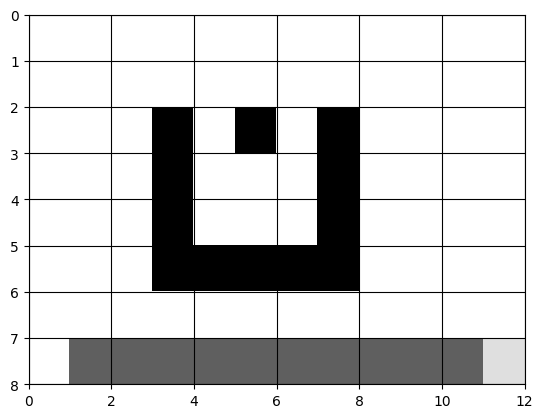

|(0, -1)	|(0, 1)	|(0, -1)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(-1, 0)	|(0, -1)	|(1, 0)	|(0, -1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|
|(0, 1)	|(-1, 0)	|(0, -1)	|(0, 1)	|(0, -1)	|(1, 0)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(0, -1)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(-1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, -1)	|(0, -1)	|(0, 1)	|(-1, 0)	|(-1, 0)	|(-1, 0)	|


In [21]:
env_curious = CuriosityEnv()
agent_curious = CuriosityAgent(env_curious.width, env_curious.height, name='curiosity', beta=1.0)
steps_curiosity = sim(episode, env_curious, agent_curious)

## UCBAgent

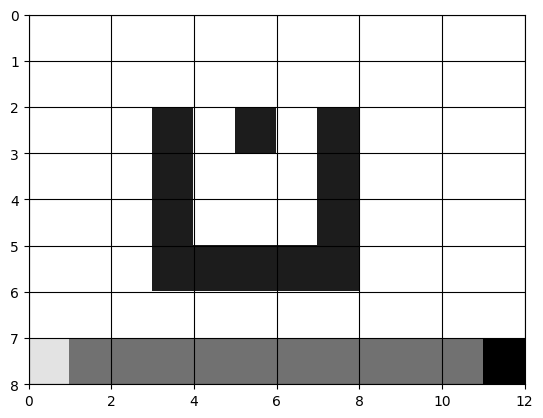

agent select (0, -1)
turn:0


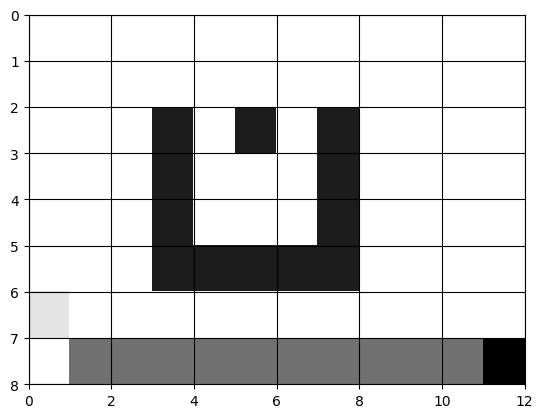

agent select (1, 0)
turn:1


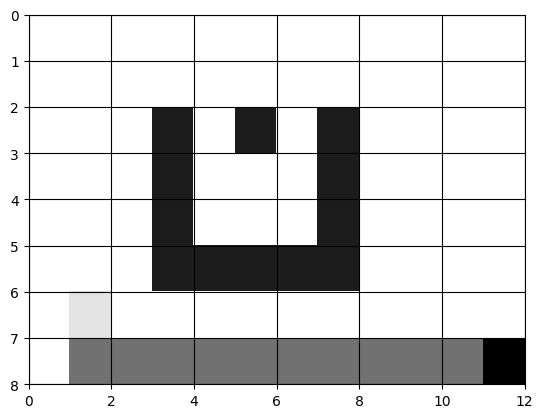

agent select (1, 0)
turn:2


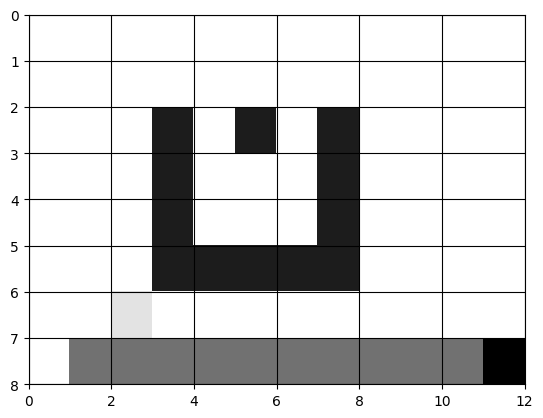

agent select (1, 0)
turn:3


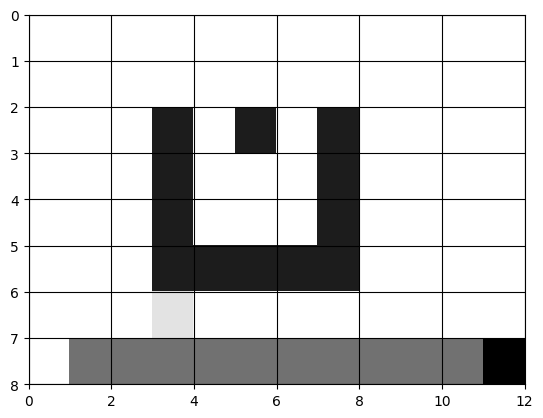

agent select (1, 0)
turn:4


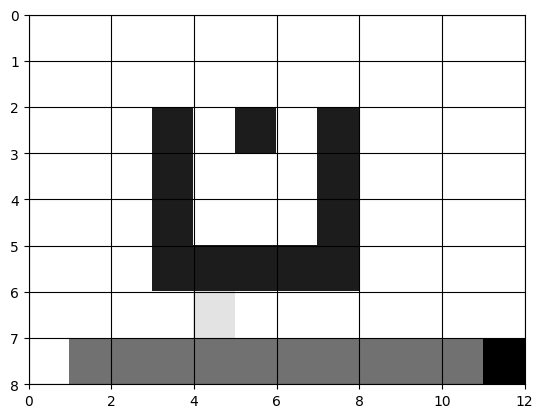

agent select (1, 0)
turn:5


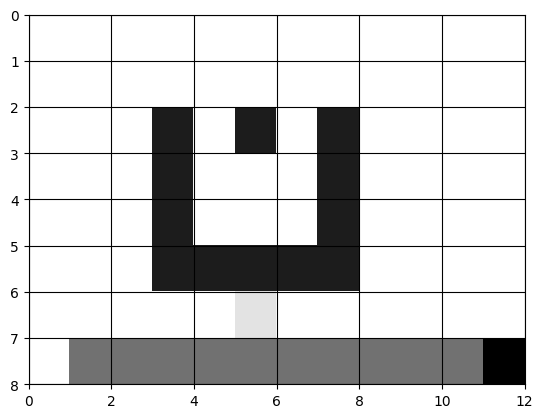

agent select (1, 0)
turn:6


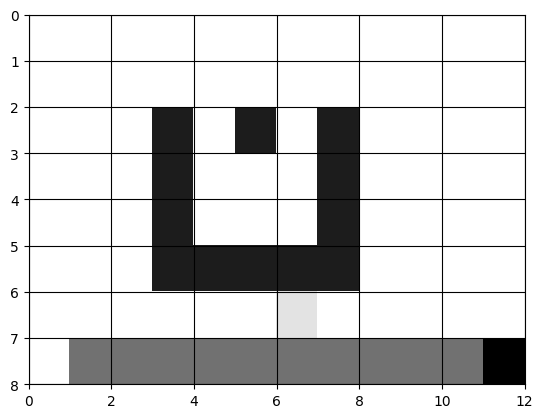

agent select (1, 0)
turn:7


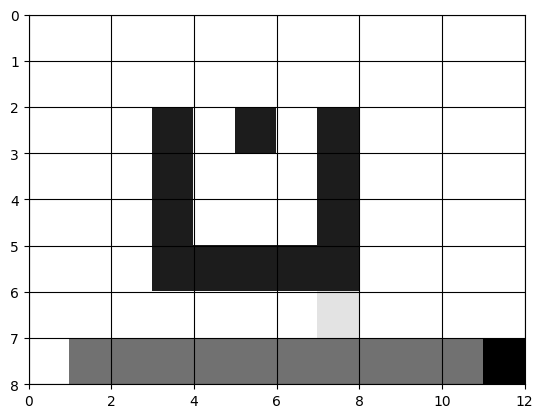

agent select (1, 0)
turn:8


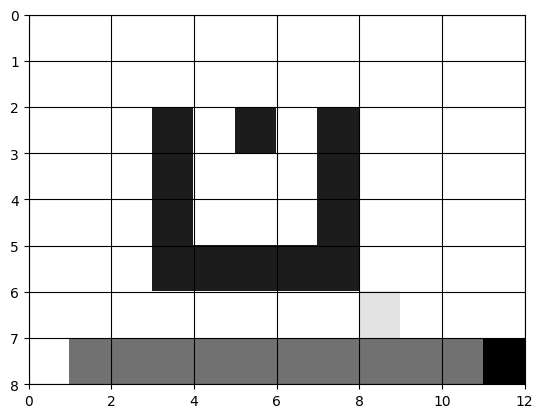

agent select (1, 0)
turn:9


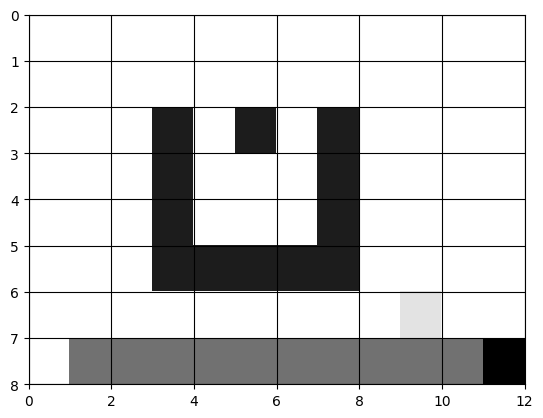

agent select (1, 0)
turn:10


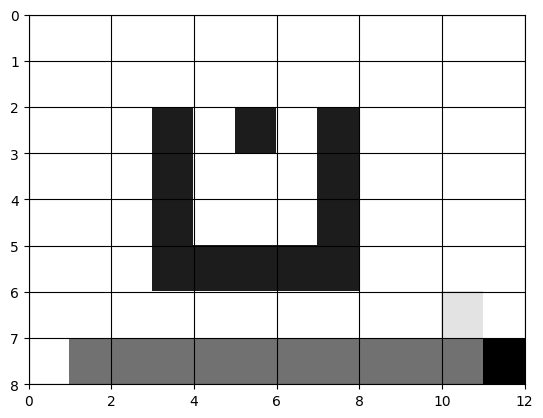

agent select (1, 0)
turn:11


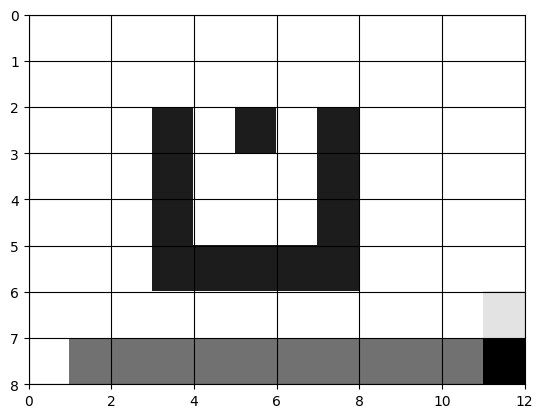

agent select (0, 1)
turn:12


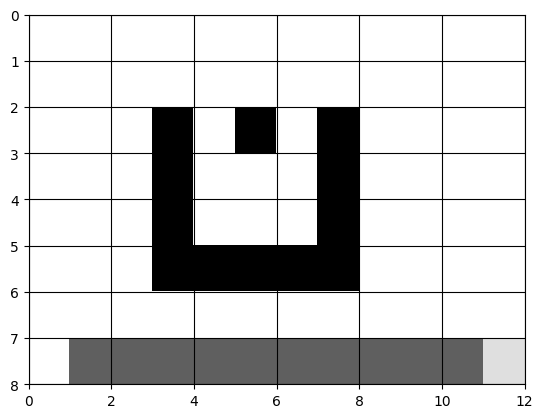

|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, -1)	|
|(-1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(0, -1)	|(-1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, -1)	|


In [22]:
env_ucb = CuriosityEnv()

agent_ucb = OffPolicyAgent(env_ucb.width, env_ucb.height, param=(0.1, 0.9, 1.0),behavior_policy=select_ucb, name='Q+UCB')

steps_ucb = sim(epi=episode, env=env_ucb, agent=agent_ucb)

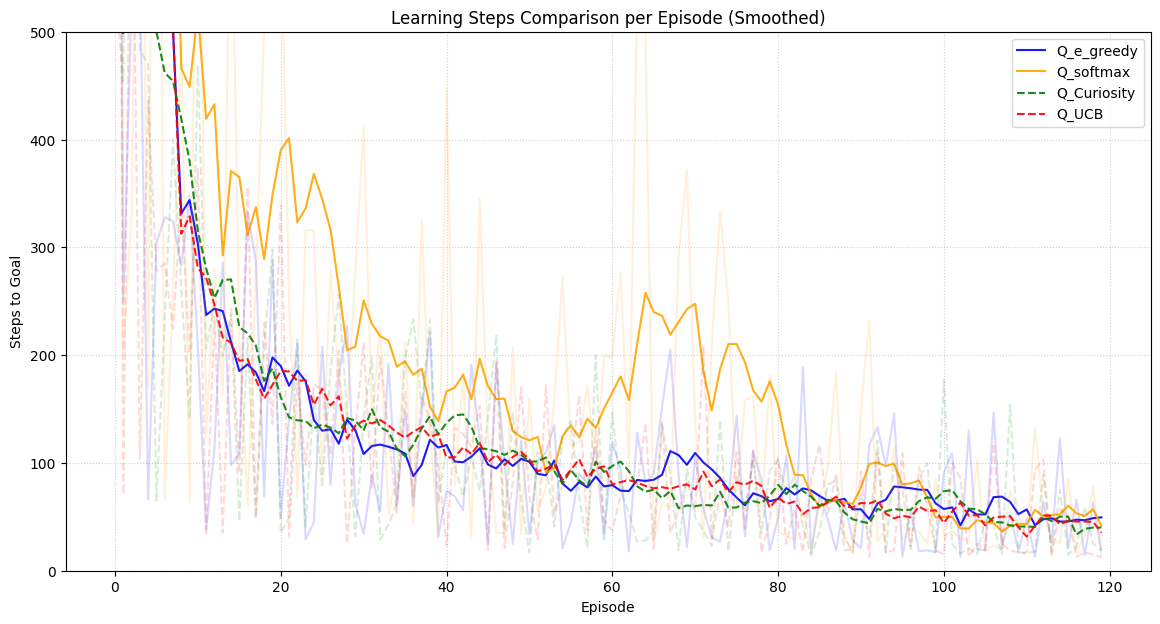

last policy steps
  Q_e_greedy: 	19 steps
  Q_softmax: 		13 steps
  Q_Curiosity: 	19 steps
  Q_UCB: 		13 steps


In [23]:
# 滑らかさの度合い
window_size = 8

plt.figure(figsize=(14.0, 7.0))

# 1. Q_e_greedy
plt.plot(np.arange(episode), steps_Q_e_greedy, color='blue', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_Q_e_greedy, window_size), color='blue', label='Q_e_greedy', alpha=0.9)

# 2. Q_softmax
plt.plot(np.arange(episode), steps_Q_softmax, color='orange', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_Q_softmax, window_size), color='orange', label='Q_softmax', alpha=0.9)

# 3. Q_Curiosity
plt.plot(np.arange(episode), steps_curiosity, color='green', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_curiosity, window_size), color='green', label='Q_Curiosity', alpha=0.9, linestyle='--')

# 4. Q_UCB
plt.plot(np.arange(episode), steps_ucb, color='red', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_ucb, window_size), color='red', label='Q_UCB', alpha=0.9, linestyle='--')

# グラフの装飾
plt.title('Learning Steps Comparison per Episode (Smoothed)')
plt.xlabel('Episode')
plt.ylabel('Steps to Goal')

plt.ylim(0, 500)

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 最終エピソードの結果出力
print('last policy steps')
print('  Q_e_greedy: \t{} steps'.format(steps_Q_e_greedy[-1]))
print('  Q_softmax: \t\t{} steps'.format(steps_Q_softmax[-1]))
print('  Q_Curiosity: \t{} steps'.format(steps_curiosity[-1]))
print('  Q_UCB: \t\t{} steps'.format(steps_ucb[-1]))

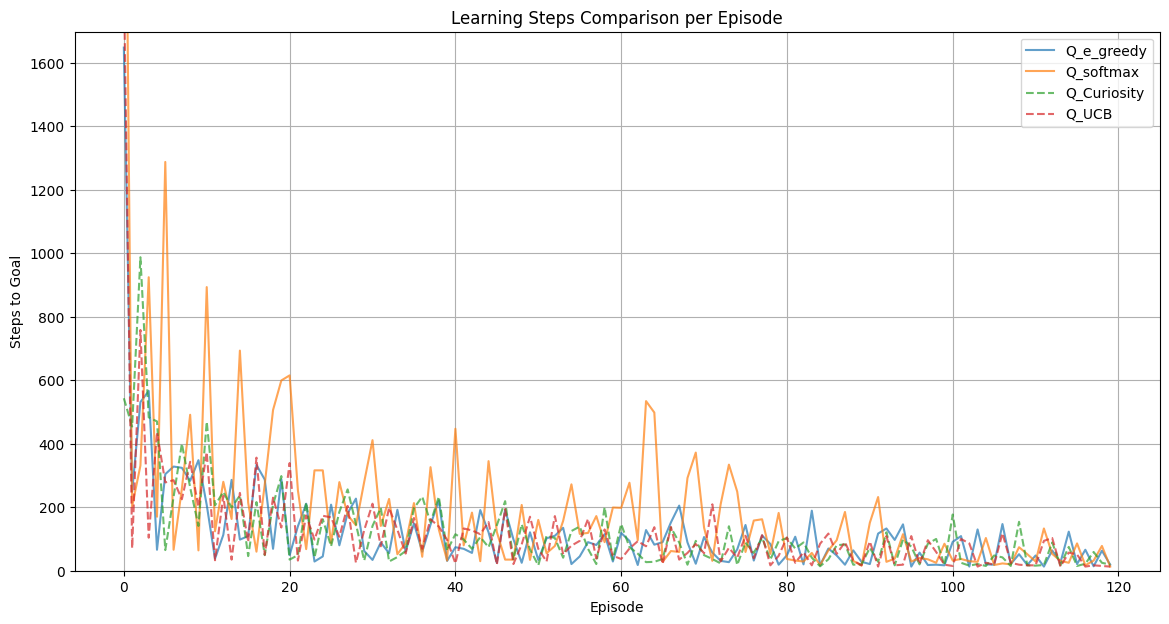

last policy steps
  Q_e_greedy: 	19 steps
  Q_softmax: 		13 steps
  Q_Curiosity: 	19 steps
  Q_UCB: 		13 steps


In [24]:
plt.figure(figsize=(14.0, 7.0))
plt.plot(np.arange(episode), steps_Q_e_greedy, label='Q_e_greedy', alpha=0.7)
plt.plot(np.arange(episode), steps_Q_softmax, label='Q_softmax', alpha=0.7)
plt.plot(np.arange(episode), steps_curiosity, label='Q_Curiosity', alpha=0.7, linestyle='--')
plt.plot(np.arange(episode), steps_ucb, label='Q_UCB', alpha=0.7, linestyle='--')

plt.title('Learning Steps Comparison per Episode')
plt.xlabel('Episode')
plt.ylabel('Steps to Goal')
plt.ylim(0, max(steps_Q_e_greedy) + 50)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print('last policy steps')
print('  Q_e_greedy: \t{} steps'.format(steps_Q_e_greedy[-1]))
print('  Q_softmax: \t\t{} steps'.format(steps_Q_softmax[-1]))
print('  Q_Curiosity: \t{} steps'.format(steps_curiosity[-1]))
print('  Q_UCB: \t\t{} steps'.format(steps_ucb[-1]))

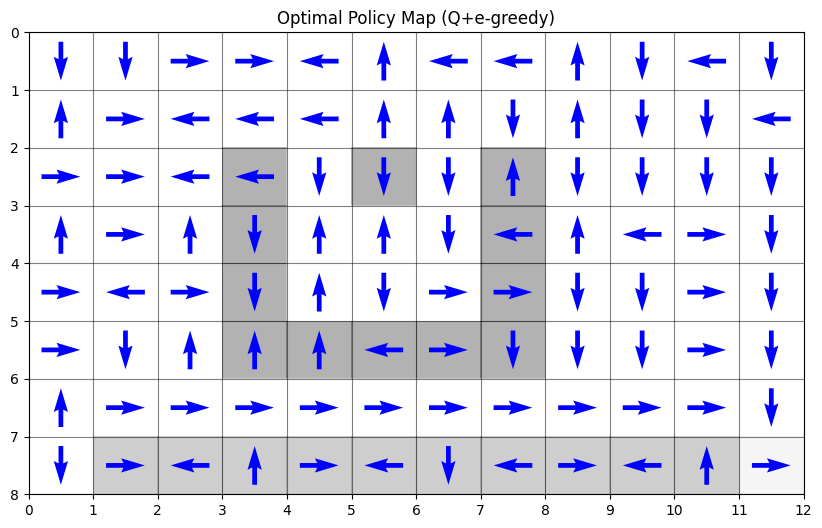

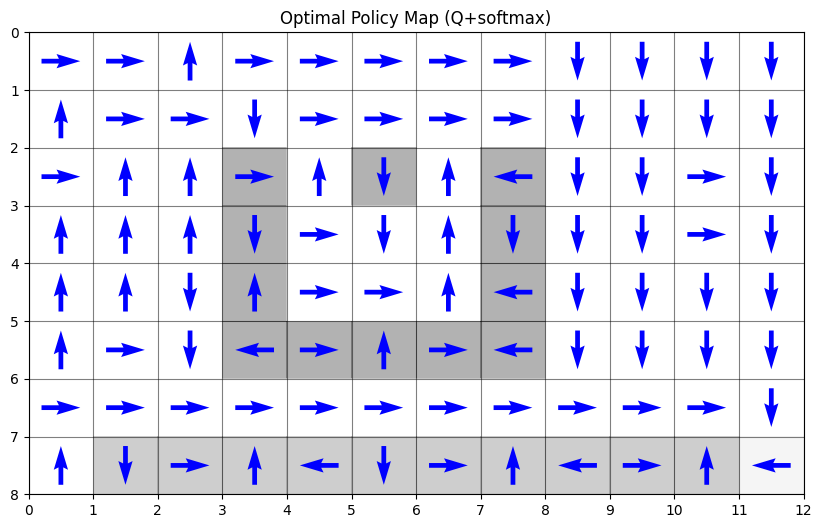

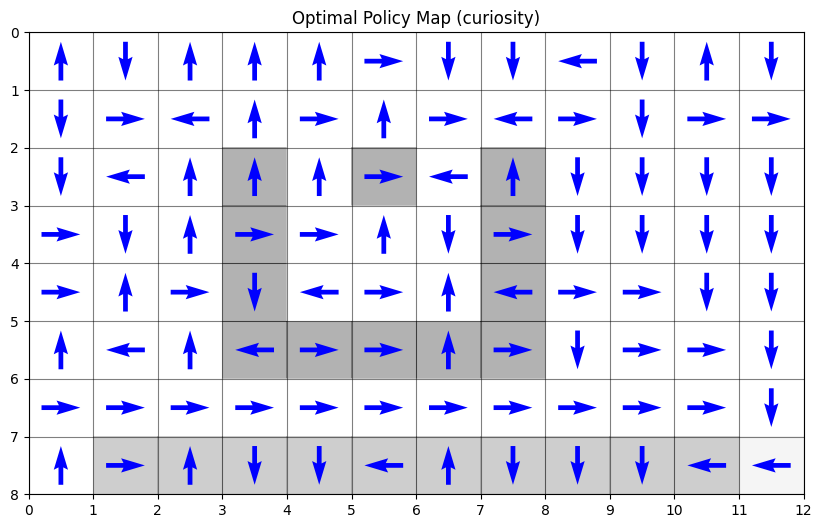

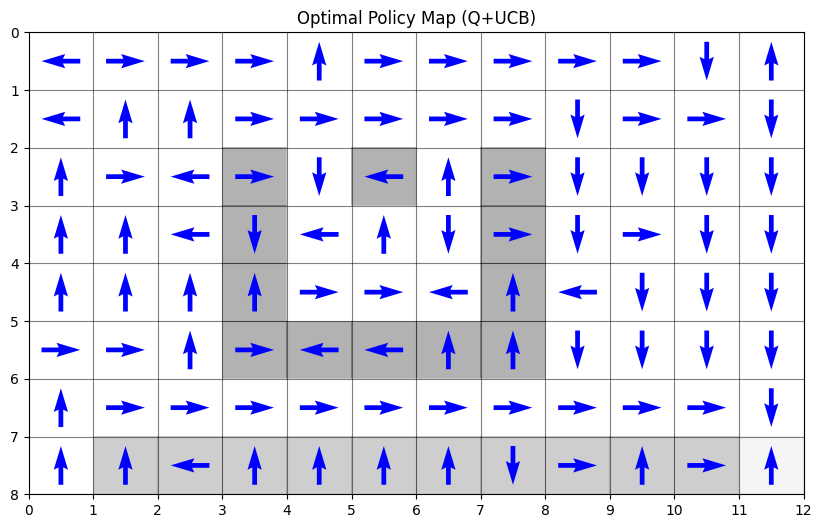

In [25]:
plot_policy(agent_egreedy, env_egreedy)
plot_policy(agent_softmax, env_softmax)
plot_policy(agent_curious, env_curious)
plot_policy(agent_ucb, env_ucb)

# マップ改良(2)

In [26]:
class CustomCuriosityEnv(Env):
    """
    拡張マップ環境
    - サイズ: 15x10
    - 壁(8): 通行不可 (-1)
    - 落とし穴(6): スタート地点に戻される (-20)
    - 毒沼(4): 通過に大きなペナルティ(-5)がかかるが、一度通ると普通の道になる
    """
    def __init__(self, post_coordinates=(0, 0), pos_goal=(14, 9)):
        # マップサイズを15x10に変更
        self._size = {'width': 15, 'height': 10}
        self._state = [[0 for _ in range(self._size['height'])] for _ in range(self._size['width'])]

        self._coordinates = post_coordinates
        self._s = post_coordinates
        self._goal = pos_goal

    def init_episode(self):
        # 毎エピソードの初期化
        coordinate_x, coordinate_y = self._s
        gl_x, gl_y = self._goal
        self._coordinates = self._s

        # 状態をすべてリセット (0: 普通の道)
        self._state = [[0 for _ in range(self._size['height'])] for _ in range(self._size['width'])]

        # スタートとゴールの配置
        self._state[coordinate_x][coordinate_y] = 1
        self._state[gl_x][gl_y] = 9

        # 1. 壁 (8) の配置
        walls = [
            (3, 0), (3, 1), (3, 2), (3, 3), (3, 6), (3, 7), (3, 8),
            (7, 3), (7, 4), (7, 5), (7, 6), (7, 7),
            (11, 1), (11, 2), (11, 3), (11, 4), (11, 6), (11, 7), (11, 8), (11, 9)
        ]
        for wx, wy in walls:
            self._state[wx][wy] = 8

        # 2. 毒沼 (4) の配置 - 一度踏むと消えるがペナルティ大
        swamps = [
            (4, 2), (5, 2), (6, 2),
            (8, 7), (9, 7), (10, 7),
            (1, 6), (1, 7), (1, 8)
        ]
        for sx, sy in swamps:
            self._state[sx][sy] = 4

        # 3. 落とし穴 (6) の配置 - 踏むとスタートに戻る
        traps = [
            (1, 3), (5, 8), (9, 1), (13, 6)
        ]
        for tx, ty in traps:
            self._state[tx][ty] = 6

    def update(self, action):
        dif_x, dif_y = action
        coordinate_x, coordinate_y = self._coordinates

        r = 0
        term = False

        # エージェントが移動するため、元の場所を普通の道(0)に戻す
        self._state[coordinate_x][coordinate_y] = 0

        # 次の座標を計算
        next_x = self._limit_pos(coordinate_x + dif_x, 'width')
        next_y = self._limit_pos(coordinate_y + dif_y, 'height')

        # 行き先のタイルに応じた処理
        next_tile = self._state[next_x][next_y]

        if next_tile == 8:
            # 壁: 移動できず元の位置に留まる
            next_x, next_y = coordinate_x, coordinate_y
            r = -1

        elif next_tile == 9:
            # ゴール: 到達報酬
            r = 1
            term = True

        elif next_tile == 6:
            # 落とし穴: 大きなペナルティを受けてスタート地点へ戻る
            r = -20
            next_x, next_y = self._s

        elif next_tile == 4:
            # 毒沼: 大きなペナルティを受ける（移動は成功する）
            r = -5

        else:
            # 通常の道
            r = -1

        # エージェントの座標を更新し、マップ上に配置
        self._coordinates = (next_x, next_y)
        self._state[next_x][next_y] = 1

        return r, (next_x, next_y), term

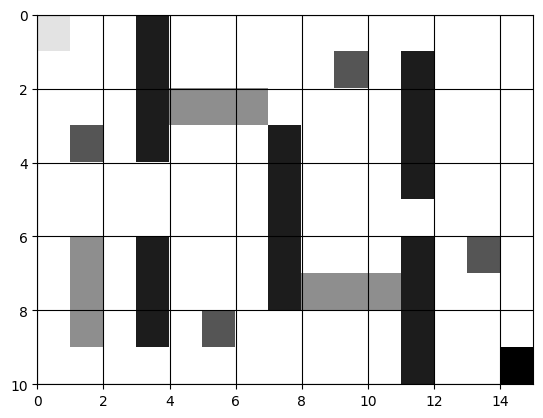

agent select (0, -1)
turn:0


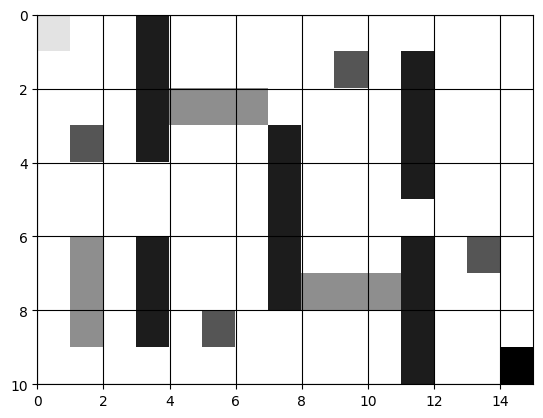

agent select (0, -1)
turn:1


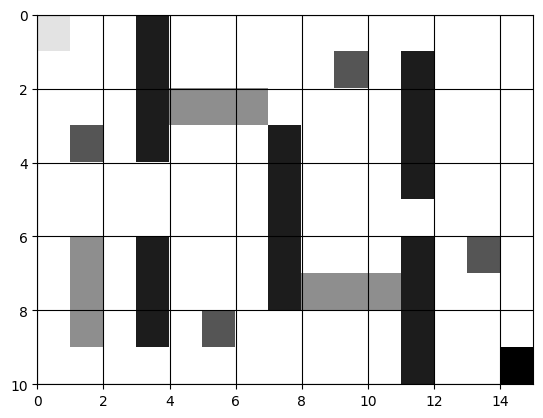

agent select (0, 1)
turn:2


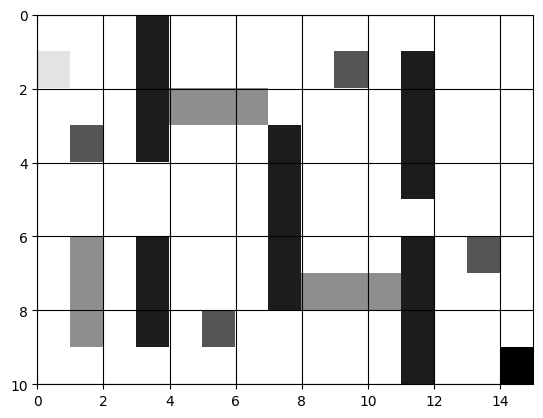

agent select (0, 1)
turn:3


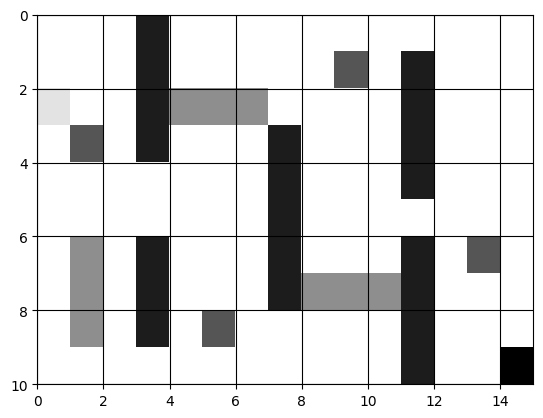

agent select (0, -1)
turn:4


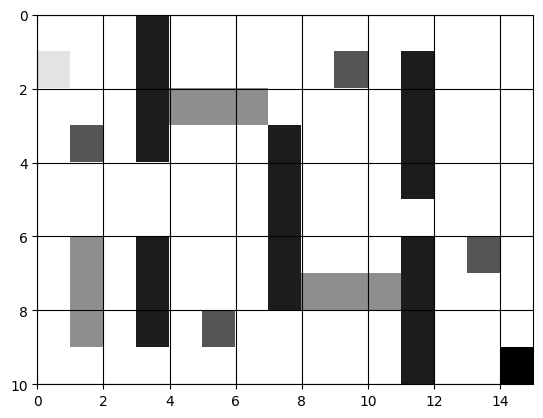

agent select (0, -1)
turn:5


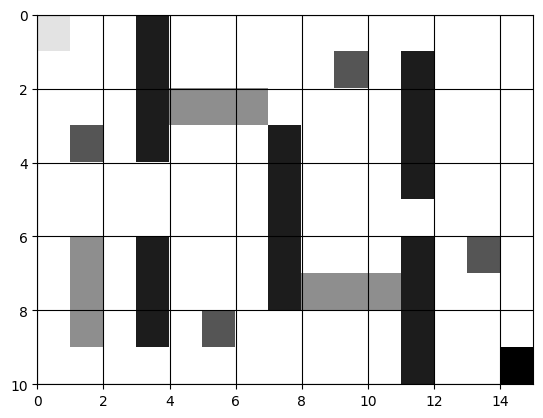

agent select (1, 0)
turn:6


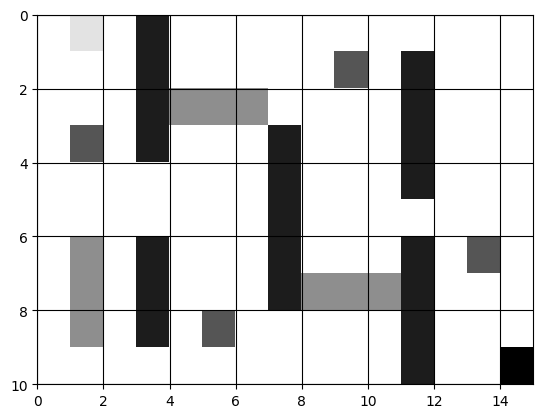

agent select (0, 1)
turn:7


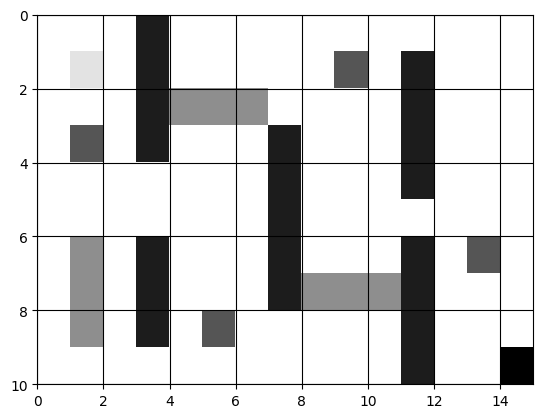

agent select (0, -1)
turn:8


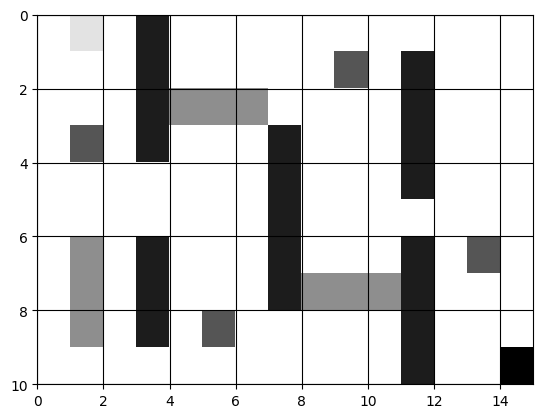

agent select (1, 0)
turn:9


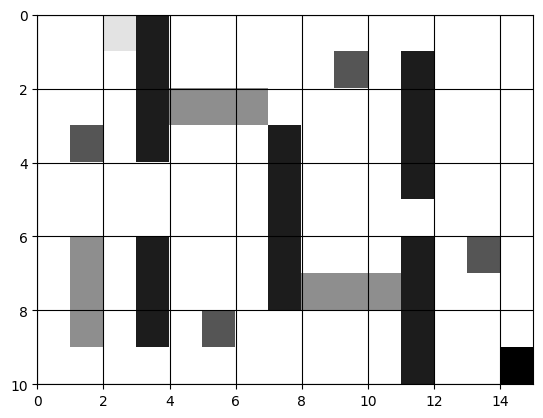

agent select (0, 1)
turn:10


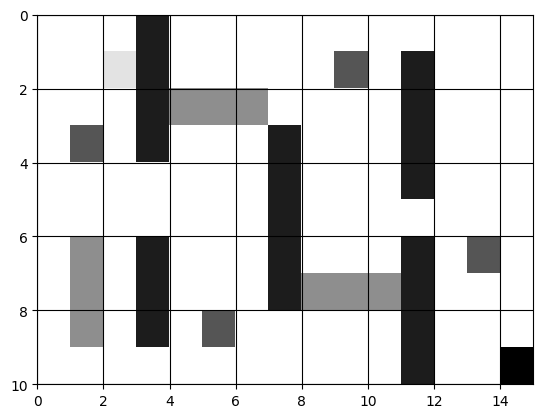

agent select (0, 1)
turn:11


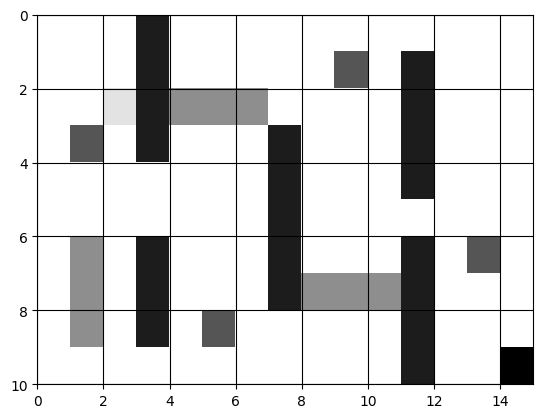

agent select (0, 1)
turn:12


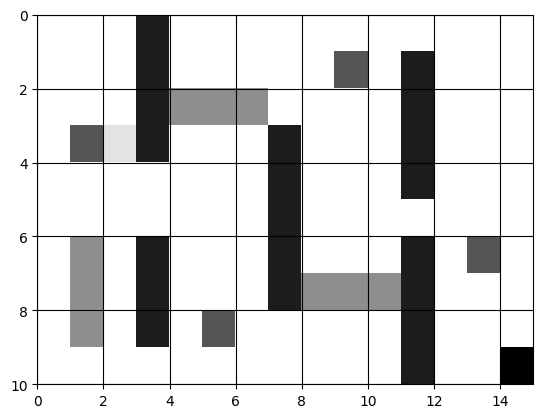

agent select (0, 1)
turn:13


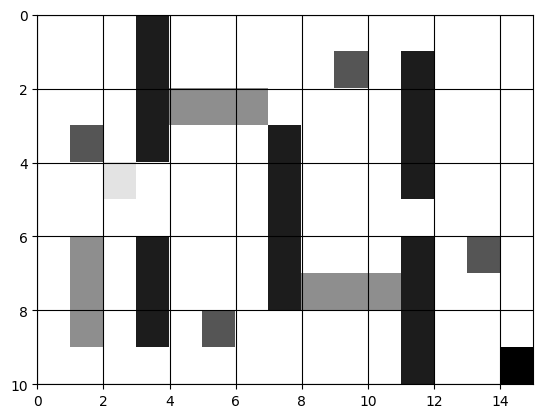

agent select (1, 0)
turn:14


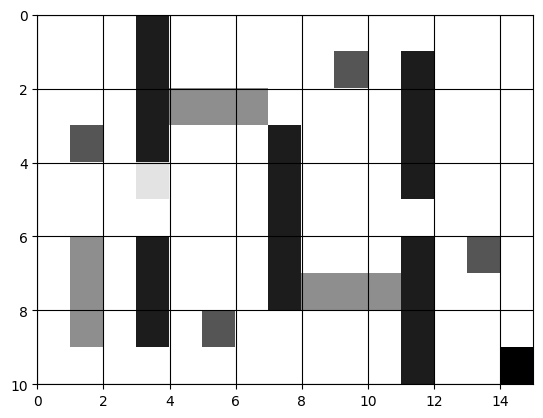

agent select (0, -1)
turn:15


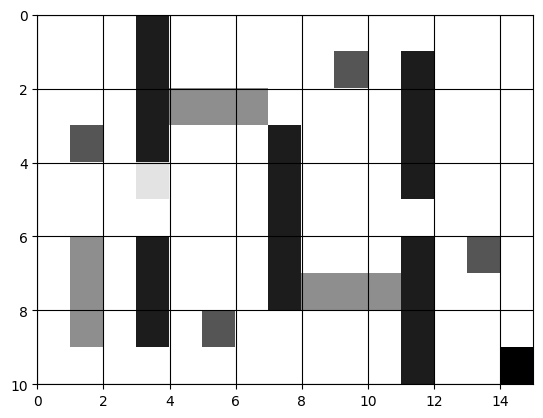

agent select (0, -1)
turn:16


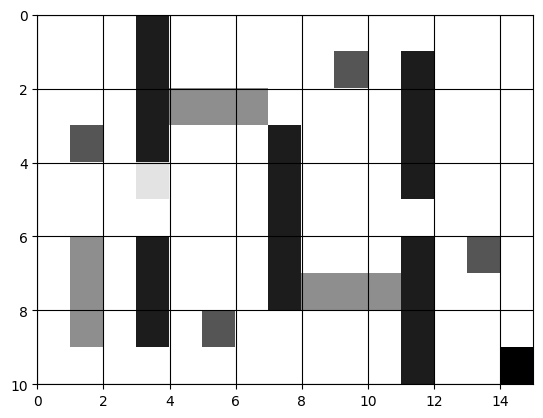

agent select (1, 0)
turn:17


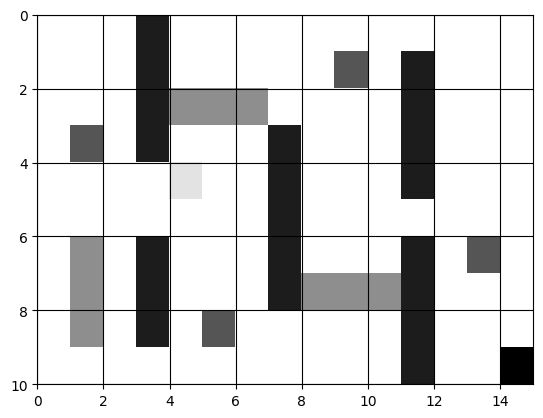

agent select (0, 1)
turn:18


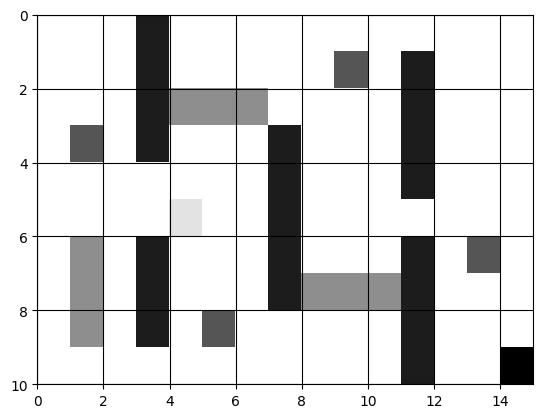

agent select (0, 1)
turn:19


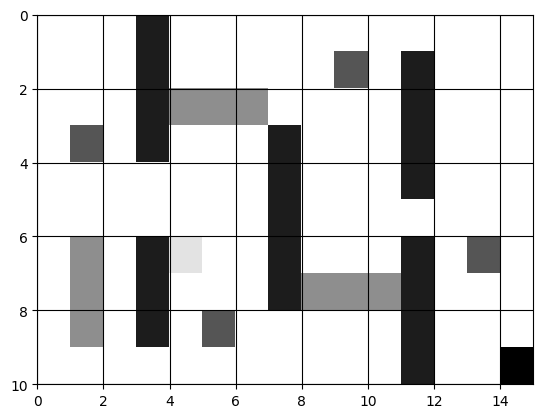

agent select (1, 0)
turn:20


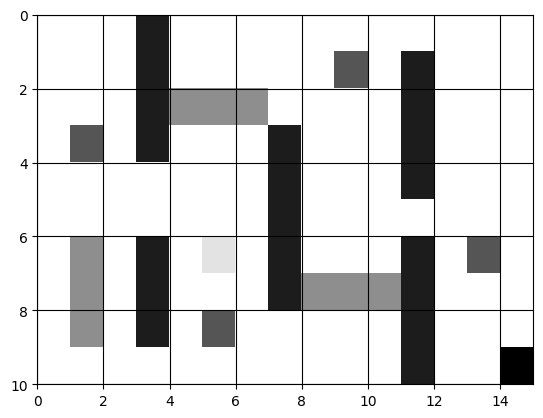

agent select (0, 1)
turn:21


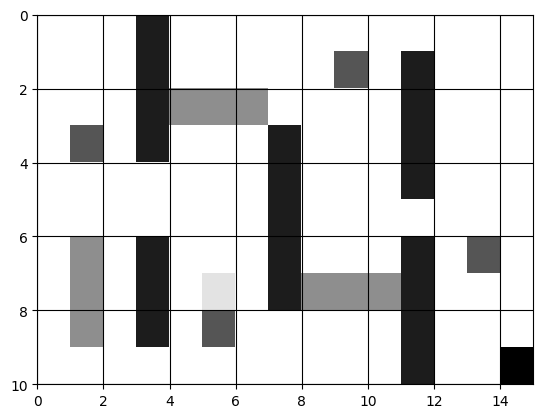

agent select (1, 0)
turn:22


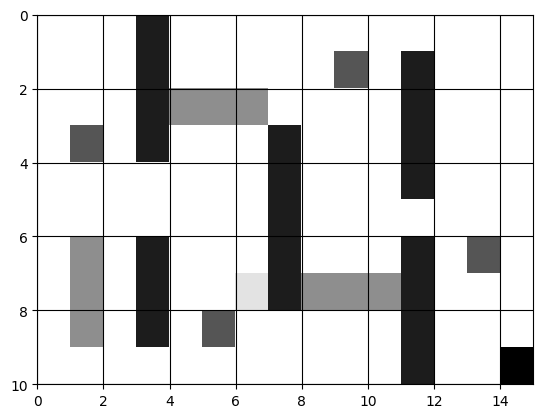

agent select (0, 1)
turn:23


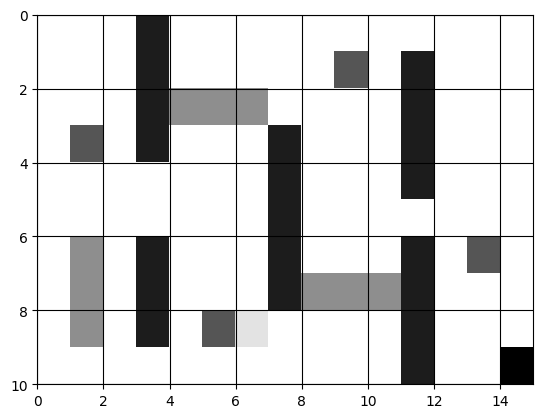

agent select (1, 0)
turn:24


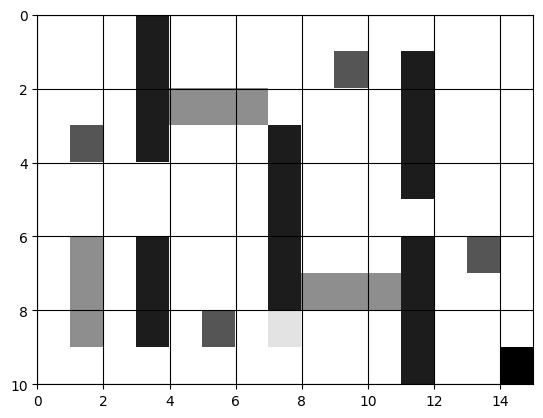

agent select (1, 0)
turn:25


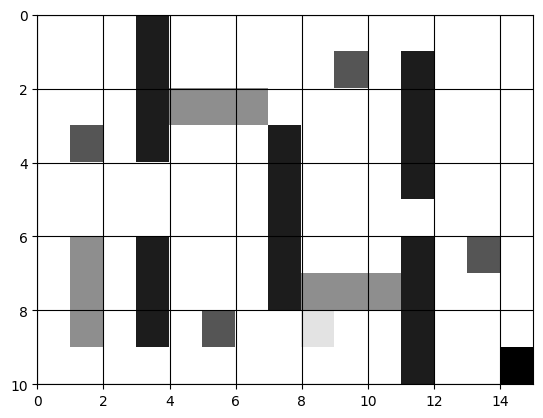

agent select (1, 0)
turn:26


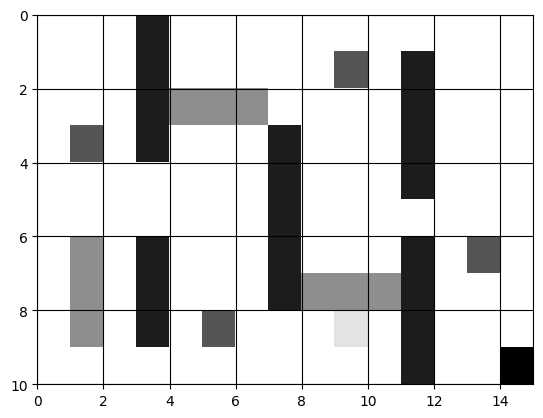

agent select (1, 0)
turn:27


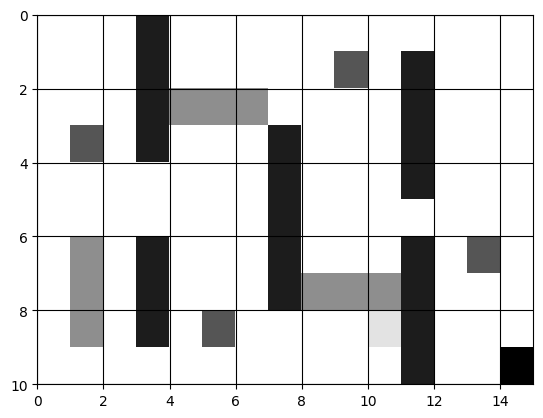

agent select (0, -1)
turn:28


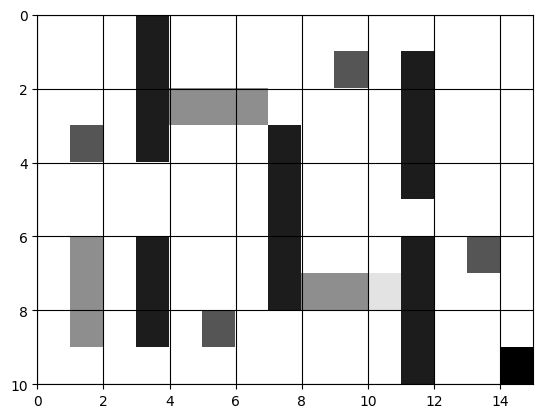

agent select (0, -1)
turn:29


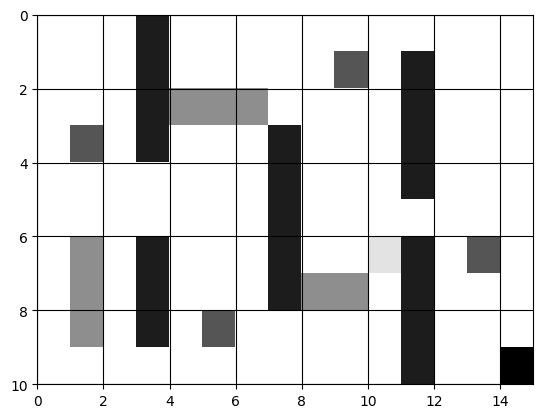

agent select (0, -1)
turn:30


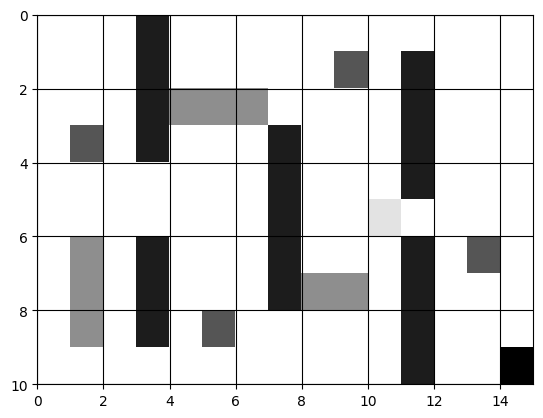

agent select (1, 0)
turn:31


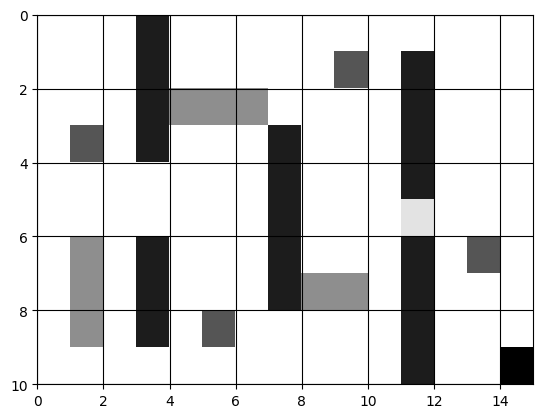

agent select (1, 0)
turn:32


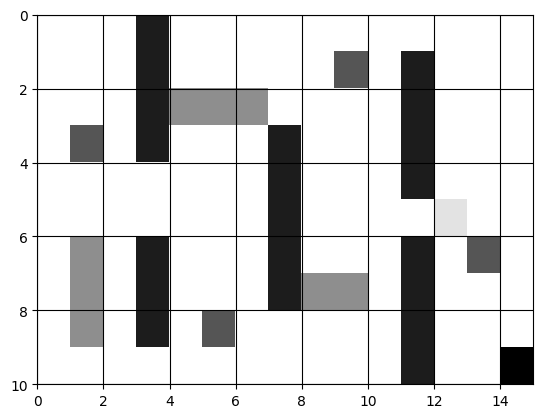

agent select (0, 1)
turn:33


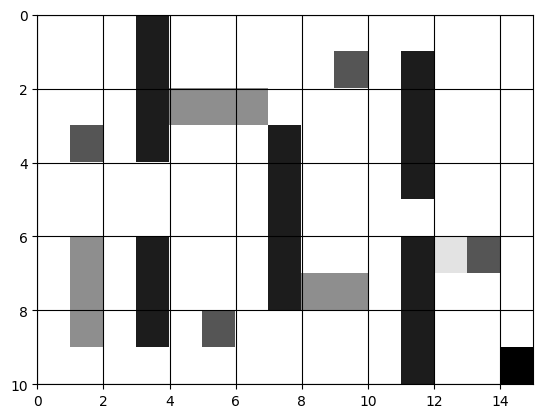

agent select (0, 1)
turn:34


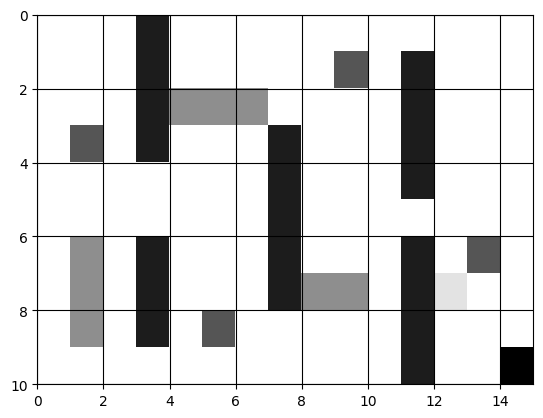

agent select (1, 0)
turn:35


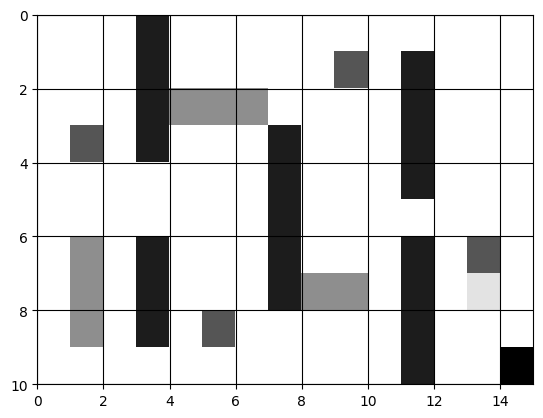

agent select (1, 0)
turn:36


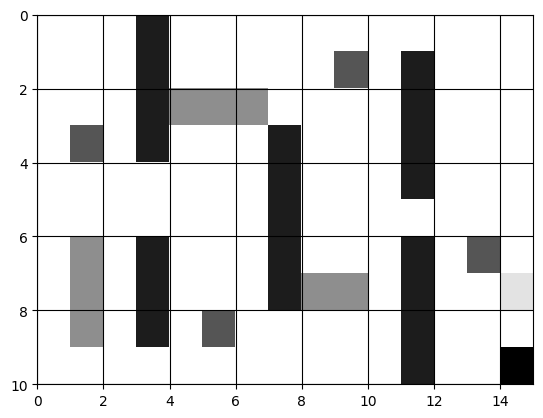

agent select (0, 1)
turn:37


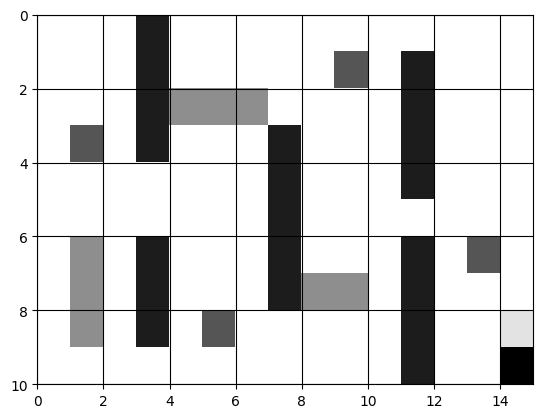

agent select (0, 1)
turn:38


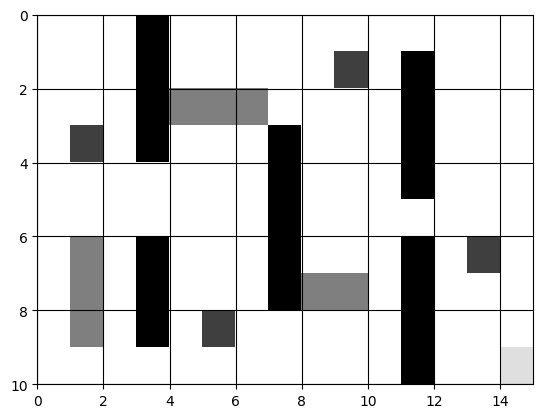

|(0, 1)	|(0, 1)	|(-1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, -1)	|
|(1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(1, 0)	|(0, -1)	|(0, -1)	|(0, 1)	|(-1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|
|(-1, 0)	|(-1, 0)	|(0, 1)	|(0, -1)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, -1)	|(1, 0)	|(1, 0)	|(-1, 0)	|(0, -1)	|(1, 0)	|(0, -1)	|(0, 1)	|
|(0, 1)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(-1, 0)	|(-1, 0)	|(1, 0)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|
|(-1, 0)	|(-1, 0)	|(0, -1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, -1)	|(1, 0)	|(

In [27]:
episode = 300

env_eg = CustomCuriosityEnv()
agent_eg = OffPolicyAgent(env_eg.width, env_eg.height, param=(0.1, 0.9, 0.1), behavior_policy=e_greedy, name='Q+e-greedy')
steps_eg = sim(epi=episode, env=env_eg, agent=agent_eg)

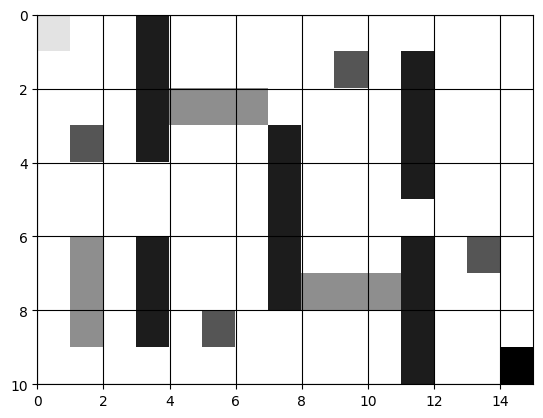

agent select (0, 1)
turn:0


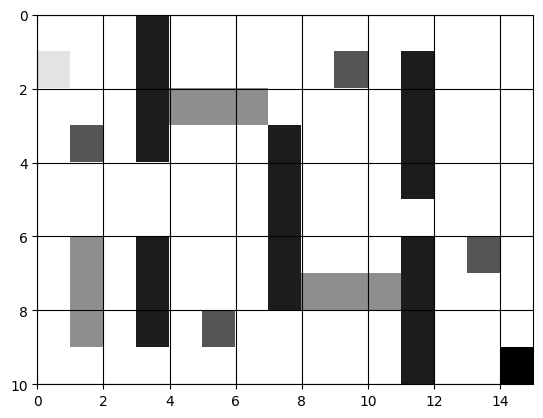

agent select (0, 1)
turn:1


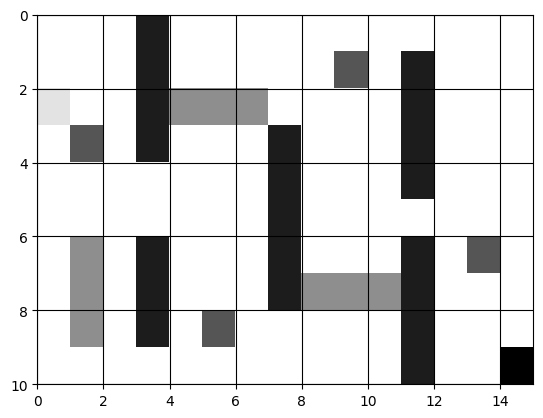

agent select (0, 1)
turn:2


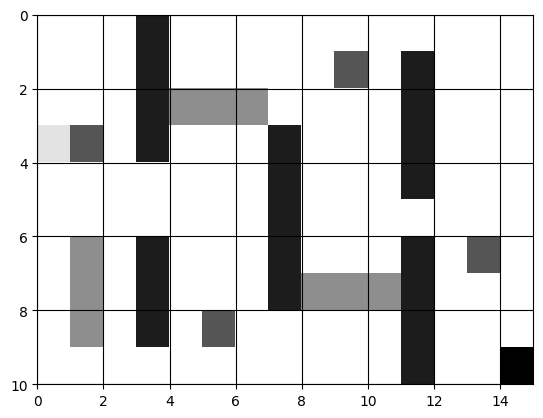

agent select (0, 1)
turn:3


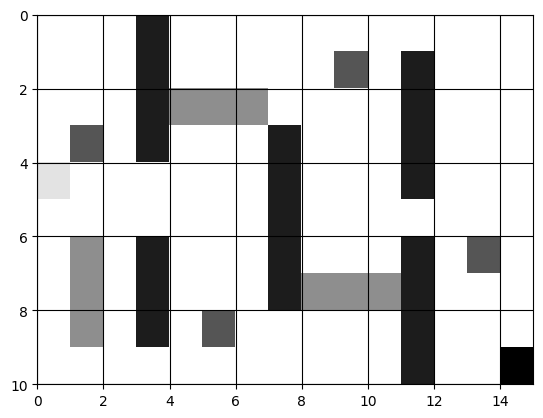

agent select (1, 0)
turn:4


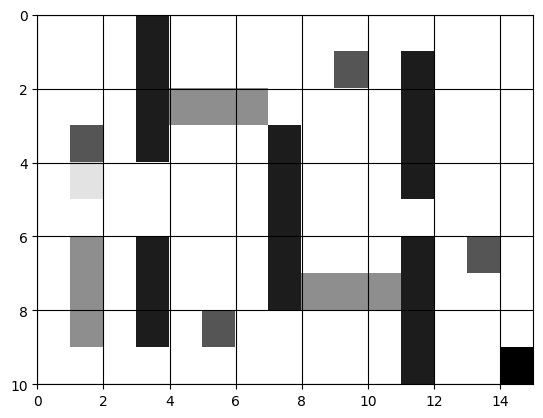

agent select (1, 0)
turn:5


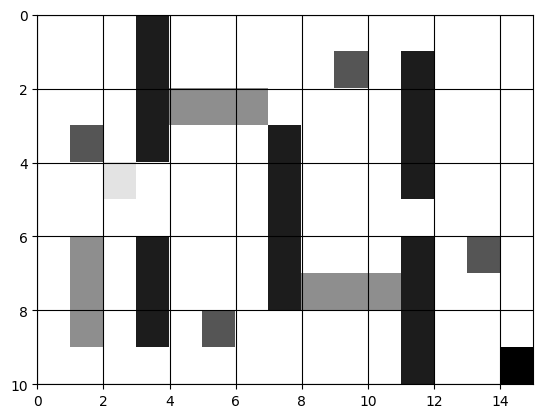

agent select (1, 0)
turn:6


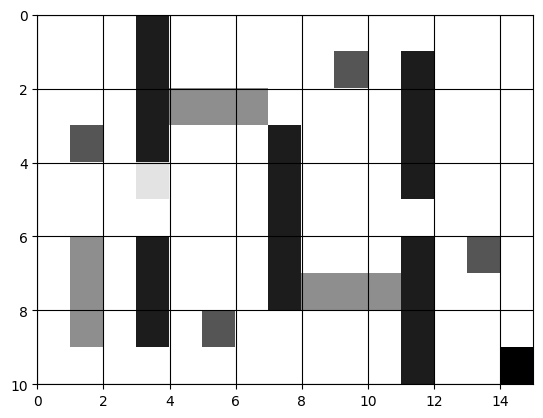

agent select (1, 0)
turn:7


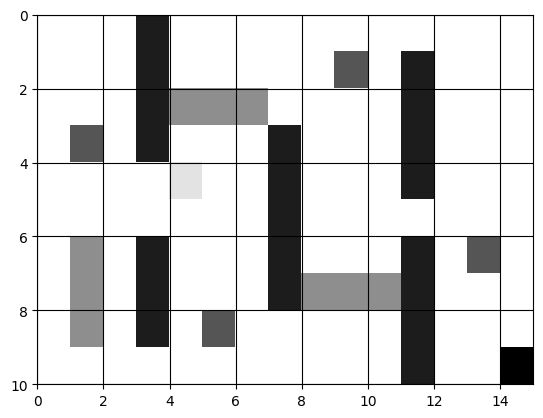

agent select (0, 1)
turn:8


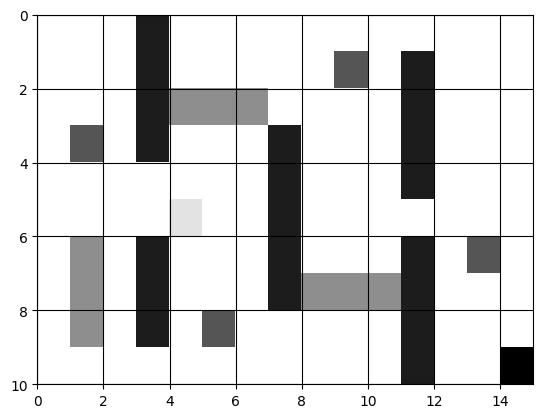

agent select (1, 0)
turn:9


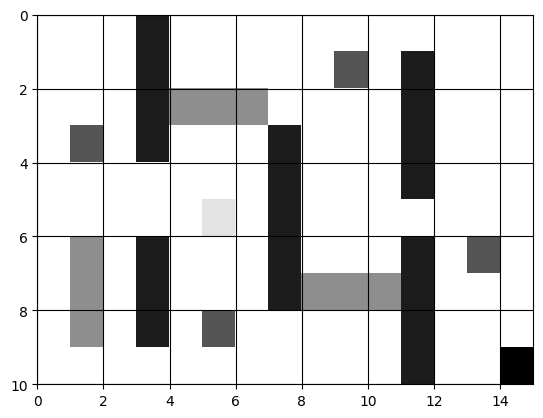

agent select (0, 1)
turn:10


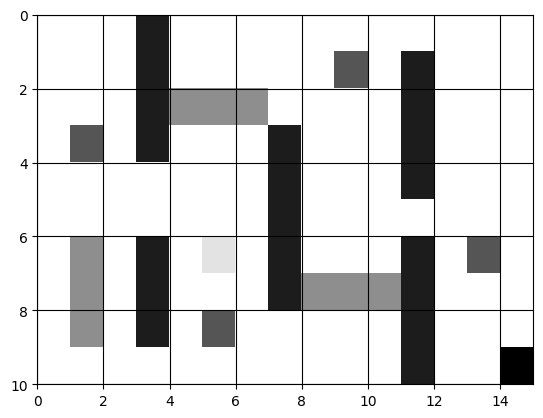

agent select (1, 0)
turn:11


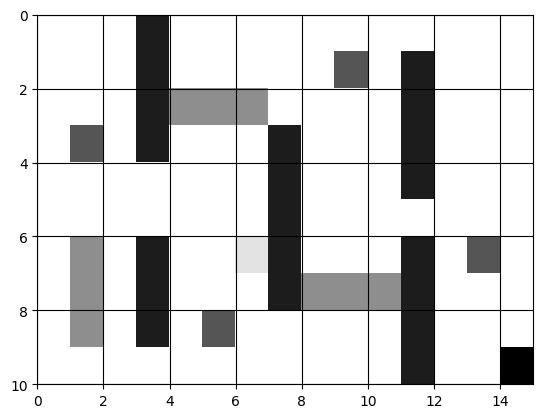

agent select (0, 1)
turn:12


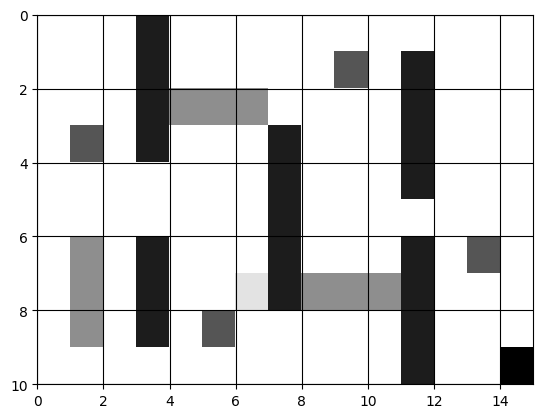

agent select (0, 1)
turn:13


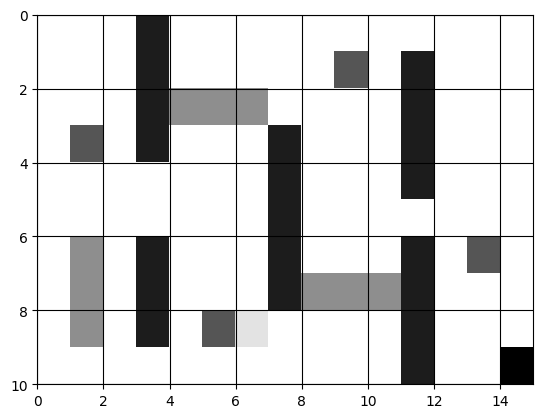

agent select (1, 0)
turn:14


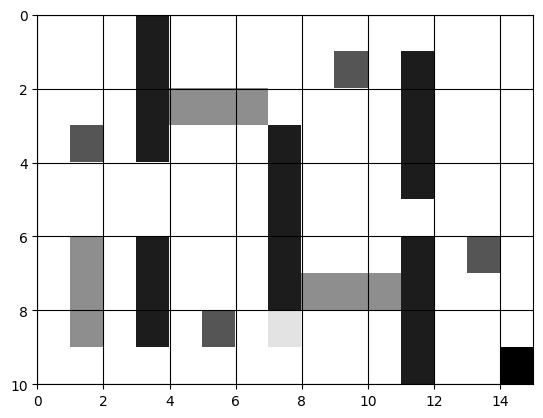

agent select (1, 0)
turn:15


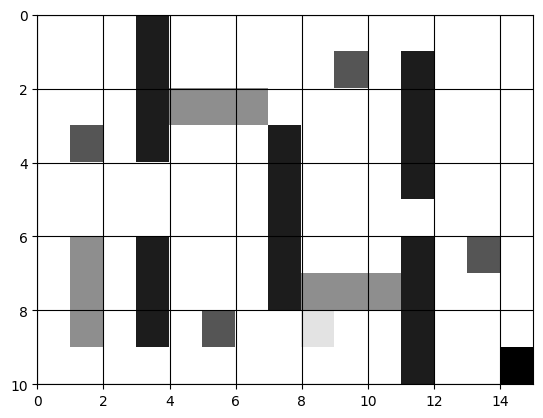

agent select (1, 0)
turn:16


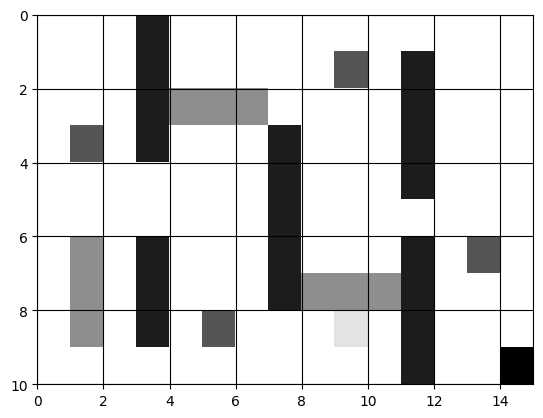

agent select (1, 0)
turn:17


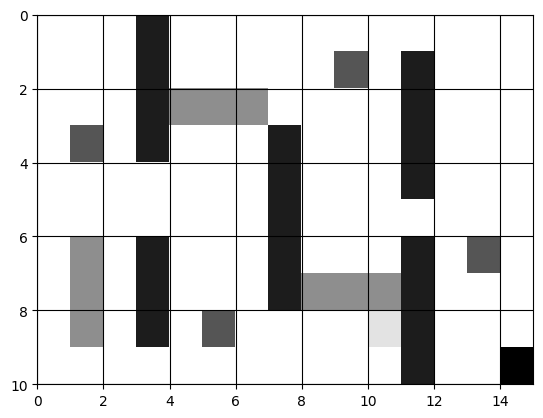

agent select (0, -1)
turn:18


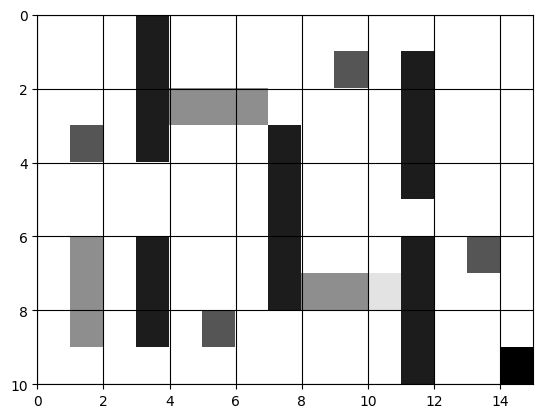

agent select (0, -1)
turn:19


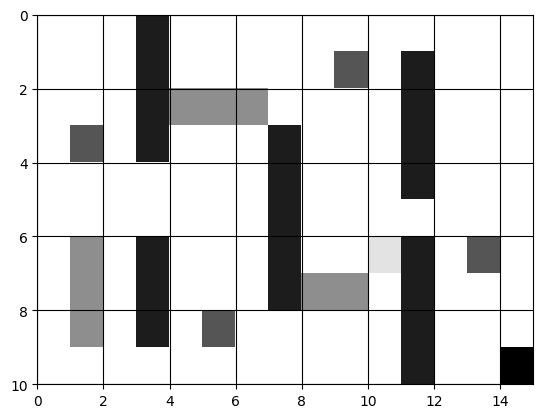

agent select (0, -1)
turn:20


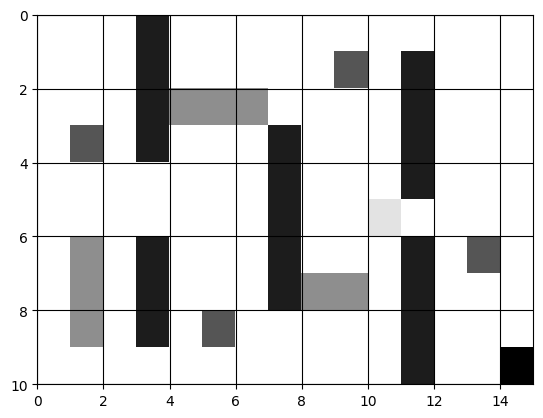

agent select (1, 0)
turn:21


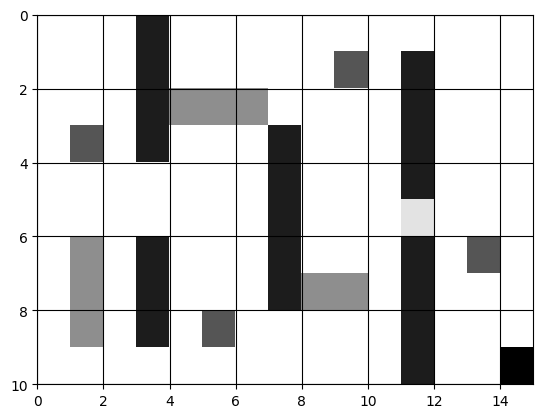

agent select (1, 0)
turn:22


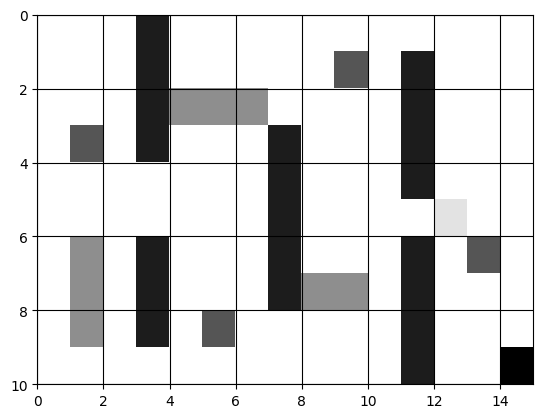

agent select (1, 0)
turn:23


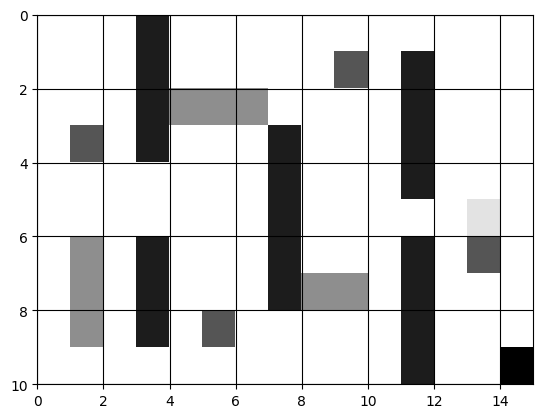

agent select (1, 0)
turn:24


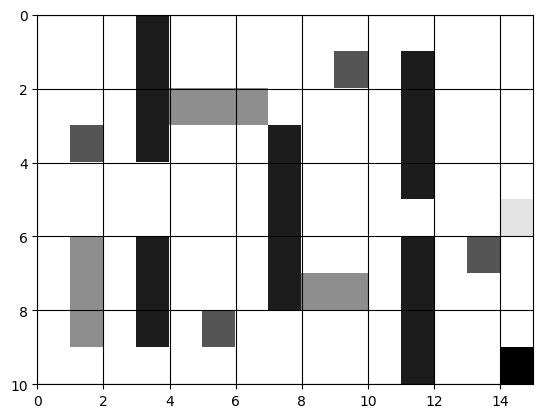

agent select (0, 1)
turn:25


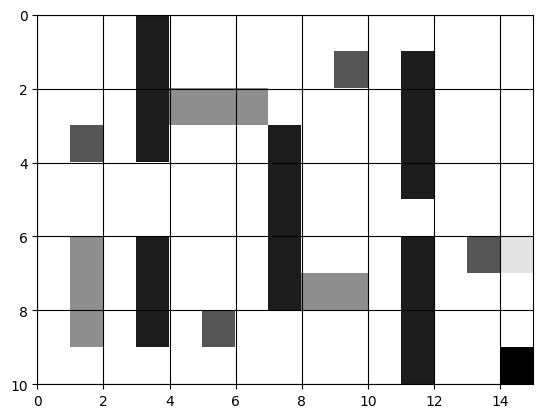

agent select (0, 1)
turn:26


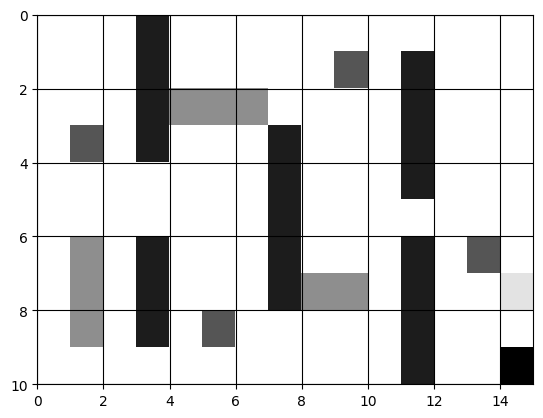

agent select (0, 1)
turn:27


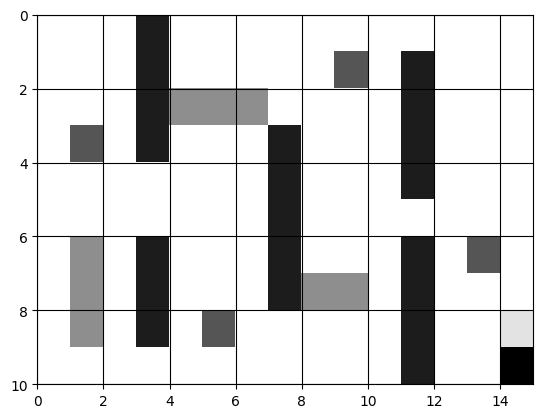

agent select (0, 1)
turn:28


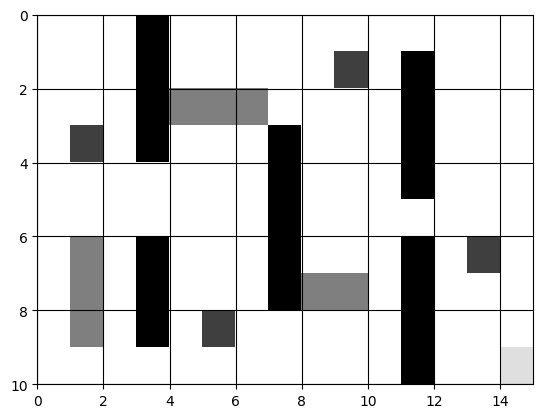

|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(0, 1)	|(0, 1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, -1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)

In [28]:

env_sf = CustomCuriosityEnv()
agent_sf = OffPolicyAgent(env_sf.width, env_sf.height, param=(0.1, 0.9, 0.1), behavior_policy=softmax, name='Q+softmax')
steps_sf = sim(epi=episode, env=env_sf, agent=agent_sf)

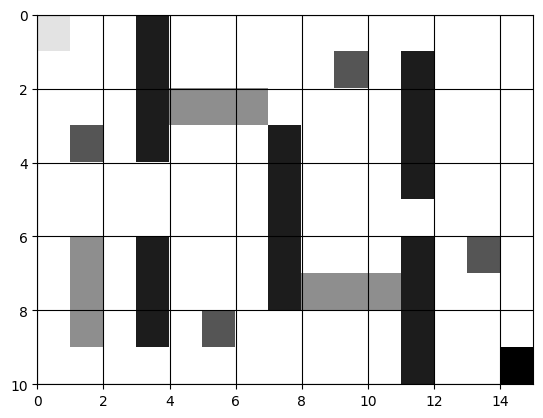

agent select (0, 1)
turn:0


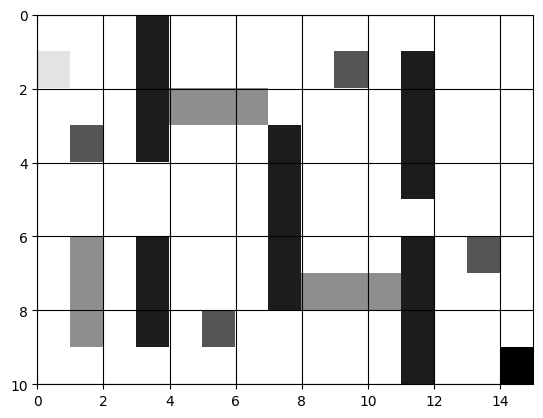

agent select (1, 0)
turn:1


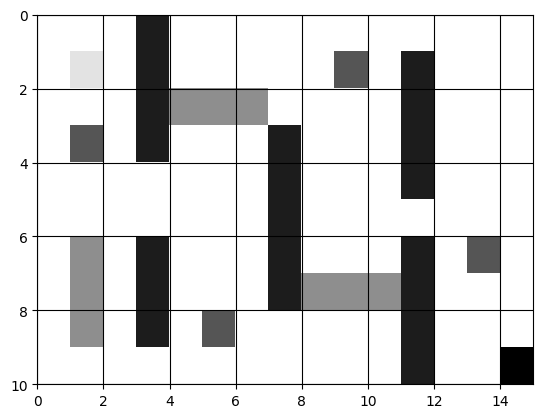

agent select (1, 0)
turn:2


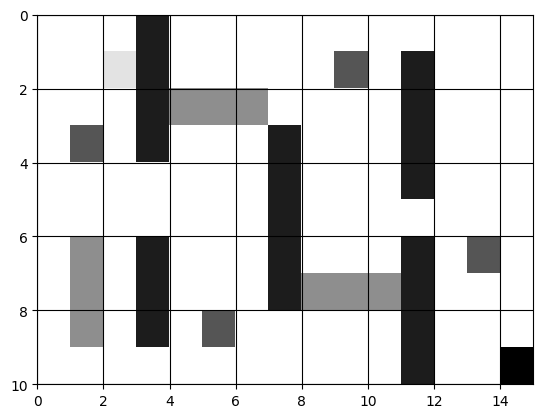

agent select (0, 1)
turn:3


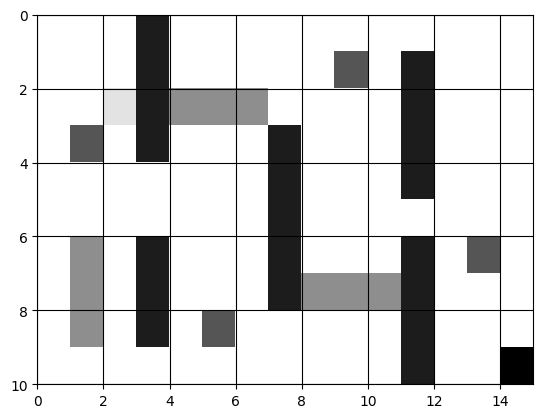

agent select (1, 0)
turn:4


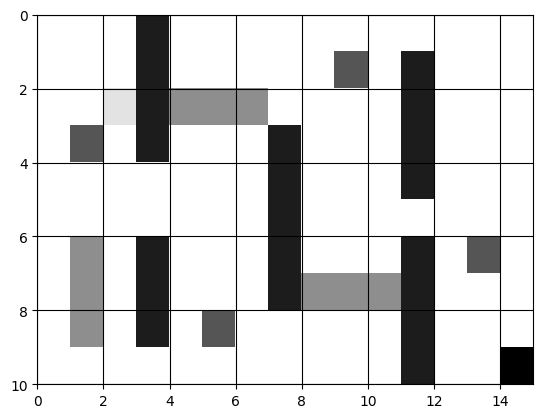

agent select (1, 0)
turn:5


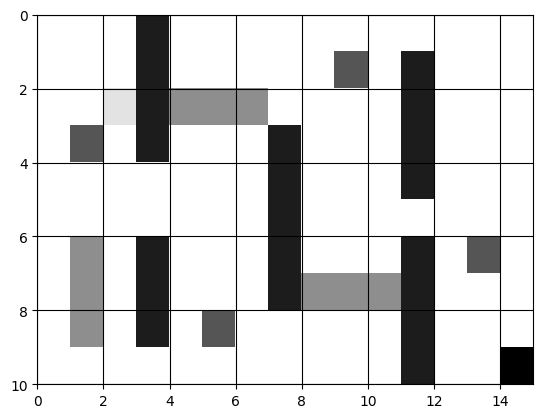

agent select (0, 1)
turn:6


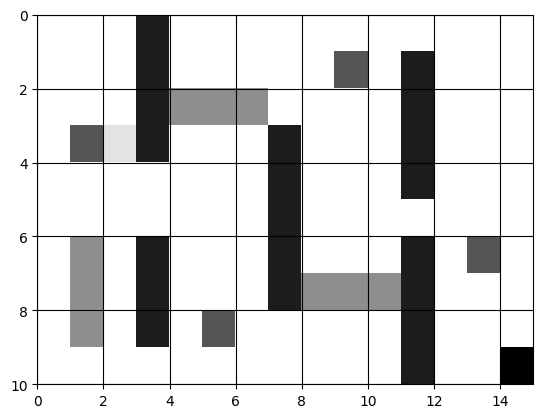

agent select (0, 1)
turn:7


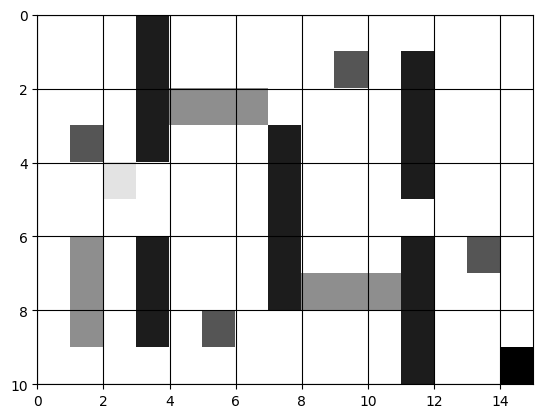

agent select (1, 0)
turn:8


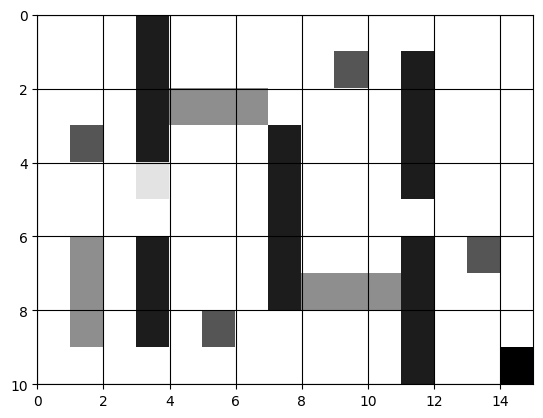

agent select (1, 0)
turn:9


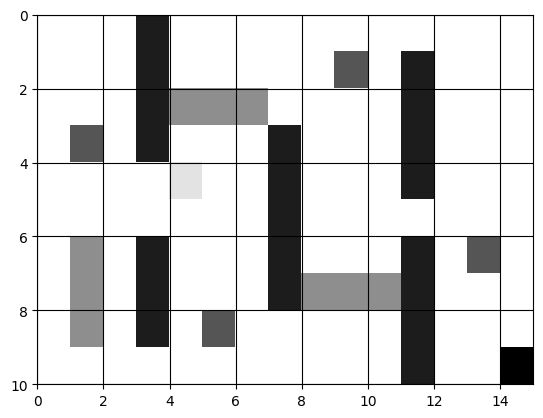

agent select (0, 1)
turn:10


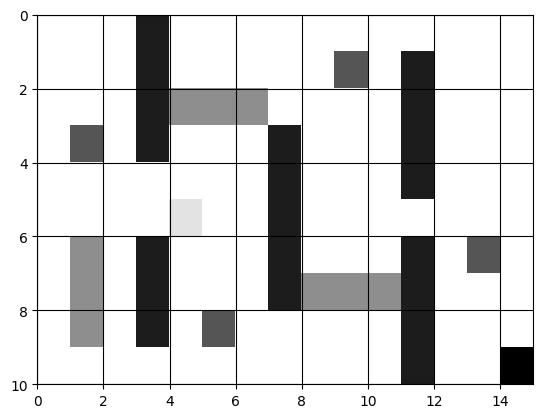

agent select (0, 1)
turn:11


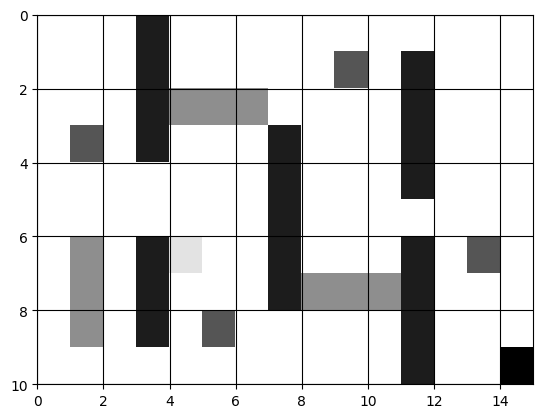

agent select (1, 0)
turn:12


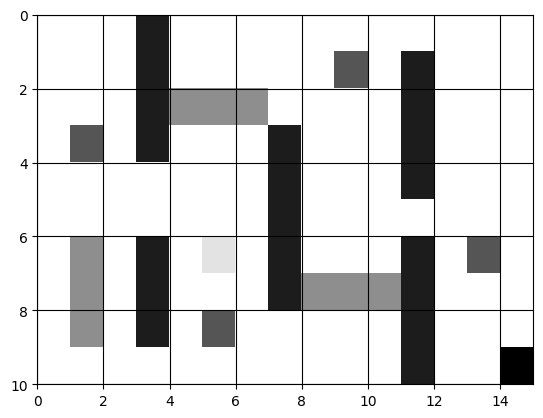

agent select (1, 0)
turn:13


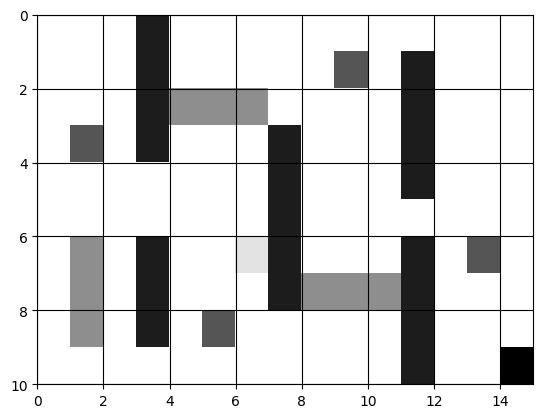

agent select (0, 1)
turn:14


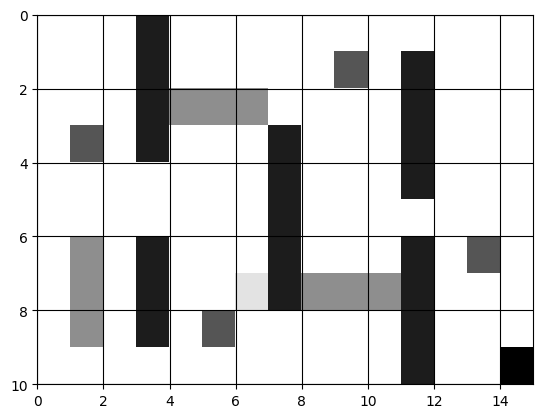

agent select (0, 1)
turn:15


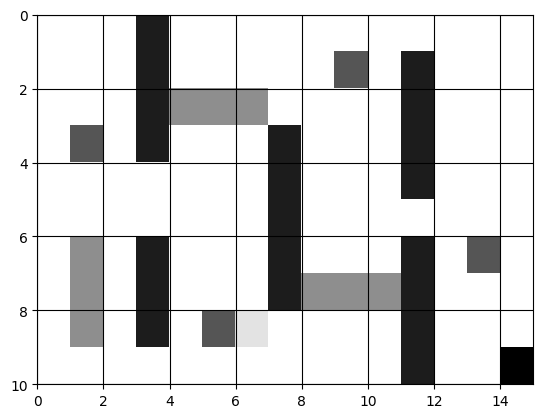

agent select (1, 0)
turn:16


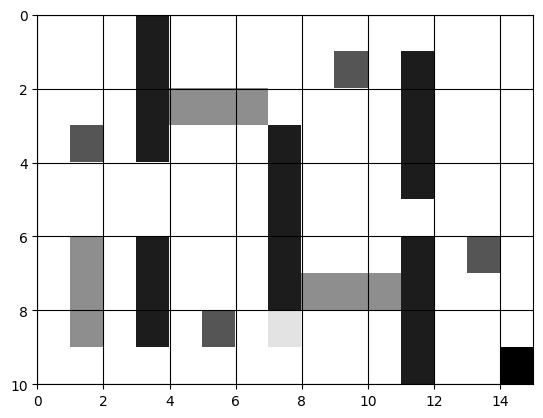

agent select (1, 0)
turn:17


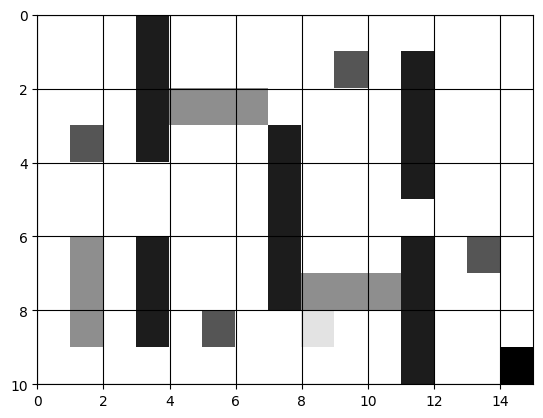

agent select (1, 0)
turn:18


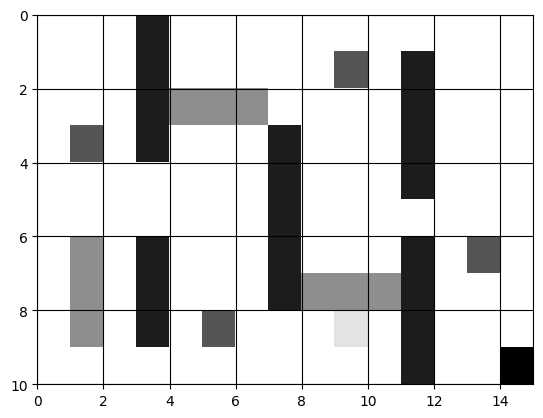

agent select (1, 0)
turn:19


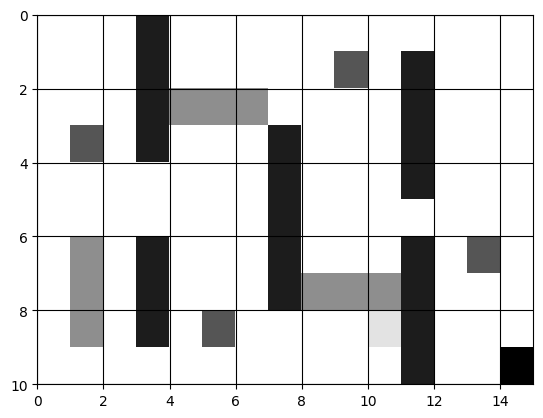

agent select (0, -1)
turn:20


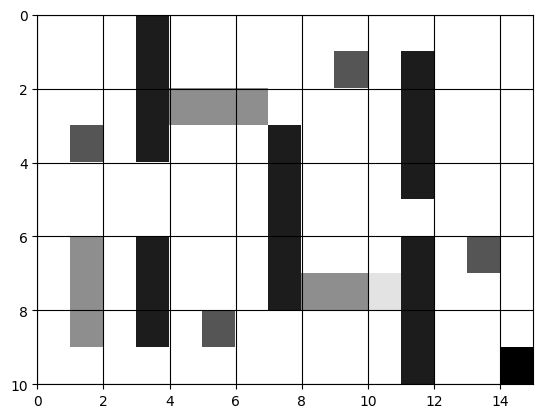

agent select (0, -1)
turn:21


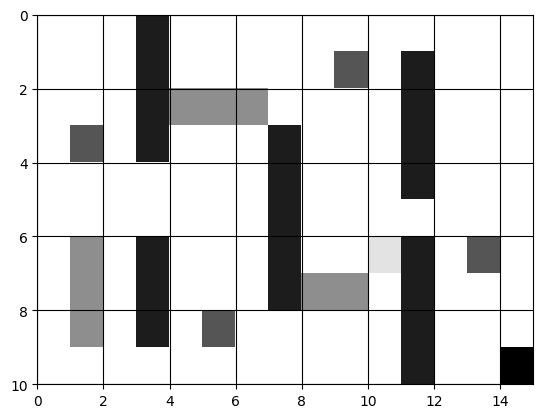

agent select (0, -1)
turn:22


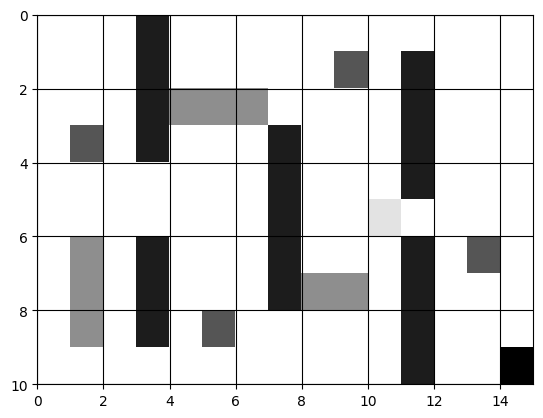

agent select (1, 0)
turn:23


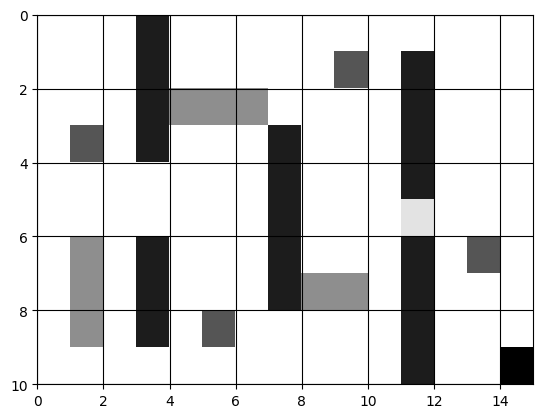

agent select (1, 0)
turn:24


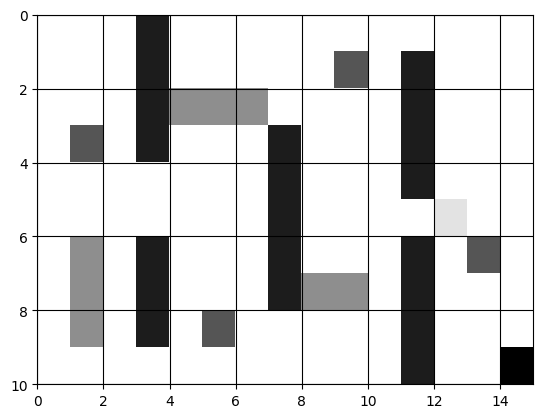

agent select (0, 1)
turn:25


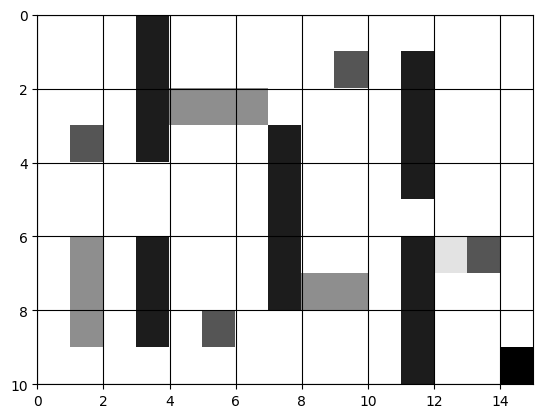

agent select (0, 1)
turn:26


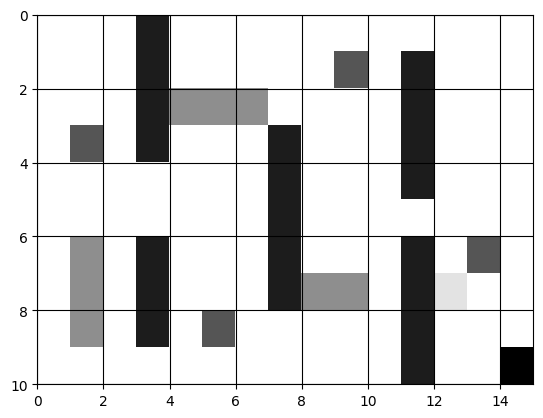

agent select (0, 1)
turn:27


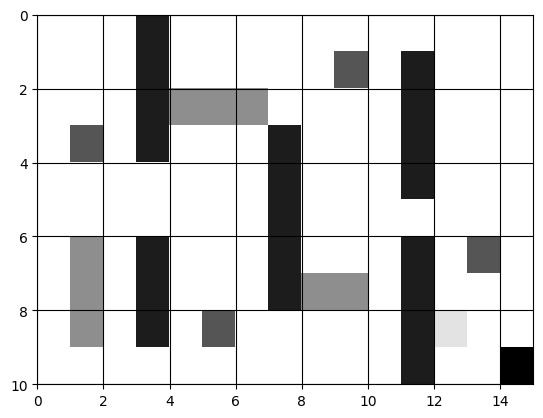

agent select (1, 0)
turn:28


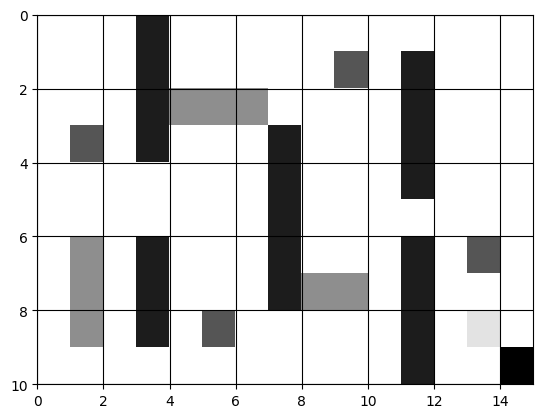

agent select (1, 0)
turn:29


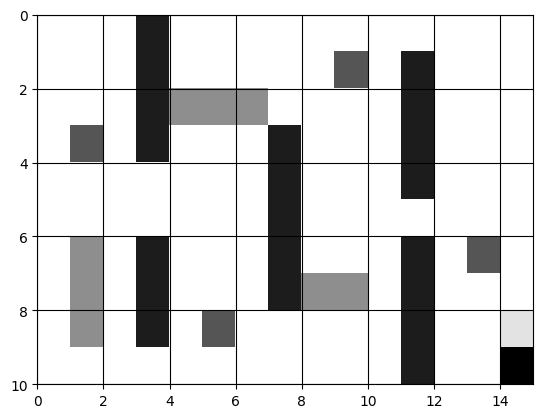

agent select (0, 1)
turn:30


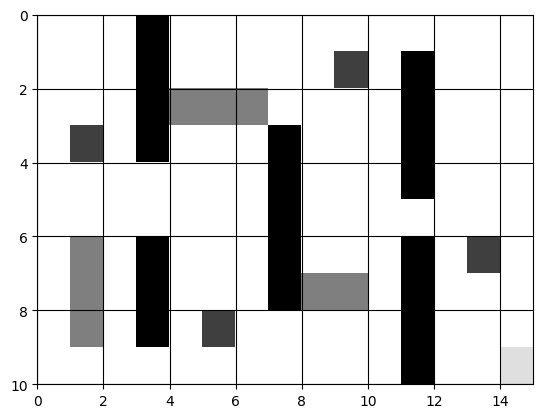

|(1, 0)	|(0, 1)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|
|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, -1)	|(1, 0)	|(-1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|
|(0, 1)	|(0, -1)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(-1, 0)	|(-1, 0)	|
|(0, 1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(-1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(-1, 0)	|(-1, 0)	|
|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, -1)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(-1, 0)	|
|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, -1)	|(0, 1)	|
|(-1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0

In [29]:
env_curious = CustomCuriosityEnv()
agent_curious = CuriosityAgent(env_curious.width, env_curious.height, name='Q+Curiosity', beta=10.0)
steps_curious = sim(episode, env_curious, agent_curious)

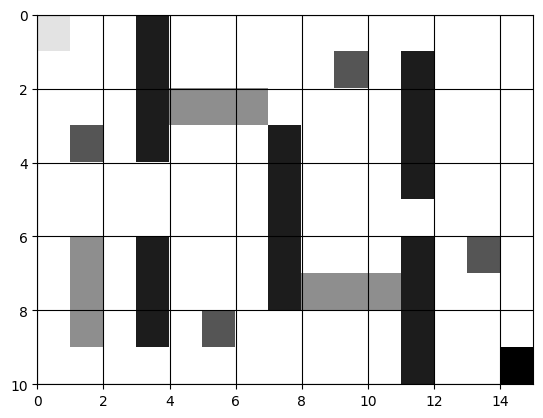

agent select (0, 1)
turn:0


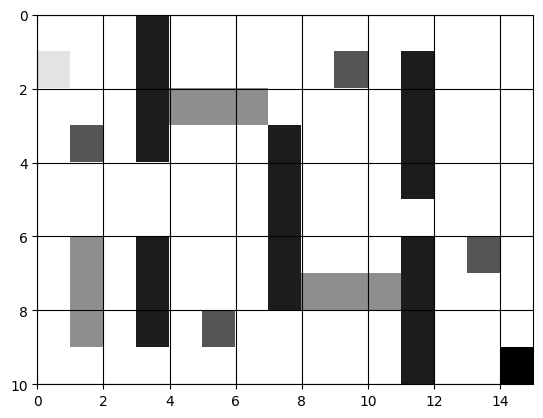

agent select (0, 1)
turn:1


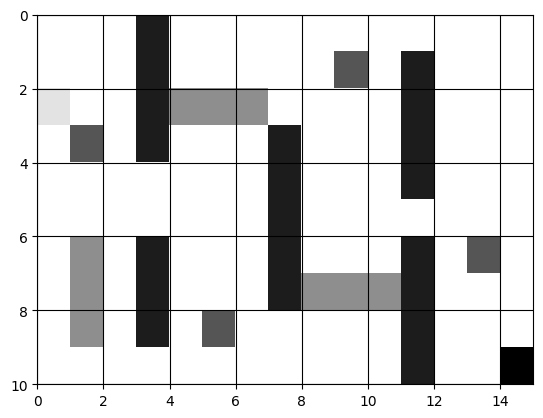

agent select (0, 1)
turn:2


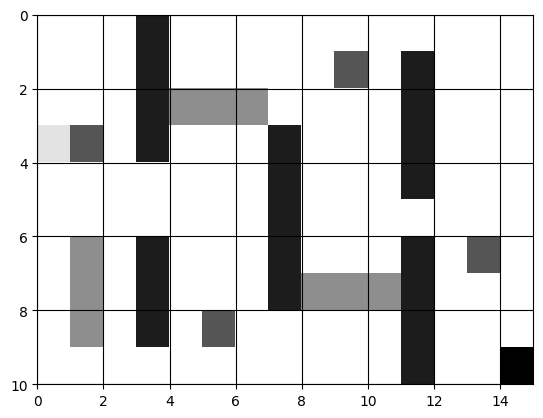

agent select (0, 1)
turn:3


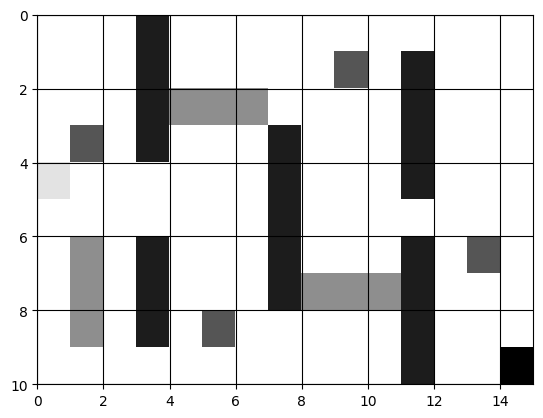

agent select (1, 0)
turn:4


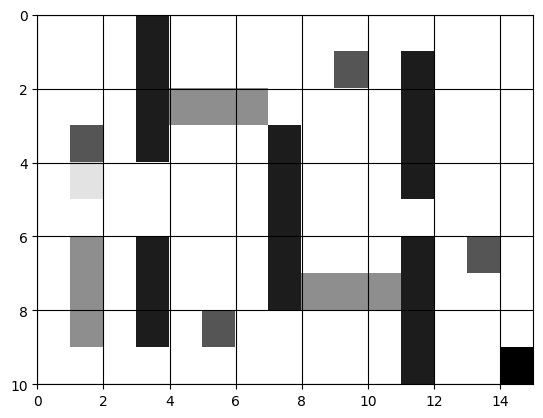

agent select (1, 0)
turn:5


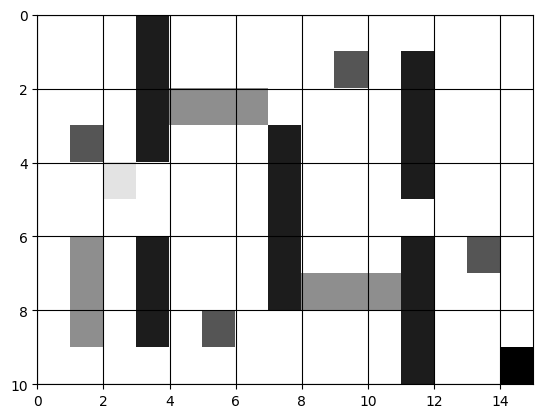

agent select (1, 0)
turn:6


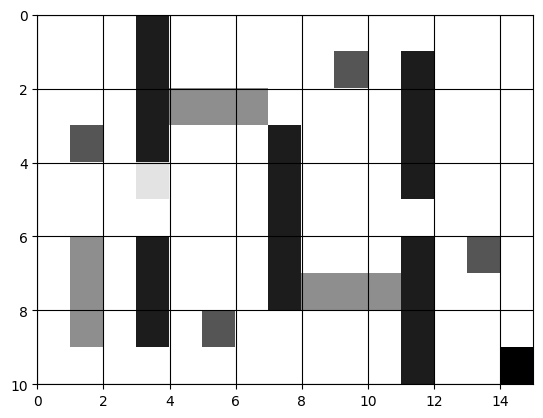

agent select (1, 0)
turn:7


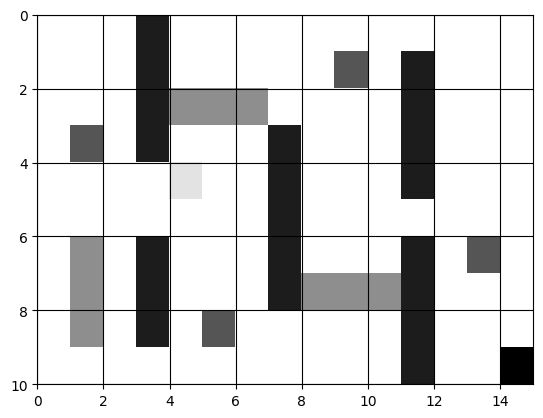

agent select (1, 0)
turn:8


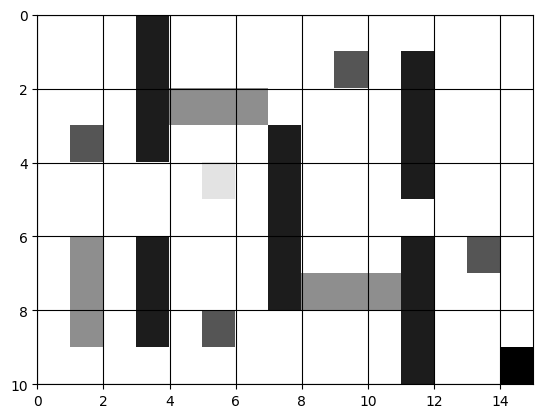

agent select (0, 1)
turn:9


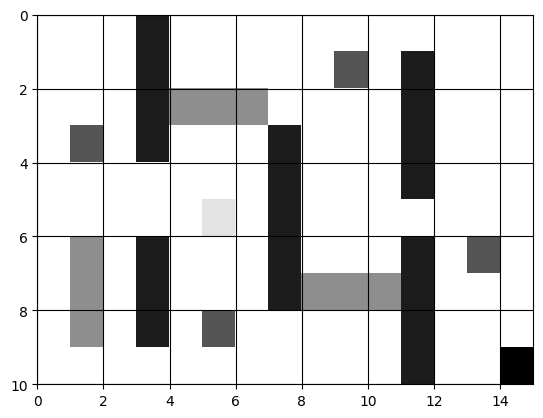

agent select (1, 0)
turn:10


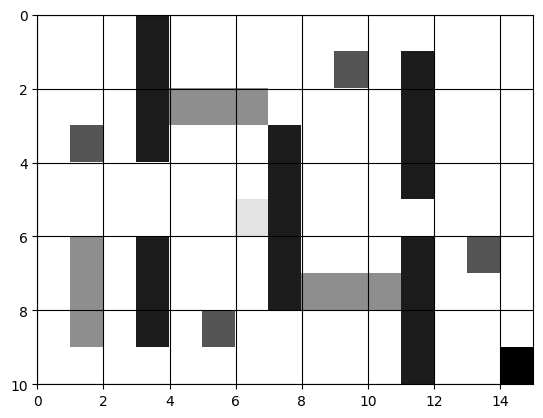

agent select (0, 1)
turn:11


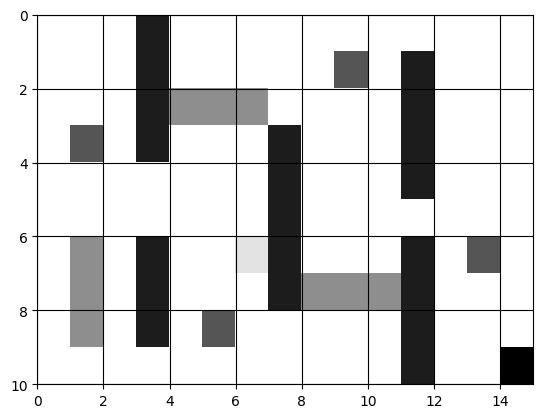

agent select (0, 1)
turn:12


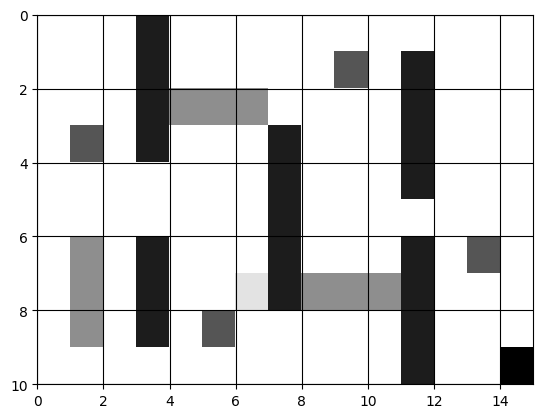

agent select (0, 1)
turn:13


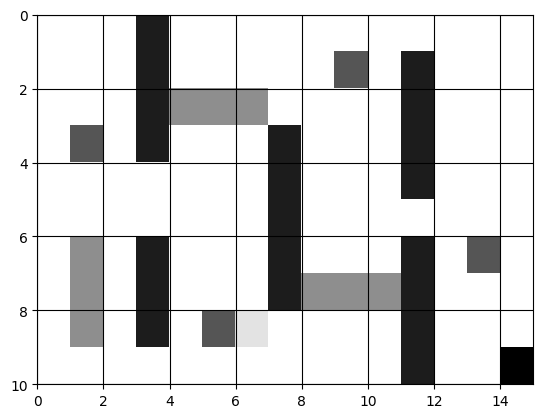

agent select (1, 0)
turn:14


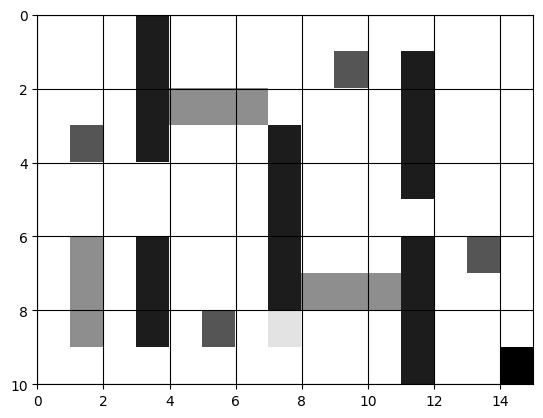

agent select (1, 0)
turn:15


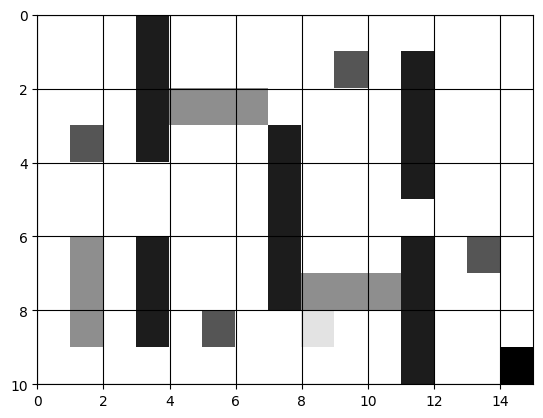

agent select (1, 0)
turn:16


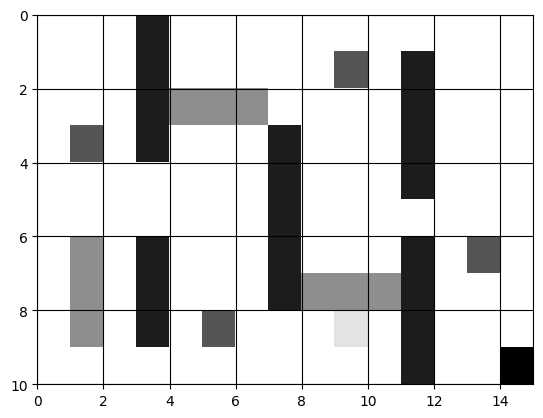

agent select (1, 0)
turn:17


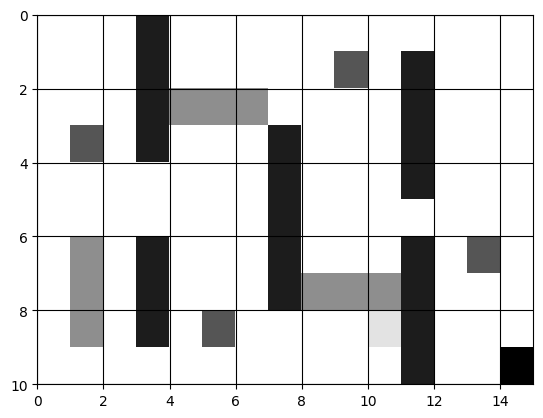

agent select (0, -1)
turn:18


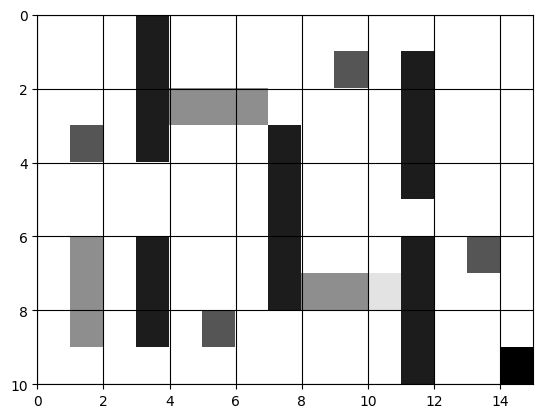

agent select (0, -1)
turn:19


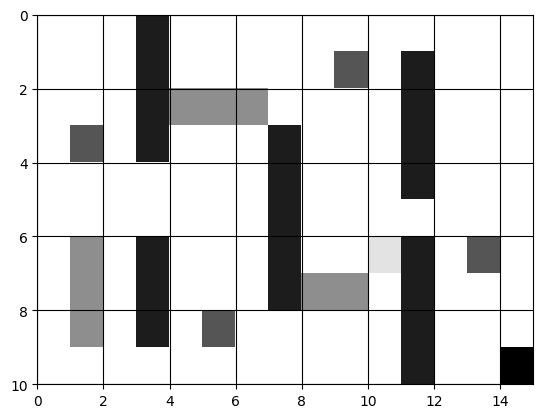

agent select (0, -1)
turn:20


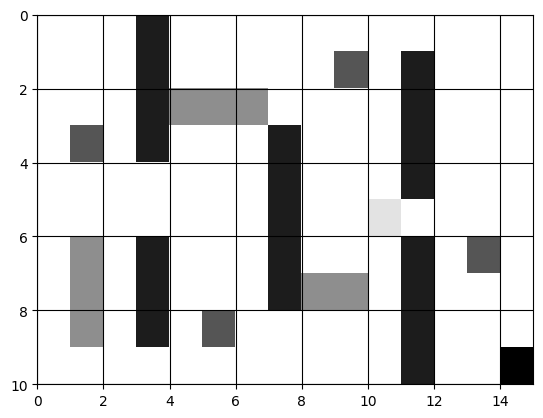

agent select (1, 0)
turn:21


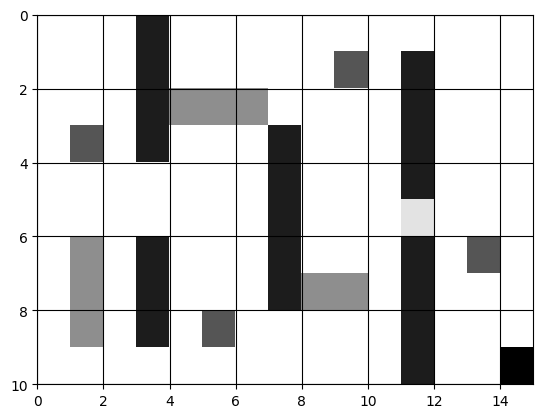

agent select (1, 0)
turn:22


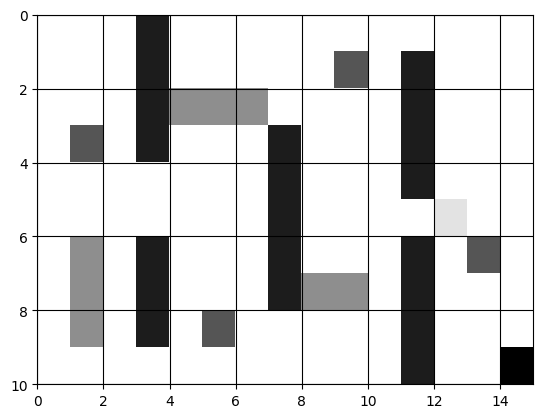

agent select (0, 1)
turn:23


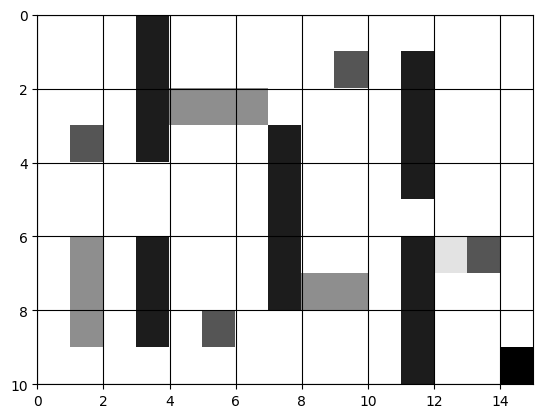

agent select (0, 1)
turn:24


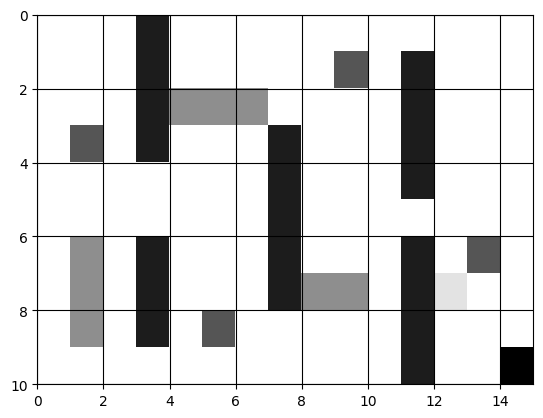

agent select (1, 0)
turn:25


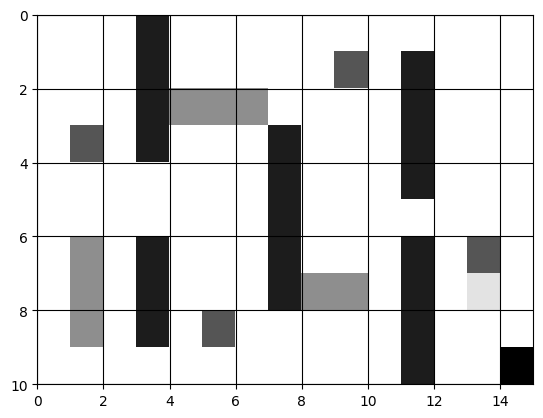

agent select (1, 0)
turn:26


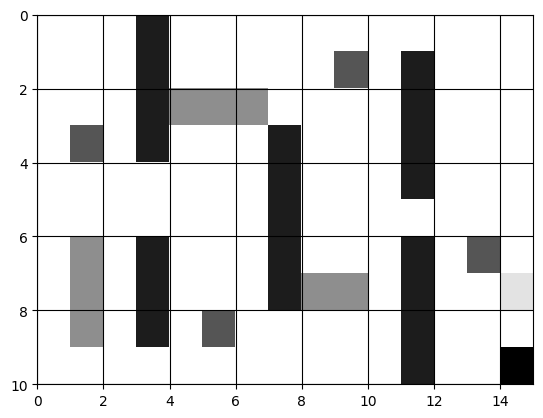

agent select (0, 1)
turn:27


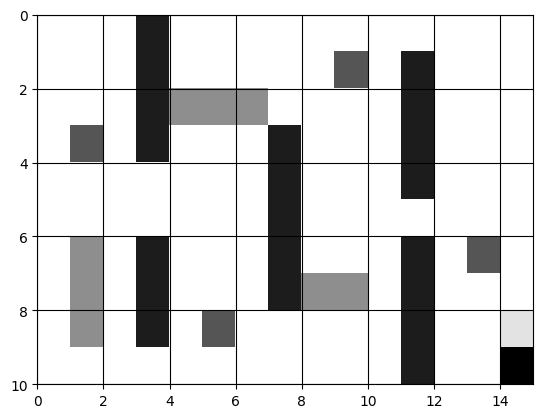

agent select (0, 1)
turn:28


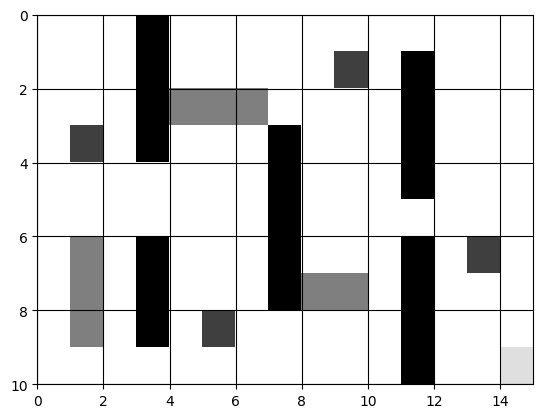

|(0, 1)	|(0, 1)	|(0, 1)	|(-1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|
|(0, 1)	|(0, 1)	|(0, 1)	|(0, 1)	|(0, -1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(0, -1)	|(-1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(-1, 0)	|(-1, 0)	|(0, -1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, 1)	|(0, 1)	|(0, -1)	|(1, 0)	|(0, 1)	|(0, 1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, 1)	|
|(0, 1)	|(1, 0)	|(0, 1)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(0, -1)	|(0, -1)	|(0, -1)	|(0, 1)	|(-1, 0)	|(0, 1)	|
|(0, 1)	|(-1, 0)	|(0, 1)	|(1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	|(1, 0)	|(0, -1)	|(0, -1)	|(0, -1)	|(-1, 0)	|(1, 0)	|(1, 0)	|(0, 1)	

In [30]:
env_ucb = CustomCuriosityEnv()
agent_ucb = OffPolicyAgent(env_ucb.width, env_ucb.height, param=(0.1, 0.9, 1.0), behavior_policy=select_ucb, name='Q+UCB')
steps_ucb = sim(epi=episode, env=env_ucb, agent=agent_ucb)

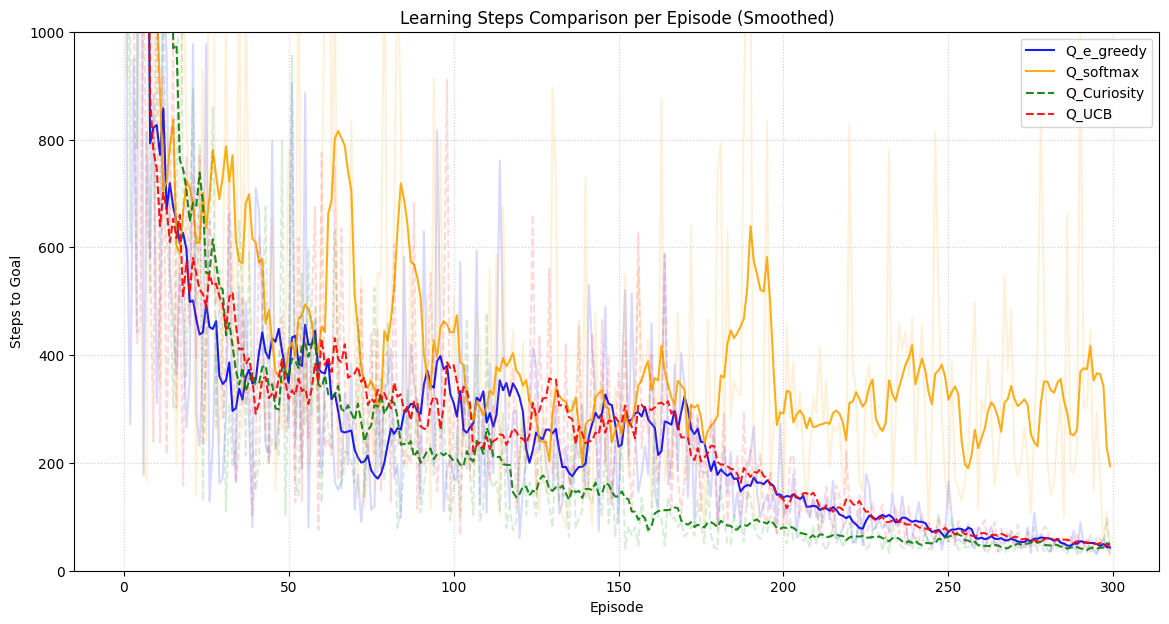

last policy steps
  Q_e_greedy: 	39 steps
  Q_softmax: 		29 steps
  Q_Curiosity: 	31 steps
  Q_UCB: 		29 steps


In [31]:
# 滑らかさの度合い
window_size = 8

plt.figure(figsize=(14.0, 7.0))

# 1. Q_e_greedy
plt.plot(np.arange(episode), steps_eg, color='blue', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_eg, window_size), color='blue', label='Q_e_greedy', alpha=0.9)

# 2. Q_softmax
plt.plot(np.arange(episode), steps_sf, color='orange', alpha=0.15)
plt.plot(np.arange(episode), smooth(steps_sf, window_size), color='orange', label='Q_softmax', alpha=0.9)

# 3. Q_Curiosity
plt.plot(np.arange(episode), steps_curious, color='green', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_curious, window_size), color='green', label='Q_Curiosity', alpha=0.9, linestyle='--')

# 4. Q_UCB
plt.plot(np.arange(episode), steps_ucb, color='red', alpha=0.15, linestyle='--')
plt.plot(np.arange(episode), smooth(steps_ucb, window_size), color='red', label='Q_UCB', alpha=0.9, linestyle='--')

# グラフの装飾
plt.title('Learning Steps Comparison per Episode (Smoothed)')
plt.xlabel('Episode')
plt.ylabel('Steps to Goal')

plt.ylim(0, 1000)

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 最終エピソードの結果出力
print('last policy steps')
print('  Q_e_greedy: \t{} steps'.format(steps_eg[-1]))
print('  Q_softmax: \t\t{} steps'.format(steps_sf[-1]))
print('  Q_Curiosity: \t{} steps'.format(steps_curious[-1]))
print('  Q_UCB: \t\t{} steps'.format(steps_ucb[-1]))

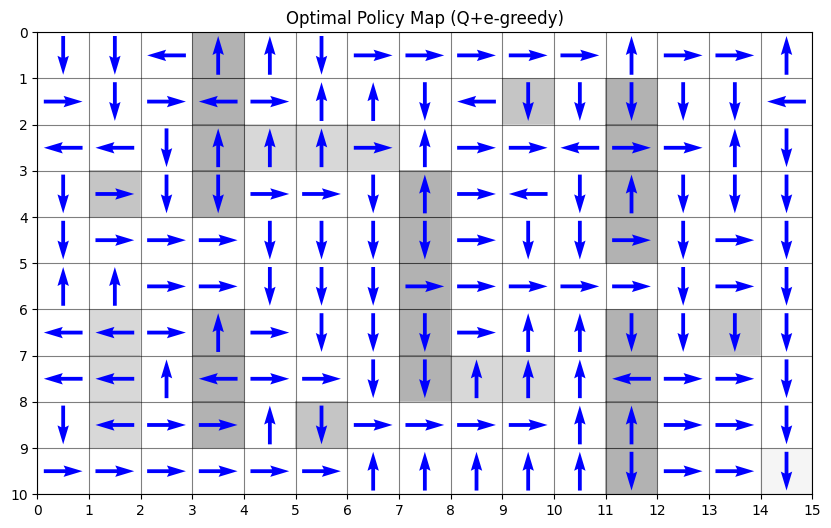

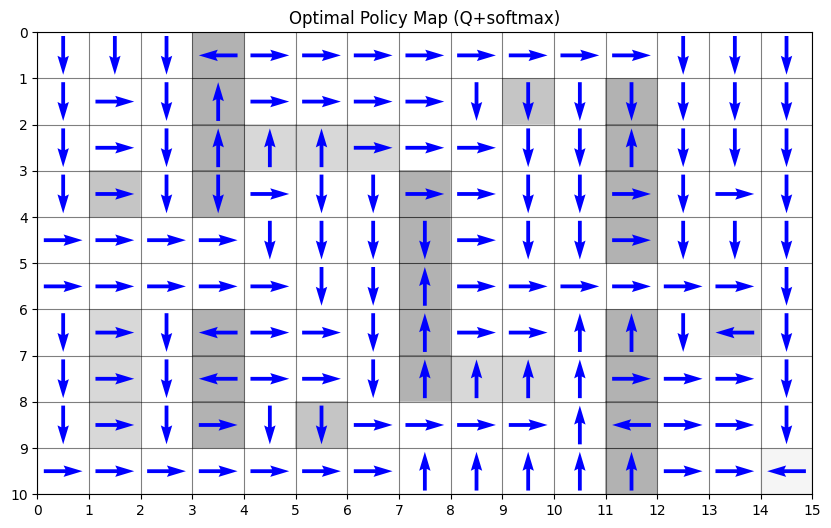

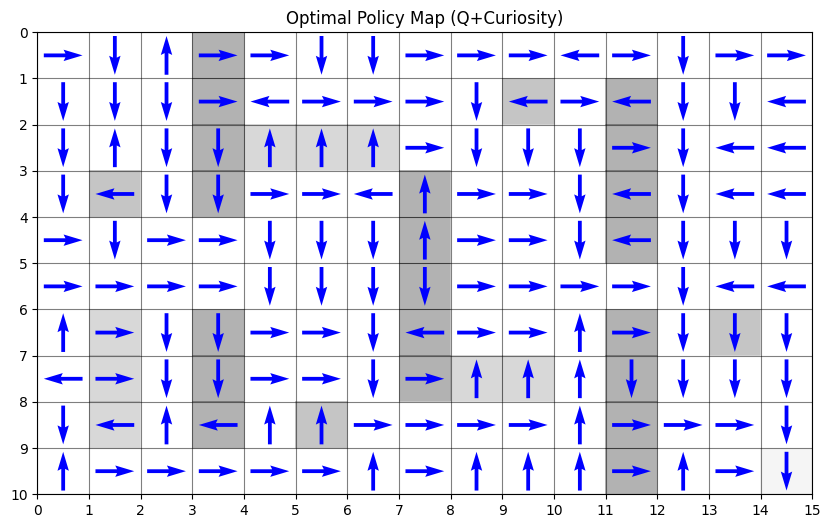

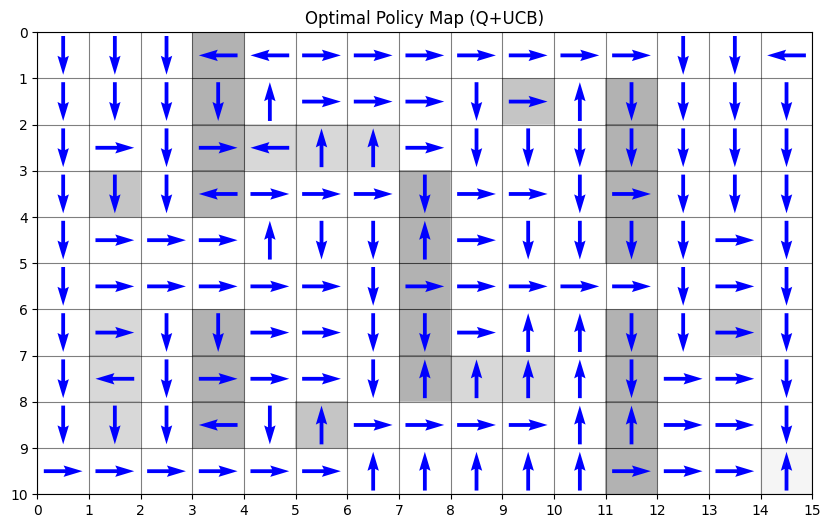

In [32]:
plot_policy(agent_eg, env_eg)
plot_policy(agent_sf, env_sf)
plot_policy(agent_curious, env_curious)
plot_policy(agent_ucb, env_ucb)